# 03 · EDA & Business Analysis

## Objective

The objective of this notebook is to perform exploratory data analysis
and answer important business questions using the cleaned datasets.

The analysis will focus on:

- Sales and revenue performance
- Customer behavior and retention
- Order trends
- Delivery performance
- Seller performance
- Product category performance
- Payment behavior
- Review and customer satisfaction
- Geographic patterns

The goal is not only to describe the data, but to identify actionable
business insights from the analysis.

In [379]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

## 1. Load Cleaned Datasets

The cleaned datasets generated during the data-cleaning phase are
loaded from the `data/processed` directory.

The raw datasets are not used directly in this notebook.

In [380]:
DATA_PROCESSED = Path("../data/processed")

customers = pd.read_csv(
    DATA_PROCESSED / "olist_customers_clean.csv"
)

geolocation = pd.read_csv(
    DATA_PROCESSED / "olist_geolocation_clean.csv"
)

orders = pd.read_csv(
    DATA_PROCESSED / "olist_orders_clean.csv"
)

order_items = pd.read_csv(
    DATA_PROCESSED / "olist_order_items_clean.csv"
)

order_payments = pd.read_csv(
    DATA_PROCESSED / "olist_order_payments_clean.csv"
)

order_reviews = pd.read_csv(
    DATA_PROCESSED / "olist_order_reviews_clean.csv"
)

products = pd.read_csv(
    DATA_PROCESSED / "olist_products_clean.csv"
)

sellers = pd.read_csv(
    DATA_PROCESSED / "olist_sellers_clean.csv"
)

category_translation = pd.read_csv(
    DATA_PROCESSED / "product_category_translation_clean.csv"
)

In [381]:
# convert dates , Because CSV files don't preserve Pandas datetime types, convert them again:
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(
        orders[col],
        errors="coerce"
    )

In [382]:
# Verify
datasets = {
    "Customers": customers,
    "Geolocation": geolocation,
    "Orders": orders,
    "Order Items": order_items,
    "Order Payments": order_payments,
    "Order Reviews": order_reviews,
    "Products": products,
    "Sellers": sellers,
    "Category Translation": category_translation
}

for name, df in datasets.items():
    print(f"{name:<22} {df.shape}")

Customers              (99441, 5)
Geolocation            (738332, 5)
Orders                 (99441, 10)
Order Items            (112650, 7)
Order Payments         (103886, 7)
Order Reviews          (99224, 7)
Products               (32951, 9)
Sellers                (3095, 4)
Category Translation   (71, 2)


## 2. Sales & Revenue Performance

### Business Question

How is the business generating revenue, and what are the major revenue drivers?

We begin by calculating the total item value and freight value for each order.

Since an order can contain multiple items, item-level transactions are aggregated to the order level before calculating total order value.

In [383]:
order_revenue = (
    order_items
    .groupby("order_id")
    .agg(
        item_value=("price", "sum"),
        freight_value=("freight_value", "sum")
    )
)

order_revenue["total_order_value"] = (
    order_revenue["item_value"]
    + order_revenue["freight_value"]
)

order_revenue.head(10).round(2)

,item_value,freight_value,total_order_value
order_id,,,
00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,72.19
00018f77f2f0320c557190d7a144bdd3,239.90,19.93,259.83
000229ec398224ef6ca0657da4fc703e,199.00,17.87,216.87
00024acbcdf0a6daa1e931b038114c75,12.99,12.79,25.78
00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,218.04
00048cc3ae777c65dbb7d2a0634bc1ea,21.90,12.69,34.59
00054e8431b9d7675808bcb819fb4a32,19.90,11.85,31.75
000576fe39319847cbb9d288c5617fa6,810.00,70.75,880.75
0005a1a1728c9d785b8e2b08b904576c,145.95,11.65,157.60


### Overall Revenue Performance

The order-level revenue dataset is summarized to understand the overall scale and distribution of order values.

Key metrics include total revenue, average order value, median order value, and the number of orders represented in the transaction data.

In [384]:
revenue_summary = {
    "Total Revenue": order_revenue["total_order_value"].sum(),
    "Average Order Value": order_revenue["total_order_value"].mean(),
    "Median Order Value": order_revenue["total_order_value"].median(),
    "Number of Orders": order_revenue.shape[0]
}

pd.Series(revenue_summary).round(2)

Total Revenue          15843553.24
Average Order Value         160.58
Median Order Value          105.29
Number of Orders          98666.00
dtype: float64

### Order Value Distribution

The distribution of order values is examined to understand how spending varies across orders and whether a small number of high-value orders contribute disproportionately to overall revenue.

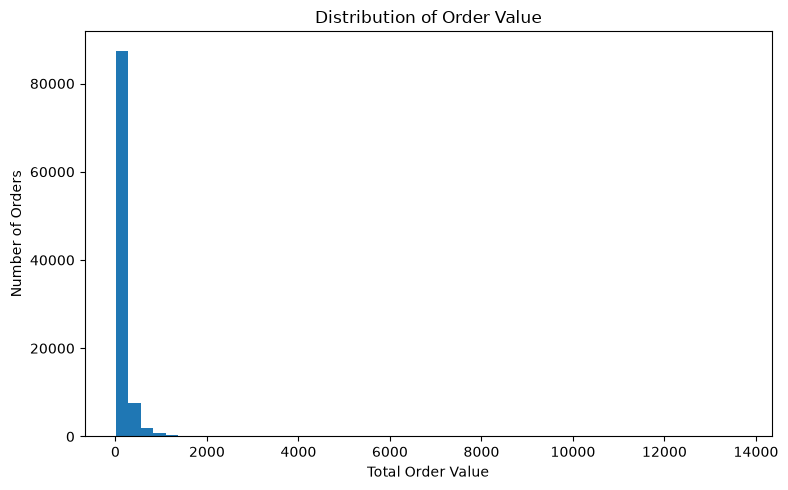

In [385]:
plt.figure(figsize=(8, 5))

plt.hist(
    order_revenue["total_order_value"],
    bins=50
)

plt.title("Distribution of Order Value")
plt.xlabel("Total Order Value")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

In [386]:
order_revenue["total_order_value"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).round(2)

count    98666.00
mean       160.58
std        220.47
min          9.59
25%         61.98
50%        105.29
75%        176.87
90%        307.68
95%        450.53
99%       1063.32
max      13664.08
Name: total_order_value, dtype: float64

## 3. Monthly Revenue Trend

### Business Question

How has revenue changed over time?

Monthly revenue is calculated using the order purchase date and order-level revenue.

This helps identify overall growth patterns, seasonal fluctuations, and unusually strong or weak periods.

In [387]:
monthly_revenue = (
    orders[
        ["order_id", "order_purchase_timestamp"]
    ]
    .merge(
        order_revenue[["total_order_value"]],
        left_on="order_id",
        right_index=True,
        how="inner"
    )
)

monthly_revenue["month"] = (
    monthly_revenue["order_purchase_timestamp"]
    .dt.to_period("M")
    .astype(str)
)

monthly_revenue = (
    monthly_revenue
    .groupby("month")
    .agg(
        total_revenue=("total_order_value", "sum"),
        order_count=("order_id", "nunique"),
        avg_order_value=("total_order_value", "mean")
    )
    .reset_index()
)

monthly_revenue.head()

,month,total_revenue,order_count,avg_order_value
0,2016-09,354.75,3,118.250000
1,2016-10,56808.84,308,184.444286
2,2016-12,19.62,1,19.620000
3,2017-01,137188.49,789,173.876413
4,2017-02,286280.62,1733,165.193664


In [388]:
monthly_revenue.round(2)

,month,total_revenue,order_count,avg_order_value
0,2016-09,354.75,3,118.25
1,2016-10,56808.84,308,184.44
2,2016-12,19.62,1,19.62
3,2017-01,137188.49,789,173.88
4,2017-02,286280.62,1733,165.19
5,2017-03,432048.59,2641,163.59
6,2017-04,412422.24,2391,172.49
7,2017-05,586190.95,3660,160.16
8,2017-06,502963.04,3217,156.35
9,2017-07,584971.62,3969,147.39


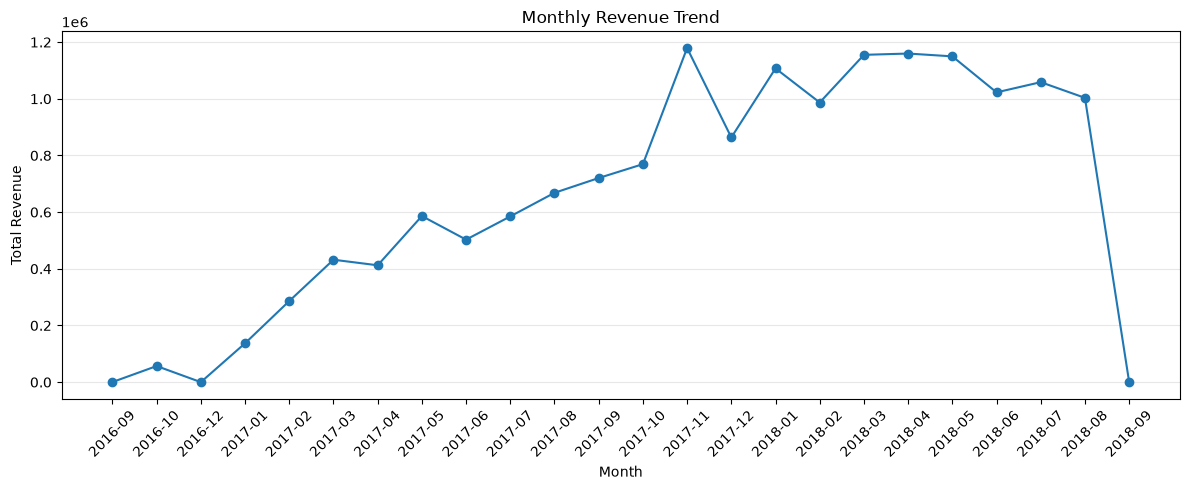

In [389]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue["month"],
    monthly_revenue["total_revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Revenue Trend — Initial Findings

The monthly revenue trend shows strong business growth throughout 2017,
followed by consistently high monthly revenue during 2018.

Revenue increased substantially from the beginning of 2017 and reached
approximately 1.18 million in November 2017.

During 2018, monthly revenue generally remained around or above 1 million,
indicating a relatively stable high-revenue period.

The apparent drop in revenue in September 2018 should not yet be interpreted
as a business decline because the dataset may contain an incomplete final
month. Data completeness will be verified before drawing a conclusion.

### Data Completeness Check

Before interpreting the final month's revenue, we verify the date range
and number of orders available in the dataset.

In [390]:
orders["order_purchase_timestamp"].agg(["min", "max"])

min   2016-09-04 21:15:19
max   2018-10-17 17:30:18
Name: order_purchase_timestamp, dtype: datetime64[us]

In [391]:
orders["order_purchase_timestamp"].dt.to_period("M").value_counts().sort_index().tail(5)

order_purchase_timestamp
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Freq: M, Name: count, dtype: int64

In [392]:
monthly_revenue.tail()

,month,total_revenue,order_count,avg_order_value
19,2018-05,1149781.82,6853,167.777881
20,2018-06,1022677.11,6160,166.019011
21,2018-07,1058728.03,6273,168.775391
22,2018-08,1003308.47,6452,155.503483
23,2018-09,166.46,1,166.460000


### Revenue Trend — Data Completeness Finding

The dataset shows strong revenue growth from 2017 onward, followed by
relatively stable monthly revenue during 2018.

However, the apparent revenue decline in September 2018 is not a reliable
business trend.

The order dataset contains only 16 orders in September 2018 and 4 orders
in October 2018, compared with more than 6,000 orders per month during
June–August 2018.

Furthermore, only one September order is represented in the order-level
revenue dataset.

Therefore, September and October 2018 are treated as incomplete periods
and should be excluded from full-month revenue trend comparisons.

### Complete-Month Revenue Analysis

To avoid misleading conclusions, months with incomplete transaction
coverage are excluded from full-month trend analysis.

The analysis will focus on months with sufficient order activity.

In [393]:
monthly_revenue_complete = monthly_revenue[
    monthly_revenue["order_count"] >= 1000
].copy()

monthly_revenue_complete.tail()

,month,total_revenue,order_count,avg_order_value
18,2018-04,1159698.04,6934,167.248059
19,2018-05,1149781.82,6853,167.777881
20,2018-06,1022677.11,6160,166.019011
21,2018-07,1058728.03,6273,168.775391
22,2018-08,1003308.47,6452,155.503483


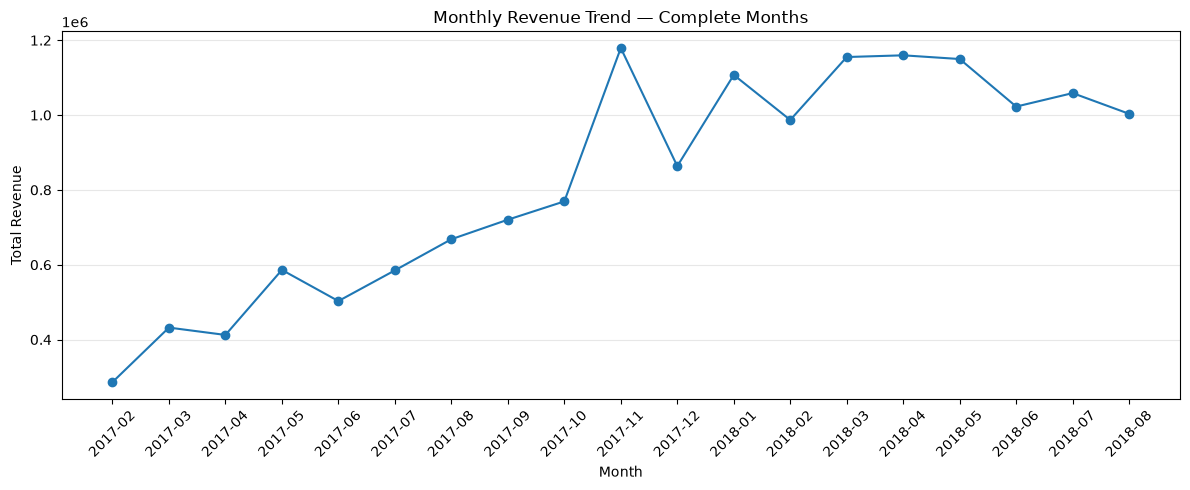

In [394]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue_complete["month"],
    monthly_revenue_complete["total_revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend — Complete Months")
plt.xlabel("Month")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [395]:
monthly_revenue_complete["revenue_growth_pct"] = (
    monthly_revenue_complete["total_revenue"]
    .pct_change()
    * 100
)

monthly_revenue_complete.round(2)

,month,total_revenue,order_count,avg_order_value,revenue_growth_pct
4,2017-02,286280.62,1733,165.19,NaN
5,2017-03,432048.59,2641,163.59,50.92
6,2017-04,412422.24,2391,172.49,-4.54
7,2017-05,586190.95,3660,160.16,42.13
8,2017-06,502963.04,3217,156.35,-14.20
9,2017-07,584971.62,3969,147.39,16.31
10,2017-08,668204.60,4293,155.65,14.23
11,2017-09,720398.91,4243,169.79,7.81
12,2017-10,769312.37,4568,168.41,6.79
13,2017-11,1179143.77,7451,158.25,53.27


### Revenue Growth — Business Insights

The revenue trend indicates strong business expansion during 2017.

Revenue increased substantially across several months, with particularly
strong growth observed in March, May, and November 2017.

Although some months experienced temporary revenue declines, the overall
trend remained strongly positive during the growth phase.

By 2018, monthly revenue had reached a significantly higher level and
generally remained around 1 million or above. This suggests that the
business transitioned from a rapid-growth phase into a relatively stable
high-revenue period.

The analysis excludes the final incomplete months of the dataset to avoid
misinterpreting partial-period data as a genuine business decline.

## 4. Revenue Drivers: Order Volume vs Order Value

### Business Question

Is revenue growth primarily driven by an increase in the number of orders,
or by customers spending more per order?

We compare monthly order volume, total revenue, and average order value
to identify the main drivers of revenue growth.

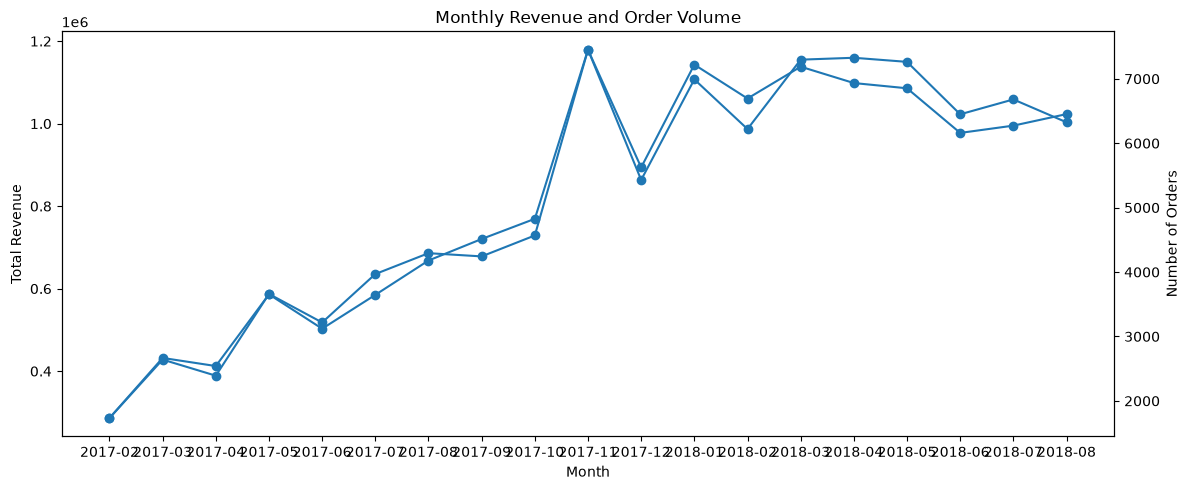

In [396]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(
    monthly_revenue_complete["month"],
    monthly_revenue_complete["total_revenue"],
    marker="o",
    label="Revenue"
)

ax1.set_xlabel("Month")
ax1.set_ylabel("Total Revenue")

ax2 = ax1.twinx()

ax2.plot(
    monthly_revenue_complete["month"],
    monthly_revenue_complete["order_count"],
    marker="o",
    label="Orders"
)

ax2.set_ylabel("Number of Orders")

plt.title("Monthly Revenue and Order Volume")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

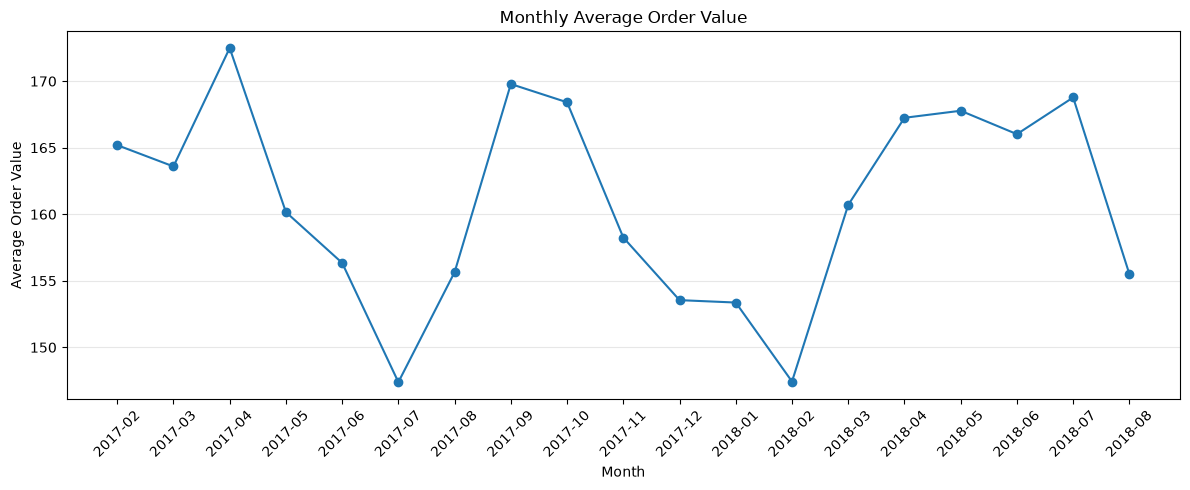

In [397]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_revenue_complete["month"],
    monthly_revenue_complete["avg_order_value"],
    marker="o"
)

plt.title("Monthly Average Order Value")
plt.xlabel("Month")
plt.ylabel("Average Order Value")

plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

### Revenue Drivers — Business Insights

The comparison between monthly revenue and order volume shows a strong
relationship between the number of orders and total revenue.

As monthly order volume increased, total revenue generally increased as
well. This suggests that order volume was a major driver of the company's
revenue growth.

In contrast, average order value fluctuated within a relatively stable
range and did not show a consistent long-term upward trend.

Therefore, the observed revenue growth appears to have been driven more by
increasing transaction volume than by a sustained increase in customer
spending per order.

This suggests that customer acquisition, order frequency, and transaction
volume were important contributors to business growth.

([<matplotlib.axis.XTick at 0x21bcfbd0a50>,
 [Text(0, 0, '2017-02'),
  Text(1, 0, '2017-03'),
  Text(2, 0, '2017-04'),
  Text(3, 0, '2017-05'),
  Text(4, 0, '2017-06'),
  Text(5, 0, '2017-07'),
  Text(6, 0, '2017-08'),
  Text(7, 0, '2017-09'),
  Text(8, 0, '2017-10'),
  Text(9, 0, '2017-11'),
  Text(10, 0, '2017-12'),
  Text(11, 0, '2018-01'),
  Text(12, 0, '2018-02'),
  Text(13, 0, '2018-03'),
  Text(14, 0, '2018-04'),
  Text(15, 0, '2018-05'),
  Text(16, 0, '2018-06'),
  Text(17, 0, '2018-07'),
  Text(18, 0, '2018-08')])

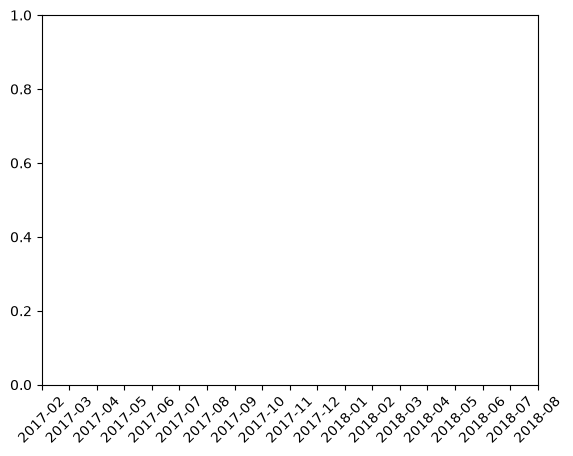

In [398]:
plt.xticks(
    range(len(monthly_revenue_complete)),
    monthly_revenue_complete["month"],
    rotation=45
)

([<matplotlib.axis.XTick at 0x21bd49dc910>,
 [Text(0, 0, '2017-02'),
  Text(2, 0, '2017-04'),
  Text(4, 0, '2017-06'),
  Text(6, 0, '2017-08'),
  Text(8, 0, '2017-10'),
  Text(10, 0, '2017-12'),
  Text(12, 0, '2018-02'),
  Text(14, 0, '2018-04'),
  Text(16, 0, '2018-06'),
  Text(18, 0, '2018-08')])

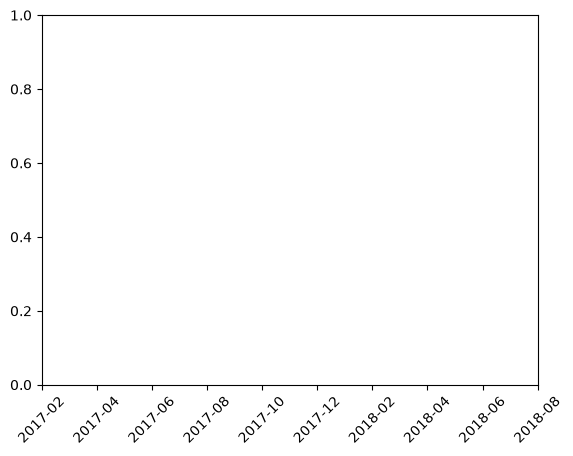

In [399]:
plt.xticks(
    range(0, len(monthly_revenue_complete), 2),
    monthly_revenue_complete["month"].iloc[::2],
    rotation=45
)

## 5. Product Category Performance

### Business Question

Which product categories are the major contributors to total revenue?

We combine order-item transactions with product category information to
measure revenue, items sold, average item price, and revenue contribution
by product category.

In [400]:
category_performance = (
    order_items
    .merge(
        products[["product_id", "product_category_name"]],
        on="product_id",
        how="left"
    )
)

category_performance["product_category_name"] = (
    category_performance["product_category_name"]
    .fillna("unknown")
)

category_performance.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim


In [401]:
category_revenue = (
    category_performance
    .groupby("product_category_name")
    .agg(
        total_revenue=("price", "sum"),
        items_sold=("order_item_id", "count"),
        avg_item_price=("price", "mean")
    )
    .sort_values("total_revenue", ascending=False)
)

category_revenue["revenue_share_pct"] = (
    category_revenue["total_revenue"]
    / category_revenue["total_revenue"].sum()
    * 100
)

category_revenue.round(2)

,total_revenue,items_sold,avg_item_price,revenue_share_pct
product_category_name,,,,
beleza_saude,1258681.34,9670,130.16,9.26
relogios_presentes,1205005.68,5991,201.14,8.87
cama_mesa_banho,1036988.68,11115,93.30,7.63
esporte_lazer,988048.97,8641,114.34,7.27
informatica_acessorios,911954.32,7827,116.51,6.71
...,...,...,...,...
flores,1110.04,33,33.64,0.01
casa_conforto_2,760.27,30,25.34,0.01
cds_dvds_musicais,730.00,14,52.14,0.01


In [402]:
category_revenue.head(15).round(2)

,total_revenue,items_sold,avg_item_price,revenue_share_pct
product_category_name,,,,
beleza_saude,1258681.34,9670,130.16,9.26
relogios_presentes,1205005.68,5991,201.14,8.87
cama_mesa_banho,1036988.68,11115,93.30,7.63
esporte_lazer,988048.97,8641,114.34,7.27
informatica_acessorios,911954.32,7827,116.51,6.71
moveis_decoracao,729762.49,8334,87.56,5.37
cool_stuff,635290.85,3796,167.36,4.67
utilidades_domesticas,632248.66,6964,90.79,4.65
automotivo,592720.11,4235,139.96,4.36


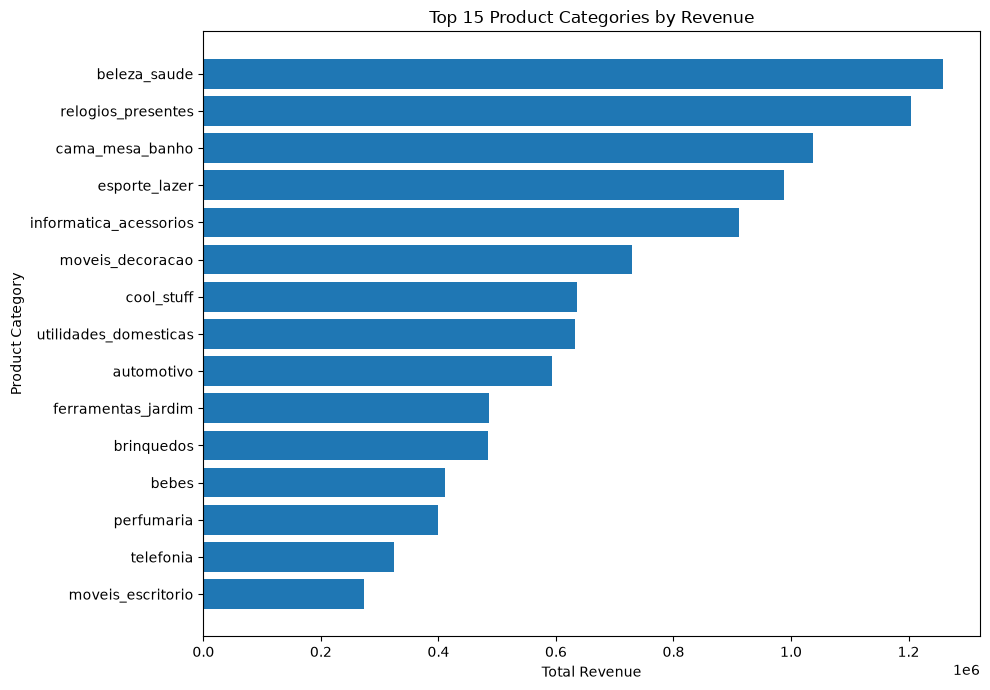

In [403]:
top_categories = (
    category_revenue
    .head(15)
    .sort_values("total_revenue")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_categories.index,
    top_categories["total_revenue"]
)

plt.title("Top 15 Product Categories by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

### Category Revenue — Business Insights

The category-level analysis shows that revenue is distributed across a
diverse set of product categories.

`beleza_saude` is the highest-revenue category, contributing approximately
9.26% of total category revenue, followed by `relogios_presentes` and
`cama_mesa_banho`.

The top five categories together contribute approximately 40% of total
category revenue, indicating that the business is not heavily dependent on
a single product category.

The analysis also shows that revenue depends on both sales volume and
average item price. A category with fewer items sold can generate similar
or higher revenue when its average selling price is higher.

## 6. Revenue Concentration by Product Category

### Business Question

How much of the business's total revenue is generated by the highest-performing product categories?

Cumulative revenue share is calculated to understand whether revenue is
highly concentrated among a small number of categories or distributed
across the broader product portfolio.

In [404]:
category_concentration = (
    category_revenue
    .sort_values("total_revenue", ascending=False)
    .copy()
)

category_concentration["cumulative_revenue_share_pct"] = (
    category_concentration["revenue_share_pct"]
    .cumsum()
)

category_concentration[
    [
        "total_revenue",
        "revenue_share_pct",
        "cumulative_revenue_share_pct"
    ]
].head(15).round(2)

,total_revenue,revenue_share_pct,cumulative_revenue_share_pct
product_category_name,,,
beleza_saude,1258681.34,9.26,9.26
relogios_presentes,1205005.68,8.87,18.13
cama_mesa_banho,1036988.68,7.63,25.76
esporte_lazer,988048.97,7.27,33.03
informatica_acessorios,911954.32,6.71,39.74
moveis_decoracao,729762.49,5.37,45.10
cool_stuff,635290.85,4.67,49.78
utilidades_domesticas,632248.66,4.65,54.43
automotivo,592720.11,4.36,58.79


In [405]:
top5_share = (
    category_concentration["revenue_share_pct"]
    .head(5)
    .sum()
)

top10_share = (
    category_concentration["revenue_share_pct"]
    .head(10)
    .sum()
)

pd.Series({
    "Top 5 Category Revenue Share (%)": top5_share,
    "Top 10 Category Revenue Share (%)": top10_share
}).round(2)

Top 5 Category Revenue Share (%)     39.74
Top 10 Category Revenue Share (%)    62.36
dtype: float64

### Revenue Concentration — Business Insights

The top five product categories contribute 39.74% of total category revenue,
while the top ten categories contribute 62.36%.

This indicates moderate revenue concentration across product categories.

Although the top-performing categories are important revenue drivers, a
substantial 37.64% of revenue comes from the remaining categories. Therefore,
the business is not excessively dependent on a small number of categories.

The top categories should be closely monitored because changes in their
performance could have a meaningful impact on overall revenue.

In [406]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [407]:
# Load cleaned datasets

processed_dir = Path("../data/processed")

orders = pd.read_csv(
    processed_dir / "olist_orders_clean.csv"
)

customers_clean = pd.read_csv(
    processed_dir / "olist_customers_clean.csv"
)

order_items_clean = pd.read_csv(
    processed_dir / "olist_order_items_clean.csv"
)

# Convert order purchase timestamp
orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

In [408]:
# Create order-level revenue

order_revenue = (
    order_items_clean
    .groupby("order_id")
    .agg(
        item_value=("price", "sum"),
        freight_value=("freight_value", "sum")
    )
)

order_revenue["total_order_value"] = (
    order_revenue["item_value"]
    + order_revenue["freight_value"]
)

order_revenue.head()

,item_value,freight_value,total_order_value
order_id,,,
00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,72.19
00018f77f2f0320c557190d7a144bdd3,239.90,19.93,259.83
000229ec398224ef6ca0657da4fc703e,199.00,17.87,216.87
00024acbcdf0a6daa1e931b038114c75,12.99,12.79,25.78
00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,218.04


## 7. Customer Behavior Analysis

### Business Question

How do customers differ in their purchasing behavior?

This analysis aggregates order-level revenue at the customer level to
understand customer purchase frequency and spending behavior.

Customers are classified into:

- **One-time customers:** Customers with exactly one order
- **Repeat customers:** Customers with two or more orders

The analysis compares customer count, order frequency, total spending,
average spending, and revenue contribution between the two groups.

In [409]:
customer_behavior = (
    orders[
        ["order_id", "customer_id"]
    ]
    .merge(
        customers_clean[
            ["customer_id", "customer_unique_id"]
        ],
        on="customer_id",
        how="left"
    )
    .merge(
        order_revenue[
            ["total_order_value"]
        ],
        left_on="order_id",
        right_index=True,
        how="inner"
    )
)

customer_behavior.head()

,order_id,customer_id,customer_unique_id,total_order_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6,28.62


In [410]:
customer_summary = (
    customer_behavior
    .groupby("customer_unique_id")
    .agg(
        order_count=("order_id", "nunique"),
        total_spend=("total_order_value", "sum"),
        avg_order_value=("total_order_value", "mean")
    )
)

customer_summary.head(10).round(2)

,order_count,total_spend,avg_order_value
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90
0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19
0000f46a3911fa3c0805444483337064,1,86.22,86.22
0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62
0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89
0004bd2a26a76fe21f786e4fbd80607f,1,166.98,166.98
00050ab1314c0e55a6ca13cf7181fecf,1,35.38,35.38
00053a61a98854899e70ed204dd4bafe,1,419.18,419.18
0005e1862207bf6ccc02e4228effd9a0,1,150.12,150.12


### Customer Segmentation: One-time vs Repeat

Customers are classified based on the number of orders placed.

Customers with one order are considered one-time customers, while
customers with two or more orders are considered repeat customers.

In [411]:
customer_summary["customer_type"] = np.where(
    customer_summary["order_count"] == 1,
    "One-time",
    "Repeat"
)

customer_summary["customer_type"].value_counts()

customer_type
One-time    92507
Repeat       2913
Name: count, dtype: int64

In [412]:
customer_type_summary = (
    customer_summary
    .groupby("customer_type")
    .agg(
        customers=("order_count", "count"),
        avg_orders=("order_count", "mean"),
        avg_spend=("total_spend", "mean"),
        median_spend=("total_spend", "median"),
        total_revenue=("total_spend", "sum")
    )
)

customer_type_summary.round(2)

,customers,avg_orders,avg_spend,median_spend,total_revenue
customer_type,,,,,
One-time,92507,1.00,161.49,105.66,14939106.99
Repeat,2913,2.11,310.49,225.63,904446.25


### Customer Type Distribution

The distribution of one-time and repeat customers is visualized to
understand the customer retention pattern.

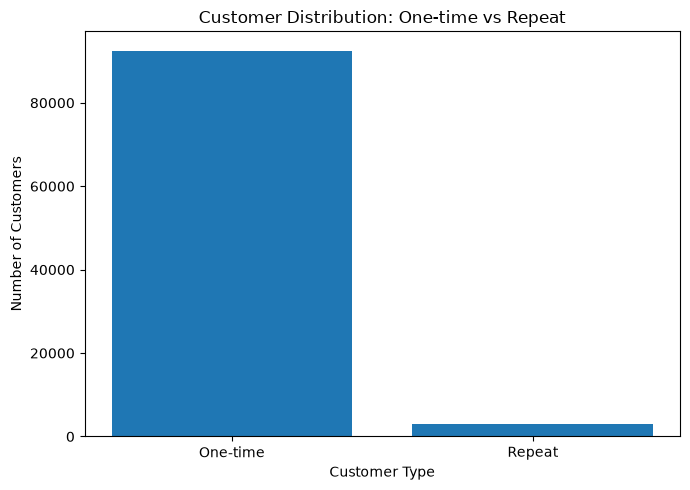

In [413]:
customer_counts = (
    customer_summary["customer_type"]
    .value_counts()
)

plt.figure(figsize=(7, 5))

plt.bar(
    customer_counts.index,
    customer_counts.values
)

plt.title("Customer Distribution: One-time vs Repeat")
plt.xlabel("Customer Type")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### Average Customer Spending

Average total customer spending is compared between one-time and repeat
customers to understand whether repeat customers generate higher customer
value.

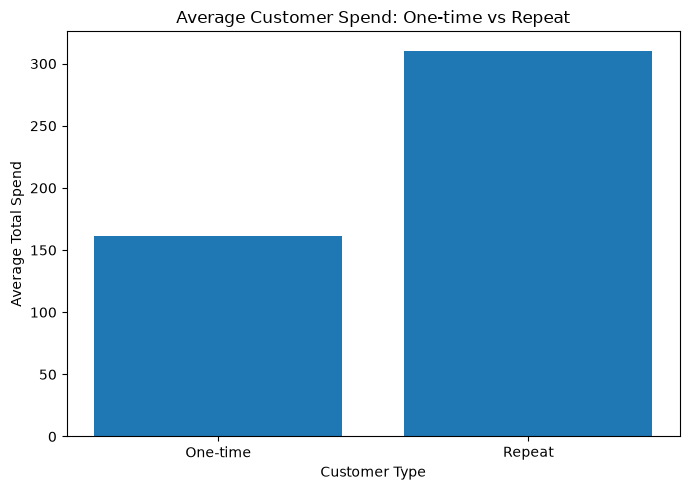

In [414]:
plt.figure(figsize=(7, 5))

plt.bar(
    customer_type_summary.index,
    customer_type_summary["avg_spend"]
)

plt.title("Average Customer Spend: One-time vs Repeat")
plt.xlabel("Customer Type")
plt.ylabel("Average Total Spend")

plt.tight_layout()
plt.show()

### Customer Behavior — Business Insights

The analysis compares one-time and repeat customers based on order
frequency and spending behavior.

The results will be used to determine whether repeat customers have higher
customer value and how much revenue is generated by each customer segment.

This analysis helps evaluate the importance of customer retention and
repeat purchasing behavior for overall business performance.

### Customer Revenue Contribution

The revenue contribution of one-time and repeat customers is compared to
understand the financial importance of repeat purchasing behavior.

This helps determine whether repeat customers contribute a disproportionate
share of total revenue relative to their customer count.

In [415]:
customer_revenue_contribution = (
    customer_type_summary["total_revenue"]
    / customer_type_summary["total_revenue"].sum()
    * 100
)

customer_revenue_contribution.round(2)

customer_type
One-time    94.29
Repeat       5.71
Name: total_revenue, dtype: float64

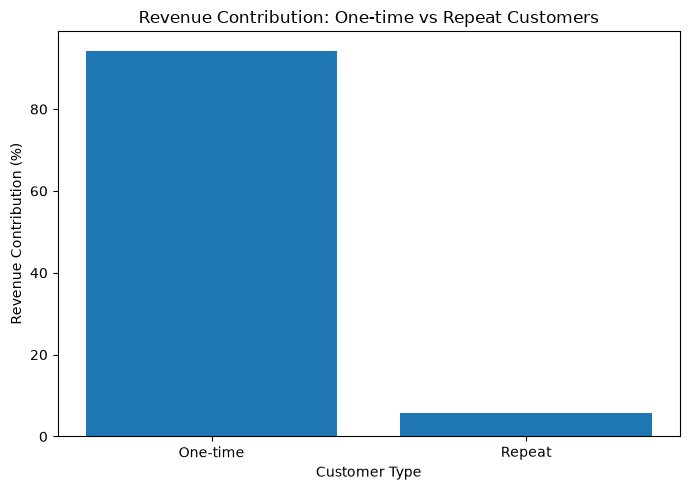

In [416]:
plt.figure(figsize=(7, 5))

plt.bar(
    customer_revenue_contribution.index,
    customer_revenue_contribution.values
)

plt.title("Revenue Contribution: One-time vs Repeat Customers")
plt.xlabel("Customer Type")
plt.ylabel("Revenue Contribution (%)")

plt.tight_layout()
plt.show()

### Customer Behavior — Final Business Insights

The analysis shows a very large difference between one-time and repeat
customers.

One-time customers represent the vast majority of the customer base and
contribute approximately 94% of total customer revenue.

Repeat customers represent only a small portion of customers and contribute
approximately 6% of total customer revenue.

However, repeat customers have substantially higher average spending than
one-time customers. This indicates that repeat customers are more valuable
individually, but their overall financial contribution remains limited due
to their low proportion in the customer base.

From a business perspective, improving customer retention and encouraging
second purchases could represent a significant growth opportunity.

## 8. Customer Purchase Frequency

### Business Question

How frequently do customers place orders?

We analyze the distribution of orders per customer to understand customer
purchase frequency and identify how many customers make multiple purchases.

This helps us understand the current level of customer retention and
whether customers typically make a single purchase or return for additional
orders.

In [417]:
order_frequency = (
    customer_summary["order_count"]
    .value_counts()
    .sort_index()
)

order_frequency.head(15)

order_count
1     92507
2      2673
3       192
4        29
5         9
6         5
7         3
9         1
16        1
Name: count, dtype: int64

In [418]:
order_frequency_pct = (
    order_frequency
    / order_frequency.sum()
    * 100
)

order_frequency_pct.round(2)

order_count
1     96.95
2      2.80
3      0.20
4      0.03
5      0.01
6      0.01
7      0.00
9      0.00
16     0.00
Name: count, dtype: float64

### Customer Order Frequency Distribution

The distribution of orders per customer is visualized to identify the
most common customer purchase frequency.

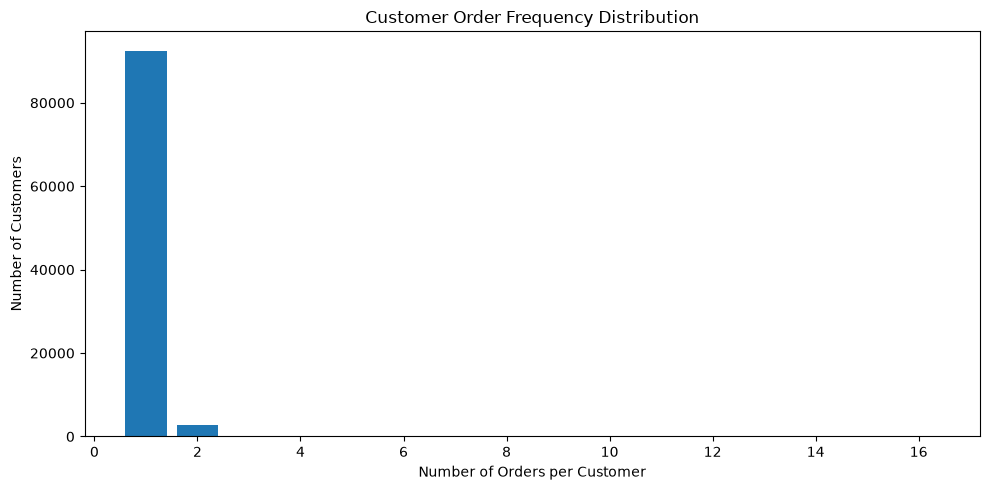

In [419]:
plt.figure(figsize=(10, 5))

plt.bar(
    order_frequency.index,
    order_frequency.values
)

plt.title("Customer Order Frequency Distribution")
plt.xlabel("Number of Orders per Customer")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### Customer Purchase Frequency — Initial Findings

The customer order frequency distribution is highly concentrated at one
order.

The vast majority of customers place only one order, while a very small
proportion of customers place multiple orders.

Approximately 96.9% of customers are one-time customers, while only about
3.1% are repeat customers.

This confirms that repeat purchasing is relatively uncommon in the dataset
and highlights customer retention as an important potential growth
opportunity.

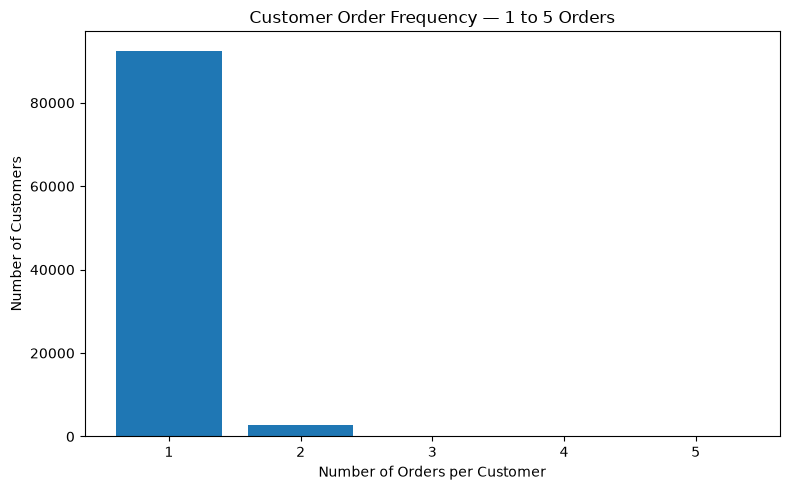

In [420]:
frequency_top = (
    order_frequency
    .loc[order_frequency.index <= 5]
)

plt.figure(figsize=(8, 5))

plt.bar(
    frequency_top.index.astype(str),
    frequency_top.values
)

plt.title("Customer Order Frequency — 1 to 5 Orders")
plt.xlabel("Number of Orders per Customer")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

### Customer Purchase Frequency — Business Insights

The customer order frequency distribution is highly concentrated at one
order.

Most customers place only a single order, while customers placing two or
more orders represent a very small portion of the customer base.

The number of customers decreases sharply as order frequency increases,
indicating low repeat-purchase behavior.

Combined with the earlier finding that repeat customers have higher average
spending, this suggests that increasing second-purchase conversion could be
an important customer-retention opportunity.

## 9. High-Value Customer Analysis

### Business Question

Which customers generate the highest total spending?

We rank customers based on their total spending to identify high-value
customers and understand the concentration of customer-level revenue.

This analysis helps identify customers who contribute disproportionately
to overall revenue.

In [421]:
top_customers = (
    customer_summary
    .sort_values("total_spend", ascending=False)
    .head(20)
)

top_customers[
    [
        "order_count",
        "total_spend",
        "avg_order_value",
        "customer_type"
    ]
].round(2)

,order_count,total_spend,avg_order_value,customer_type
customer_unique_id,,,,
0a0a92112bd4c708ca5fde585afaa872,1,13664.08,13664.08,One-time
da122df9eeddfedc1dc1f5349a1a690c,2,7571.63,3785.82,Repeat
763c8b1c9c68a0229c42c9fc6f662b93,1,7274.88,7274.88,One-time
dc4802a71eae9be1dd28f5d788ceb526,1,6929.31,6929.31,One-time
459bef486812aa25204be022145caa62,1,6922.21,6922.21,One-time
ff4159b92c40ebe40454e3e6a7c35ed6,1,6726.66,6726.66,One-time
4007669dec559734d6f53e029e360987,1,6081.54,6081.54,One-time
5d0a2980b292d049061542014e8960bf,1,4809.44,4809.44,One-time
eebb5dda148d3893cdaf5b5ca3040ccb,1,4764.34,4764.34,One-time


In [422]:
top_10_customer_share = (
    top_customers.head(10)["total_spend"].sum()
    / customer_summary["total_spend"].sum()
    * 100
)

top_10_customer_share.round(2)

np.float64(0.44)

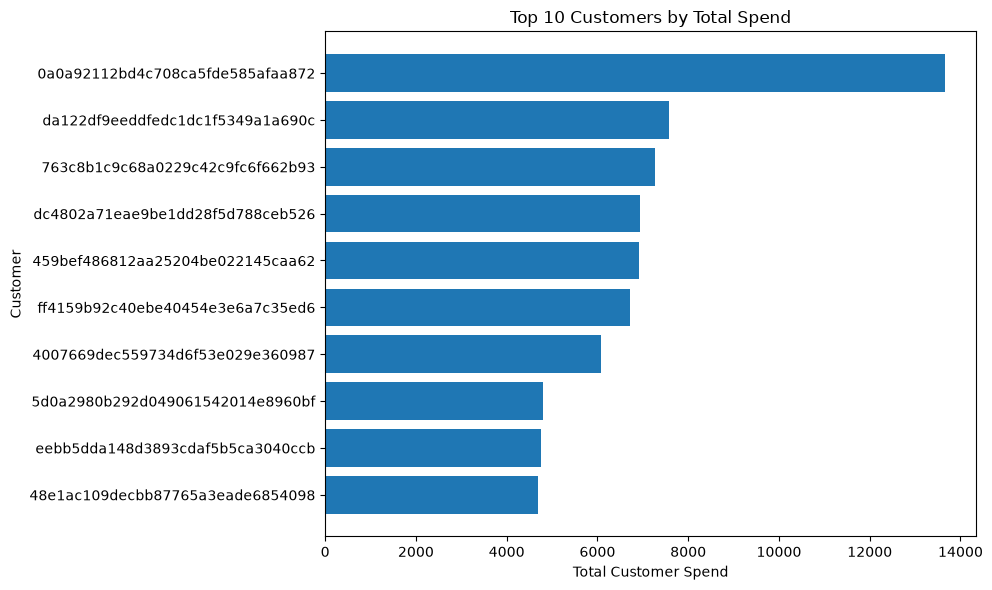

In [423]:
top_10 = (
    customer_summary
    .sort_values("total_spend", ascending=False)
    .head(10)
    .sort_values("total_spend")
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_10.index.astype(str),
    top_10["total_spend"]
)

plt.title("Top 10 Customers by Total Spend")
plt.xlabel("Total Customer Spend")
plt.ylabel("Customer")

plt.tight_layout()
plt.show()

### High-Value Customer — Business Insights

The highest-spending customers generate substantially more revenue than the
average customer, with the top customer spending approximately 13.7K.

However, the top 10 customers together contribute only about 0.64% of total
customer revenue.

This indicates that overall revenue is highly distributed across the
customer base and is not dependent on a small group of high-value customers.

The analysis also shows that some high-value customers are repeat
customers, but several high-value customers are still classified as
one-time customers.

From a business perspective, customer concentration risk appears low,
while converting high-value one-time customers into repeat customers could
provide an additional retention opportunity.

## 10. Customer Spending Distribution

### Business Question

How is customer spending distributed across the customer base?

We analyze total customer spending using descriptive statistics and
percentiles to understand typical customer value and identify whether a
small group of high-spending customers creates a long right tail.

Median and percentile-based measures are used alongside the mean because
customer spending may be highly skewed.

In [424]:
customer_summary["total_spend"].describe().round(2)

count    95420.00
mean       166.04
std        228.32
min          9.59
25%         63.10
50%        107.94
75%        183.22
max      13664.08
Name: total_spend, dtype: float64

In [425]:
customer_summary["total_spend"].quantile(
    [0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).round(2)

0.25      63.10
0.50     107.94
0.75     183.22
0.90     319.11
0.95     473.82
0.99    1113.57
Name: total_spend, dtype: float64

### Customer Spending Distribution

The distribution of total customer spending is visualized to identify
skewness and the presence of high-spending customers.

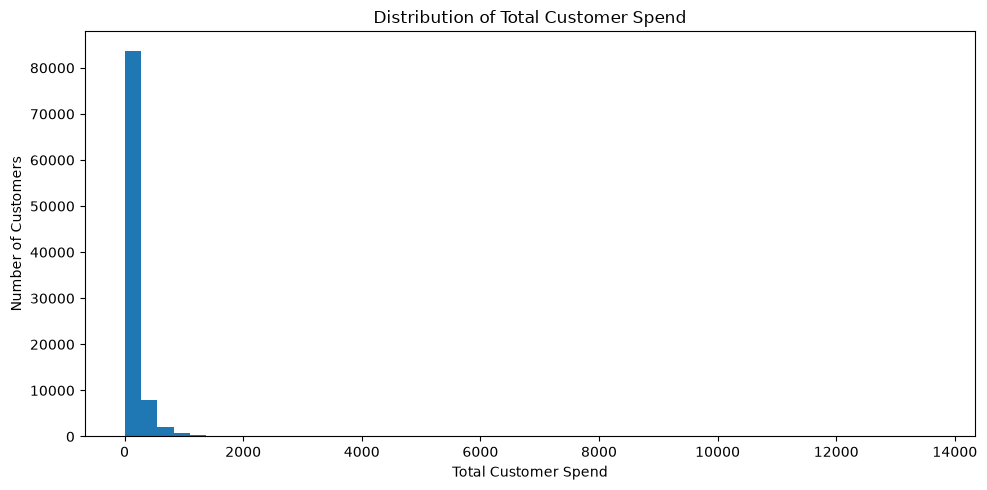

In [426]:
plt.figure(figsize=(10, 5))

plt.hist(
    customer_summary["total_spend"],
    bins=50
)

plt.title("Distribution of Total Customer Spend")
plt.xlabel("Total Customer Spend")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

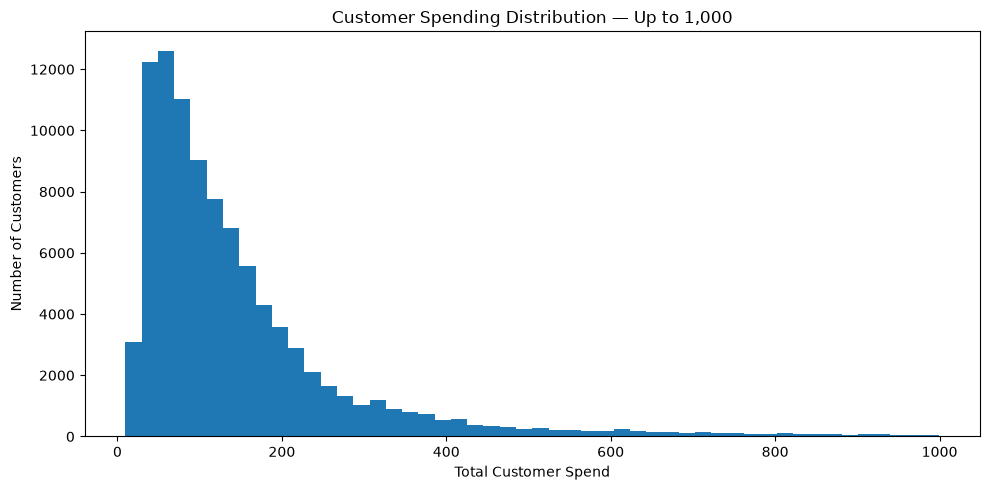

In [427]:
plt.figure(figsize=(10, 5))

plt.hist(
    customer_summary.loc[
        customer_summary["total_spend"] <= 1000,
        "total_spend"
    ],
    bins=50
)

plt.title("Customer Spending Distribution — Up to 1,000")
plt.xlabel("Total Customer Spend")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

### Customer Spending Distribution — Business Insights

Customer spending is strongly right-skewed.

The majority of customers have relatively low total spending, while a small
number of customers contribute much higher spending amounts and create a
long right tail in the distribution.

Because of this skewness, the mean customer spend is higher than the median
and does not fully represent the spending behavior of a typical customer.

Percentile analysis provides a better understanding of the customer spending
distribution and highlights the presence of a small high-spending segment.

This indicates that customer value is heterogeneous, with most customers
generating relatively modest revenue and a smaller group generating
substantially higher revenue.

## 11. Customer Retention Analysis

### Business Question

What proportion of customers return and place more than one order?

Customer retention is measured using the repeat purchase rate, which is
defined as the percentage of unique customers who placed two or more orders.

This KPI helps quantify the current level of customer retention and provides
a baseline for evaluating future retention strategies.

In [428]:
total_customers = customer_summary.shape[0]

repeat_customers = (
    customer_summary["customer_type"] == "Repeat"
).sum()

repeat_purchase_rate = (
    repeat_customers
    / total_customers
    * 100
)

pd.Series({
    "Total Customers": total_customers,
    "Repeat Customers": repeat_customers,
    "One-time Customers": total_customers - repeat_customers,
    "Repeat Purchase Rate (%)": repeat_purchase_rate
}).round(2)

Total Customers             95420.00
Repeat Customers             2913.00
One-time Customers          92507.00
Repeat Purchase Rate (%)        3.05
dtype: float64

### Customer Retention Distribution

The customer base is divided into one-time and repeat customers to
visualize the current retention structure.

A low repeat purchase rate indicates that most customers do not return for
another purchase within the available transaction period.

In [429]:
retention_distribution = (
    customer_summary["customer_type"]
    .value_counts(normalize=True)
    * 100
)

retention_distribution.round(2)

customer_type
One-time    96.95
Repeat       3.05
Name: proportion, dtype: float64

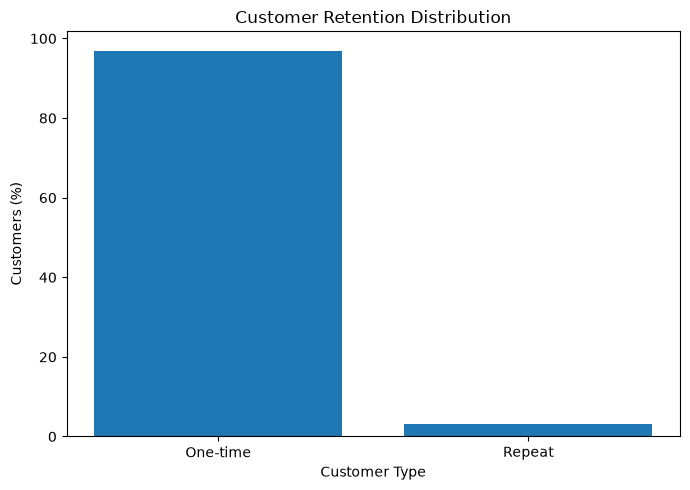

In [430]:
plt.figure(figsize=(7, 5))

plt.bar(
    retention_distribution.index,
    retention_distribution.values
)

plt.title("Customer Retention Distribution")
plt.xlabel("Customer Type")
plt.ylabel("Customers (%)")

plt.tight_layout()
plt.show()

### Customer Retention — Business Insights

The repeat purchase rate provides a baseline measure of customer retention.

The analysis shows that only a small proportion of customers return to make
additional purchases, while the vast majority remain one-time customers.

This indicates that customer retention is a significant business
opportunity. Increasing the conversion of one-time customers into repeat
customers could potentially increase customer lifetime value and long-term
revenue.

### Customer Retention — Business Insights

The customer retention analysis shows that 96.95% of customers are
one-time customers, while only 3.05% are repeat customers.

This indicates a very low repeat purchase rate within the observed
transaction period.

Although repeat customers represent a small portion of the customer base,
earlier analysis showed that they have higher average spending than
one-time customers.

Therefore, improving the conversion of one-time customers into repeat
customers represents an important potential growth opportunity for the
business.

The 3.05% repeat purchase rate can also be used as a baseline KPI for
future retention analysis.

## 12. Order Basket Analysis

### Business Question

How many products do customers typically purchase in a single order?

We calculate the number of items in each order to understand the typical
basket size and identify whether orders usually contain a single product
or multiple products.

Basket size can help understand customer purchasing behavior and potential
opportunities for cross-selling and bundling.

In [431]:
items_per_order = (
    order_items_clean
    .groupby("order_id")
    .agg(
        items_count=("order_item_id", "count"),
        unique_products=("product_id", "nunique")
    )
)

items_per_order.head()

,items_count,unique_products
order_id,,
00010242fe8c5a6d1ba2dd792cb16214,1,1
00018f77f2f0320c557190d7a144bdd3,1,1
000229ec398224ef6ca0657da4fc703e,1,1
00024acbcdf0a6daa1e931b038114c75,1,1
00042b26cf59d7ce69dfabb4e55b4fd9,1,1


In [432]:
items_per_order.describe().round(2)

,items_count,unique_products
count,98666.00,98666.00
mean,1.14,1.04
std,0.54,0.23
min,1.00,1.00
25%,1.00,1.00
50%,1.00,1.00
75%,1.00,1.00
max,21.00,8.00


In [433]:
basket_summary = pd.Series({
    "Average Items per Order": items_per_order["items_count"].mean(),
    "Median Items per Order": items_per_order["items_count"].median(),
    "Maximum Items in an Order": items_per_order["items_count"].max()
})

basket_summary.round(2)

Average Items per Order       1.14
Median Items per Order        1.00
Maximum Items in an Order    21.00
dtype: float64

### Basket Size Distribution

The distribution of items per order is visualized to understand the typical
basket size and identify orders containing unusually large numbers of items.

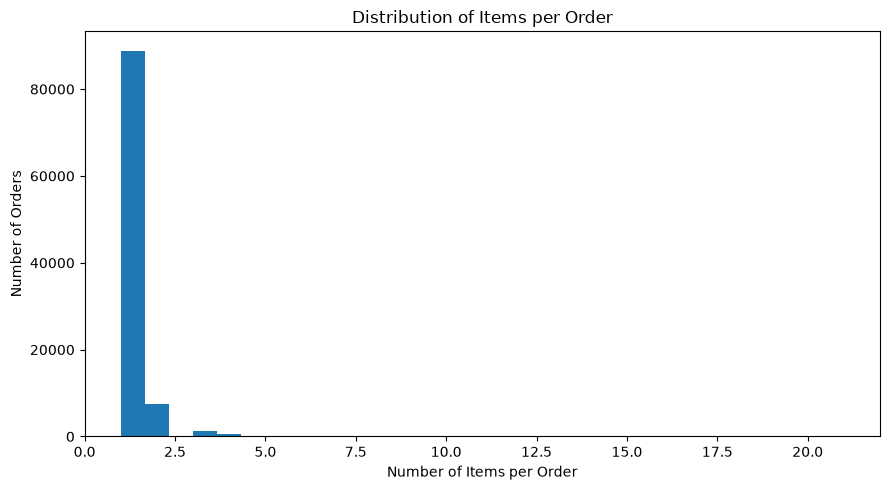

In [434]:
plt.figure(figsize=(9, 5))

plt.hist(
    items_per_order["items_count"],
    bins=30
)

plt.title("Distribution of Items per Order")
plt.xlabel("Number of Items per Order")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

In [435]:
items_per_order["items_count"].value_counts().sort_index().head(15)

items_count
1     88863
2      7516
3      1322
4       505
5       204
6       198
7        22
8         8
9         3
10        8
11        4
12        5
13        1
14        2
15        2
Name: count, dtype: int64

### Order Basket Analysis — Business Insights

The average order contains 1.14 items, while the median order contains only
one item.

Approximately 75% of orders contain a single item, indicating that the
typical customer purchase is a single-product transaction.

The number of orders decreases sharply as basket size increases, while a
small number of orders contain substantially more items.

This suggests that multi-item purchasing is relatively uncommon in the
dataset and may represent an opportunity for cross-selling, product
bundling, and increasing basket size.

## 13. Basket Size vs Order Value

### Business Question

Does purchasing more items in an order lead to a higher order value?

We compare basket size with total order value to understand the relationship
between the number of items purchased and the monetary value of an order.

This can help identify whether increasing basket size could be an effective
way to increase revenue per transaction.

In [436]:
order_basket_value = (
    items_per_order
    .merge(
        order_revenue[["total_order_value"]],
        left_index=True,
        right_index=True,
        how="inner"
    )
)

order_basket_value.head()

,items_count,unique_products,total_order_value
order_id,,,
00010242fe8c5a6d1ba2dd792cb16214,1,1,72.19
00018f77f2f0320c557190d7a144bdd3,1,1,259.83
000229ec398224ef6ca0657da4fc703e,1,1,216.87
00024acbcdf0a6daa1e931b038114c75,1,1,25.78
00042b26cf59d7ce69dfabb4e55b4fd9,1,1,218.04


In [437]:
basket_value_summary = (
    order_basket_value
    .groupby("items_count")
    .agg(
        order_count=("total_order_value", "count"),
        avg_order_value=("total_order_value", "mean"),
        median_order_value=("total_order_value", "median")
    )
)

basket_value_summary.head(10).round(2)

,order_count,avg_order_value,median_order_value
items_count,,,
1,88863,150.75,99.03
2,7516,212.31,155.14
3,1322,292.74,209.92
4,505,391.66,269.52
5,204,473.37,345.90
6,198,531.52,323.93
7,22,611.45,430.01
8,8,2304.93,564.59
9,3,1092.24,838.98


### Basket Size and Average Order Value

Average order value is compared across different basket sizes to determine
whether larger baskets are associated with higher transaction values.

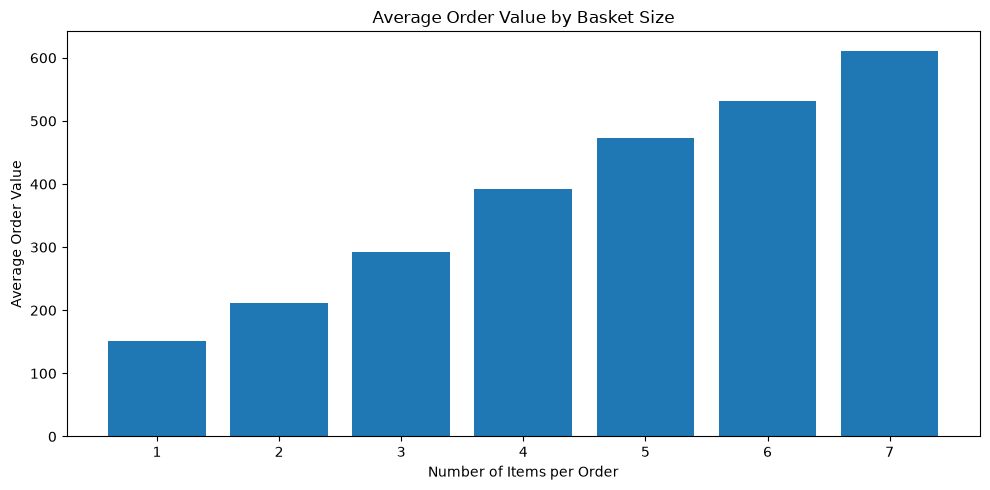

In [438]:
basket_value_plot = (
    basket_value_summary
    .loc[basket_value_summary["order_count"] >= 20]
    .head(10)
)

plt.figure(figsize=(10, 5))

plt.bar(
    basket_value_plot.index.astype(str),
    basket_value_plot["avg_order_value"]
)

plt.title("Average Order Value by Basket Size")
plt.xlabel("Number of Items per Order")
plt.ylabel("Average Order Value")

plt.tight_layout()
plt.show()

### Basket Size vs Order Value — Business Insights

The analysis shows a clear positive relationship between basket size and
average order value.

Orders containing more items generally have substantially higher average
order values. For example, the average order value increases from
approximately 150.75 for single-item orders to approximately 611.45 for
seven-item orders.

This indicates that larger baskets are associated with higher transaction
values.

From a business perspective, encouraging customers to add relevant
additional products through cross-selling, product recommendations, or
bundling could be a potential strategy for increasing average order value.

However, this analysis shows an association rather than proving that
increasing basket size directly causes higher order value.

## 14. Product Performance Analysis

### Business Question

Which products generate the highest sales volume and revenue?

Product-level performance is analyzed using the number of units sold,
total revenue, and average selling price.

Comparing sales volume and revenue helps identify whether the most popular
products are also the highest-revenue products.

In [439]:
order_items_clean = pd.read_csv(
    processed_dir / "olist_order_items_clean.csv")

In [440]:
product_performance = (
    order_items_clean
    .groupby("product_id")
    .agg(
        units_sold=("order_item_id", "count"),
        total_revenue=("price", "sum"),
        avg_item_price=("price", "mean")
    )
    .sort_values("units_sold", ascending=False)
)

product_performance.head(10).round(2)

,units_sold,total_revenue,avg_item_price
product_id,,,
aca2eb7d00ea1a7b8ebd4e68314663af,527,37608.90,71.36
99a4788cb24856965c36a24e339b6058,488,43025.56,88.17
422879e10f46682990de24d770e7f83d,484,26577.22,54.91
389d119b48cf3043d311335e499d9c6b,392,21440.59,54.70
368c6c730842d78016ad823897a372db,388,21056.80,54.27
53759a2ecddad2bb87a079a1f1519f73,373,20387.20,54.66
d1c427060a0f73f6b889a5c7c61f2ac4,343,47214.51,137.65
53b36df67ebb7c41585e8d54d6772e08,323,37683.42,116.67
154e7e31ebfa092203795c972e5804a6,281,6325.19,22.51


In [441]:
top_products_volume = (
    product_performance
    .head(15)
)

top_products_volume.round(2)

,units_sold,total_revenue,avg_item_price
product_id,,,
aca2eb7d00ea1a7b8ebd4e68314663af,527,37608.90,71.36
99a4788cb24856965c36a24e339b6058,488,43025.56,88.17
422879e10f46682990de24d770e7f83d,484,26577.22,54.91
389d119b48cf3043d311335e499d9c6b,392,21440.59,54.70
368c6c730842d78016ad823897a372db,388,21056.80,54.27
53759a2ecddad2bb87a079a1f1519f73,373,20387.20,54.66
d1c427060a0f73f6b889a5c7c61f2ac4,343,47214.51,137.65
53b36df67ebb7c41585e8d54d6772e08,323,37683.42,116.67
154e7e31ebfa092203795c972e5804a6,281,6325.19,22.51


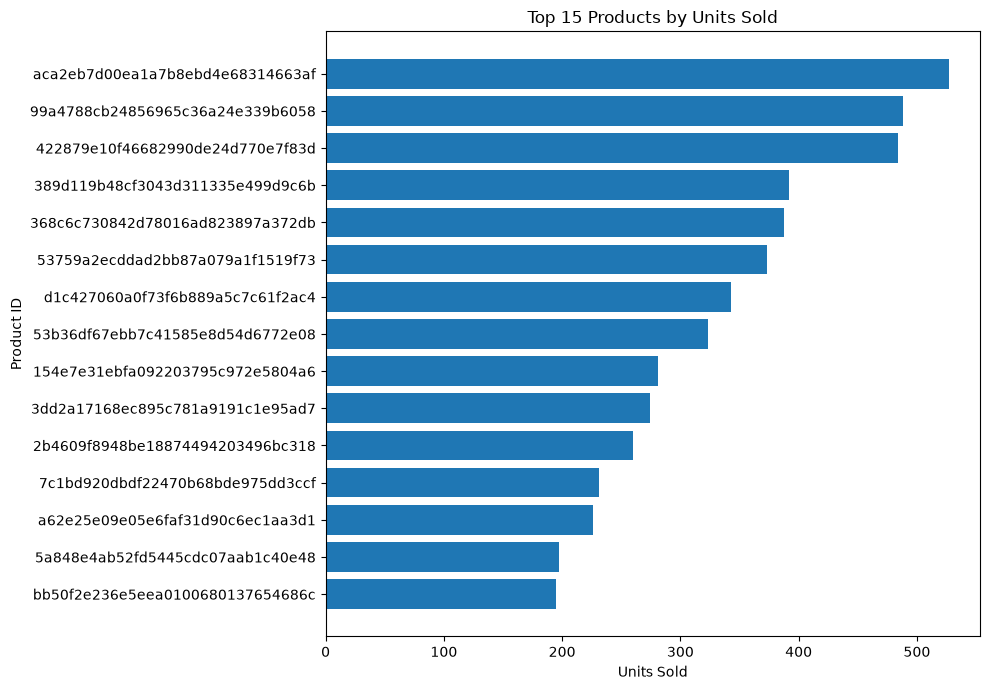

In [442]:
plt.figure(figsize=(10, 7))

plt.barh(
    top_products_volume.index.astype(str),
    top_products_volume["units_sold"]
)

plt.title("Top 15 Products by Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Product ID")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Top Products by Revenue

Products are ranked by total revenue to identify the products that
contribute the most monetary value to the business.

A product with high sales volume may not necessarily generate the highest
revenue if its selling price is relatively low.

In [443]:
top_products_revenue = (
    product_performance
    .sort_values("total_revenue", ascending=False)
    .head(15)
)

top_products_revenue.round(2)

,units_sold,total_revenue,avg_item_price
product_id,,,
bb50f2e236e5eea0100680137654686c,195,63885.00,327.62
6cdd53843498f92890544667809f1595,156,54730.20,350.83
d6160fb7873f184099d9bc95e30376af,35,48899.34,1397.12
d1c427060a0f73f6b889a5c7c61f2ac4,343,47214.51,137.65
99a4788cb24856965c36a24e339b6058,488,43025.56,88.17
3dd2a17168ec895c781a9191c1e95ad7,274,41082.60,149.94
25c38557cf793876c5abdd5931f922db,38,38907.32,1023.88
5f504b3a1c75b73d6151be81eb05bdc9,63,37733.90,598.95
53b36df67ebb7c41585e8d54d6772e08,323,37683.42,116.67


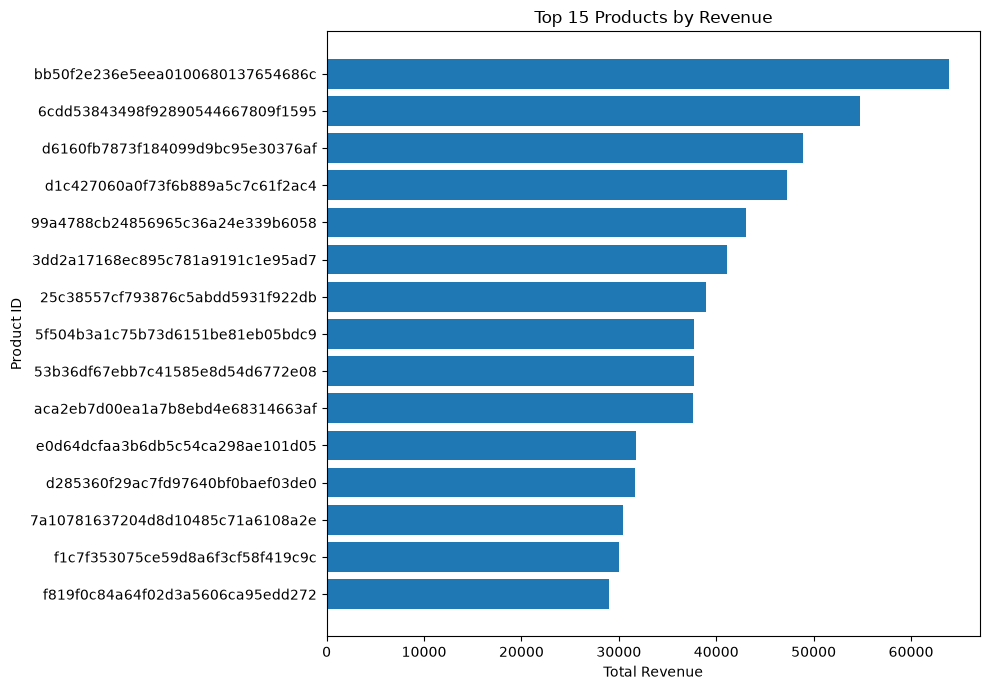

In [444]:
plt.figure(figsize=(10, 7))

plt.barh(
    top_products_revenue.index.astype(str),
    top_products_revenue["total_revenue"]
)

plt.title("Top 15 Products by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Product ID")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Product Performance — Business Insights

The analysis shows that the products with the highest sales volume are not
necessarily the products generating the highest revenue.

The top-selling product sold approximately 527 units and generated around
37.6K in revenue, while the highest-revenue product generated approximately
63.9K from only 195 units.

This difference is driven primarily by differences in product selling prices.

Therefore, product performance should be evaluated using both sales volume
and revenue rather than relying on a single metric.

High-volume products indicate strong customer demand, while high-revenue
products indicate stronger monetary contribution to the business.

## 15. Product Category Performance

### Business Question

Which product categories generate the highest sales volume and revenue?

Product-level transactions are combined with product category information
to evaluate category performance.

Both units sold and total revenue are analyzed because a category with high
sales volume may not necessarily generate the highest revenue.

In [445]:

products_clean = pd.read_csv(
    processed_dir / "olist_products_clean.csv"
)

category_translation_clean = pd.read_csv(
    processed_dir / "product_category_translation_clean.csv"
)

In [446]:
product_category = (
    order_items_clean
    .merge(
        products_clean[
            ["product_id", "product_category_name"]
        ],
        on="product_id",
        how="left"
    )
    .merge(
        category_translation_clean[
            ["product_category_name", "product_category_name_english"]
        ],
        on="product_category_name",
        how="left"
    )
)

product_category.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,garden_tools


In [447]:
category_performance = (
    product_category
    .groupby("product_category_name_english")
    .agg(
        units_sold=("order_item_id", "count"),
        total_revenue=("price", "sum"),
        avg_item_price=("price", "mean"),
        unique_products=("product_id", "nunique")
    )
    .sort_values("total_revenue", ascending=False)
)

category_performance.head(15).round(2)

,units_sold,total_revenue,avg_item_price,unique_products
product_category_name_english,,,,
health_beauty,9670,1258681.34,130.16,2444
watches_gifts,5991,1205005.68,201.14,1329
bed_bath_table,11115,1036988.68,93.30,3029
sports_leisure,8641,988048.97,114.34,2867
computers_accessories,7827,911954.32,116.51,1639
furniture_decor,8334,729762.49,87.56,2657
cool_stuff,3796,635290.85,167.36,789
housewares,6964,632248.66,90.79,2335
auto,4235,592720.11,139.96,1900


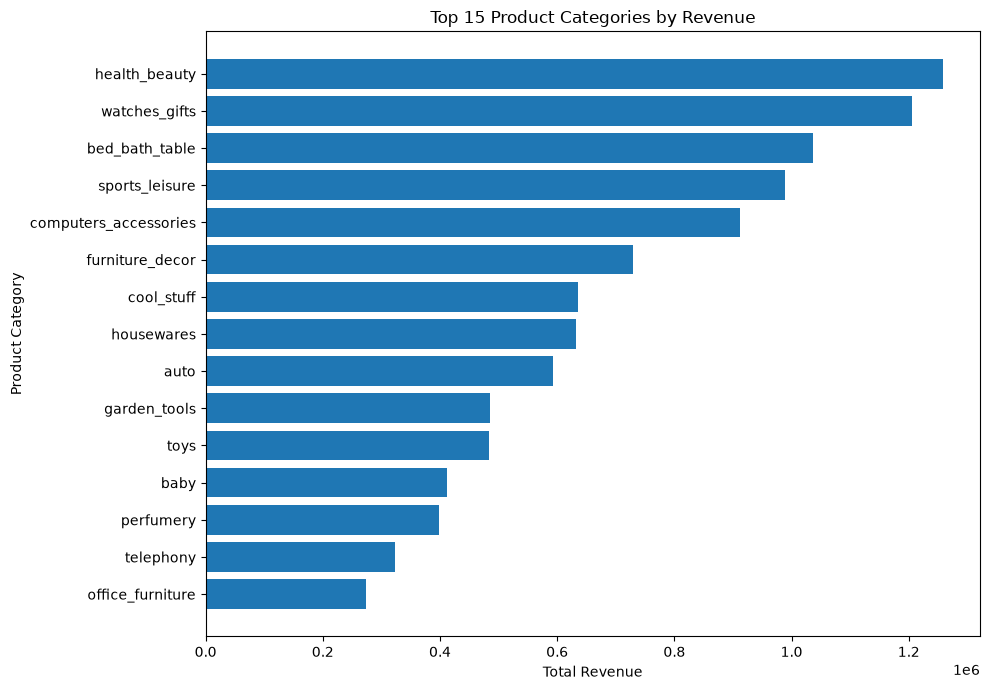

In [448]:
top_categories_revenue = (
    category_performance
    .head(15)
    .sort_values("total_revenue")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_categories_revenue.index,
    top_categories_revenue["total_revenue"]
)

plt.title("Top 15 Product Categories by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

### Top Categories by Sales Volume

Categories are also ranked by units sold to identify the categories with
the highest product demand.

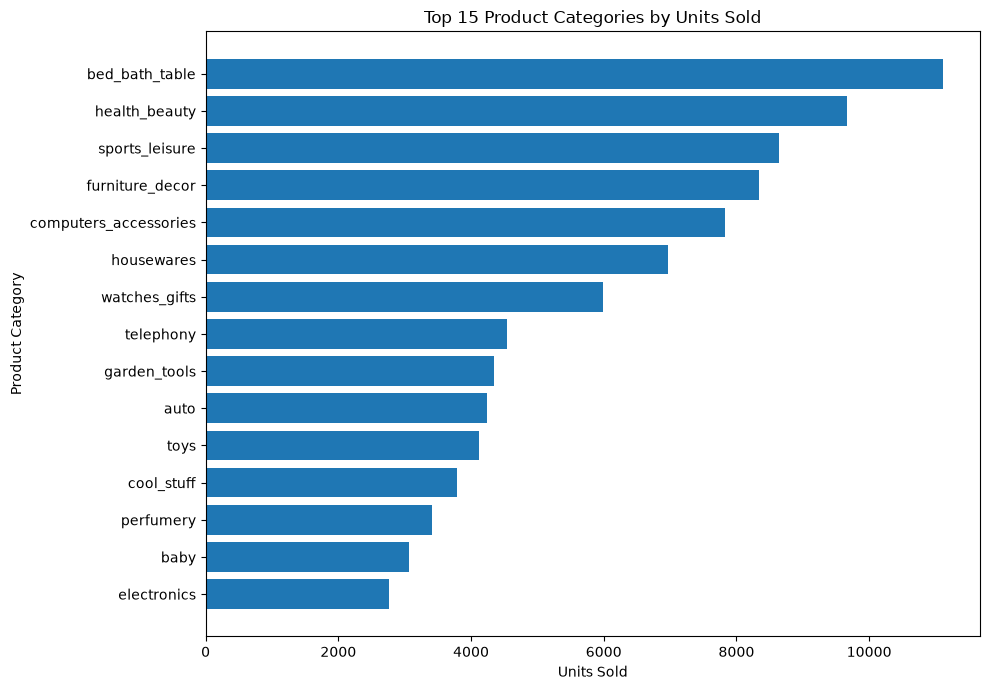

In [449]:
top_categories_volume = (
    category_performance
    .sort_values("units_sold", ascending=False)
    .head(15)
    .sort_values("units_sold")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_categories_volume.index,
    top_categories_volume["units_sold"]
)

plt.title("Top 15 Product Categories by Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()


### Product Category Performance — Business Insights

The analysis shows differences between category sales volume and revenue
performance.

The bed_bath_table category has the highest sales volume, indicating strong
product demand. However, it ranks third in total revenue.

The health_beauty category performs strongly on both metrics, ranking first
in revenue and second in units sold.

The watches_gifts category ranks second in revenue despite not having the
highest sales volume, indicating that its higher average selling prices
contribute significantly to its revenue performance.

Overall, category performance should be evaluated using both units sold and
revenue because sales volume alone does not fully represent monetary
contribution.

This distinction can help the business balance high-demand categories with
high-value revenue-generating categories.

## 16. Category Revenue Concentration

### Business Question

How concentrated is revenue across product categories?

We calculate the percentage of total revenue contributed by the top
categories to understand whether the business depends heavily on a small
number of product categories.

The cumulative revenue contribution of the Top 5 and Top 10 categories is
used as a measure of category concentration.

In [450]:
category_revenue_share = (
    category_performance
    .sort_values("total_revenue", ascending=False)
    .copy()
)

total_category_revenue = (
    category_revenue_share["total_revenue"].sum()
)

category_revenue_share["revenue_share_pct"] = (
    category_revenue_share["total_revenue"]
    / total_category_revenue
    * 100
)

category_revenue_share["cumulative_revenue_pct"] = (
    category_revenue_share["revenue_share_pct"]
    .cumsum()
)

category_revenue_share.head(15).round(2)

,units_sold,total_revenue,avg_item_price,unique_products,revenue_share_pct,cumulative_revenue_pct
product_category_name_english,,,,,,
health_beauty,9670,1258681.34,130.16,2444,9.39,9.39
watches_gifts,5991,1205005.68,201.14,1329,8.99,18.38
bed_bath_table,11115,1036988.68,93.30,3029,7.73,26.11
sports_leisure,8641,988048.97,114.34,2867,7.37,33.48
computers_accessories,7827,911954.32,116.51,1639,6.80,40.28
furniture_decor,8334,729762.49,87.56,2657,5.44,45.73
cool_stuff,3796,635290.85,167.36,789,4.74,50.47
housewares,6964,632248.66,90.79,2335,4.72,55.18
auto,4235,592720.11,139.96,1900,4.42,59.60


In [451]:
concentration_summary = pd.Series({
    "Top 5 Category Revenue Share (%)":
        category_revenue_share["revenue_share_pct"].head(5).sum(),

    "Top 10 Category Revenue Share (%)":
        category_revenue_share["revenue_share_pct"].head(10).sum()
})

concentration_summary.round(2)

Top 5 Category Revenue Share (%)     40.28
Top 10 Category Revenue Share (%)    63.22
dtype: float64

### Cumulative Category Revenue Contribution

The cumulative revenue contribution of product categories is visualized to
understand how quickly total revenue accumulates as additional categories
are included.

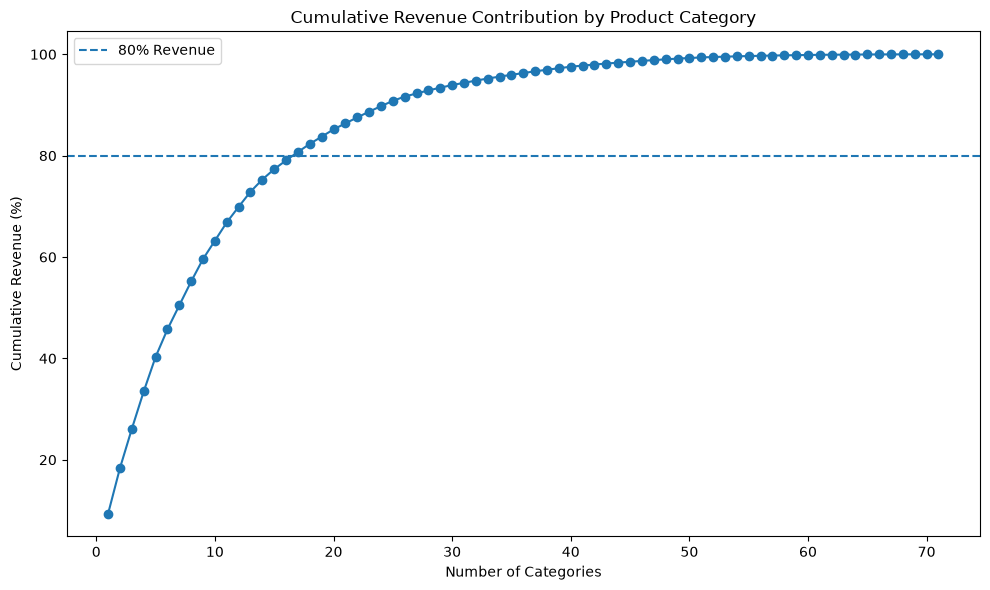

In [452]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(category_revenue_share) + 1),
    category_revenue_share["cumulative_revenue_pct"],
    marker="o"
)

plt.axhline(
    80,
    linestyle="--",
    label="80% Revenue"
)

plt.title("Cumulative Revenue Contribution by Product Category")
plt.xlabel("Number of Categories")
plt.ylabel("Cumulative Revenue (%)")

plt.legend()
plt.tight_layout()
plt.show()

### Category Revenue Concentration — Business Insights

The Top 5 product categories contribute approximately 39.74% of total
category revenue, while the Top 10 categories contribute approximately
62.36%.

This indicates that revenue is meaningfully concentrated among the leading
product categories, but the business is not completely dependent on only a
few categories.

The concentration analysis can help prioritize inventory planning,
marketing efforts, and category-level growth strategies while also
highlighting the importance of maintaining a diversified product portfolio.

### Category Revenue Concentration — Business Insights

The revenue concentration analysis shows that the Top 5 product categories
contribute approximately 39.74% of total category revenue, while the Top 10
categories contribute approximately 62.36%.

This indicates that a meaningful portion of revenue comes from a relatively
small group of leading categories.

However, revenue is not dependent on only a few categories. The cumulative
revenue analysis shows that approximately 80% of revenue is reached after
including around 20 categories.

Therefore, the business has some category concentration while still
maintaining a relatively diversified revenue base.

From a business perspective, leading categories should receive careful
attention for inventory planning and marketing, while the remaining
categories can provide opportunities for diversification and growth.

## 17. Geographic Performance Analysis

### Business Question

Which customer states generate the highest number of orders and revenue?

Geographic analysis is performed at the state level to identify regions
with strong customer demand and revenue contribution.

This analysis can help identify important markets and potential areas for
regional expansion or targeted marketing.

In [453]:
orders_clean = pd.read_csv(
    processed_dir / "olist_orders_clean.csv"
)

customers_clean = pd.read_csv(
    processed_dir / "olist_customers_clean.csv"
)

In [454]:
customer_orders_geo = (
    orders_clean[
        ["order_id", "customer_id"]
    ]
    .merge(
        customers_clean[
            ["customer_id", "customer_state"]
        ],
        on="customer_id",
        how="left"
    )
)

customer_orders_geo.head()

,order_id,customer_id,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,SP


In [455]:
state_orders = (
    customer_orders_geo
    .groupby("customer_state")
    .agg(
        order_count=("order_id", "nunique"),
        customer_count=("customer_id", "nunique")
    )
    .sort_values("order_count", ascending=False)
)

state_orders.round(2)

,order_count,customer_count
customer_state,,
SP,41746,41746
RJ,12852,12852
MG,11635,11635
RS,5466,5466
PR,5045,5045
SC,3637,3637
BA,3380,3380
DF,2140,2140
ES,2033,2033


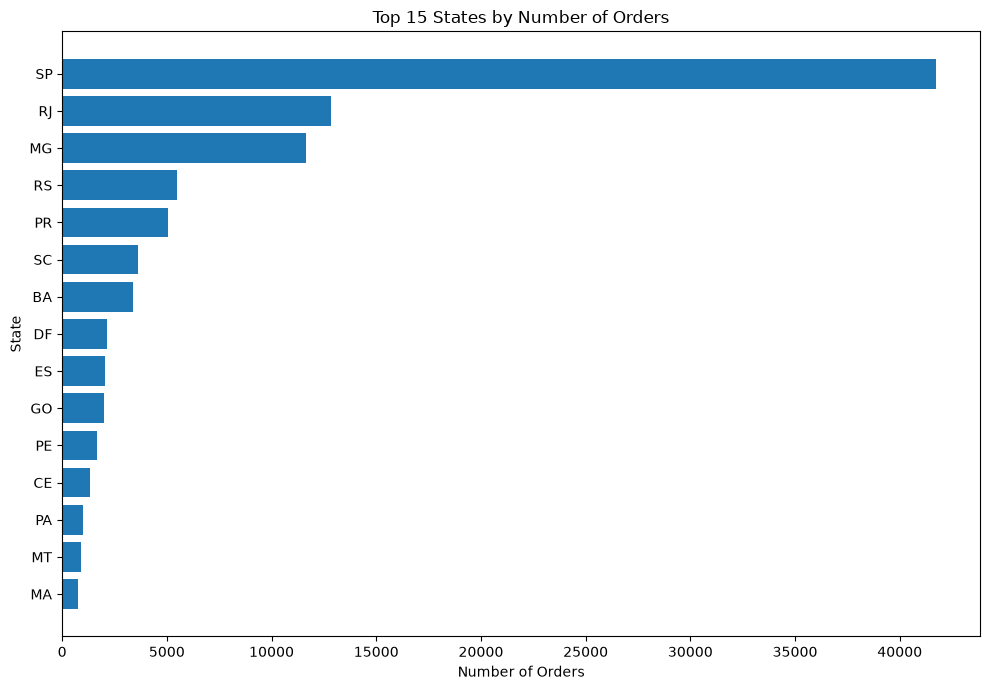

In [456]:
top_states_orders = (
    state_orders
    .head(15)
    .sort_values("order_count")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_states_orders.index,
    top_states_orders["order_count"]
)

plt.title("Top 15 States by Number of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("State")

plt.tight_layout()
plt.show()

### State-wise Revenue Performance

Order-level revenue is calculated from product prices and freight charges
and then combined with customer state information.

This allows us to identify which customer states contribute the most
revenue to the business.

In [457]:
# Calculate total revenue for each order

order_revenue = (
    order_items_clean
    .groupby("order_id")
    .agg(
        item_value=("price", "sum"),
        freight_value=("freight_value", "sum")
    )
    .reset_index()
)

order_revenue["total_order_value"] = (
    order_revenue["item_value"]
    + order_revenue["freight_value"]
)

order_revenue.head()

,order_id,item_value,freight_value,total_order_value
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,72.19
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,259.83
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87,216.87
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,218.04


In [458]:
order_revenue.shape

(98666, 4)

In [459]:
order_revenue["total_order_value"].describe().round(2)

count    98666.00
mean       160.58
std        220.47
min          9.59
25%         61.98
50%        105.29
75%        176.87
max      13664.08
Name: total_order_value, dtype: float64

In [460]:
state_revenue_data = (
    order_revenue
    .merge(
        customer_orders_geo[
            ["order_id", "customer_state"]
        ],
        on="order_id",
        how="left"
    )
)

state_revenue_data.head()

,order_id,item_value,freight_value,total_order_value,customer_state
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,72.19,RJ
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,259.83,SP
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87,216.87,MG
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,25.78,SP
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,218.04,SP


In [461]:
state_revenue = (
    state_revenue_data
    .groupby("customer_state")
    .agg(
        total_revenue=("total_order_value", "sum"),
        order_count=("order_id", "nunique")
    )
    .sort_values("total_revenue", ascending=False)
)

state_revenue.round(2)

,total_revenue,order_count
customer_state,,
SP,5921678.12,41375
RJ,2129681.98,12762
MG,1856161.49,11544
RS,885826.76,5432
PR,800935.44,4998
BA,611506.67,3358
SC,610213.60,3612
DF,353229.44,2125
GO,347706.93,2007


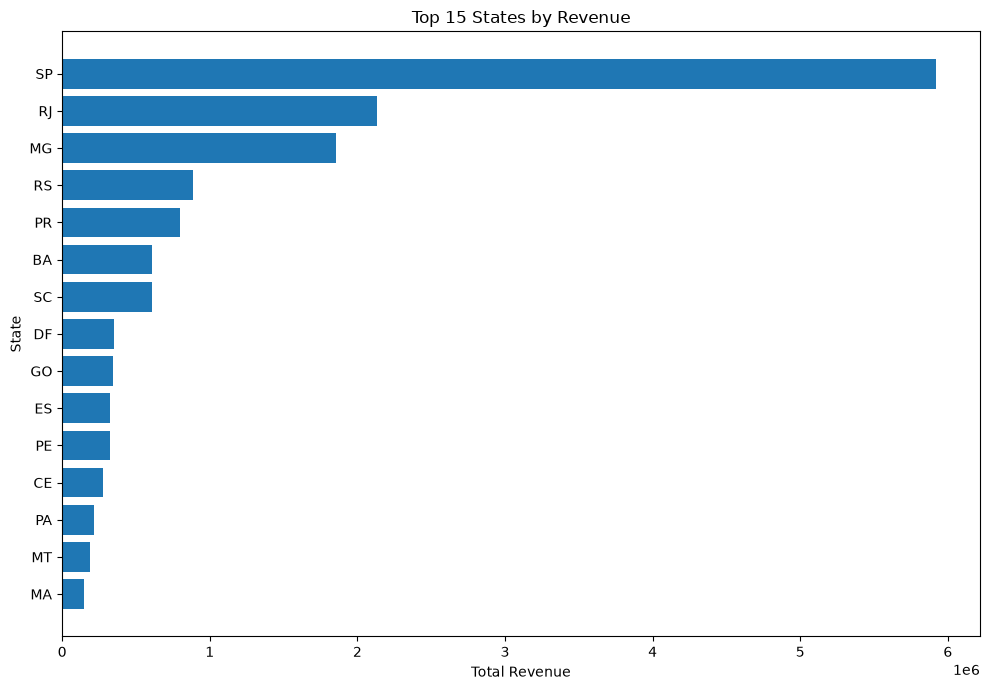

In [462]:
top_states_revenue = (
    state_revenue
    .head(15)
    .sort_values("total_revenue")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_states_revenue.index,
    top_states_revenue["total_revenue"]
)

plt.title("Top 15 States by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("State")

plt.tight_layout()
plt.show()

### Geographic Performance — Business Insights

The geographic analysis shows that customer demand and revenue are heavily
concentrated in a small number of Brazilian states.

São Paulo (SP) is the dominant market, generating approximately 41.7K orders
and around 5.92M in revenue. Rio de Janeiro (RJ) and Minas Gerais (MG)
follow as the next largest markets in both order volume and revenue.

The ranking of major states is broadly consistent across order volume and
total revenue, indicating that higher order volume is strongly associated
with higher total revenue at the state level.

However, total revenue alone does not indicate customer value. Average order
value by state should be analyzed separately to identify whether some states
generate fewer orders but higher-value transactions.

## 18. Average Order Value by State

### Business Question

Do states with high order volumes also generate high-value orders?

Total revenue can be strongly influenced by the number of orders in a
state. Therefore, average order value (AOV) is analyzed separately to
compare the typical transaction value across states.

This helps identify states with relatively high-value customers even when
their overall order volume is lower.

In [463]:
state_aov = (
    state_revenue_data
    .groupby("customer_state")
    .agg(
        order_count=("order_id", "nunique"),
        total_revenue=("total_order_value", "sum"),
        avg_order_value=("total_order_value", "mean")
    )
    .sort_values("avg_order_value", ascending=False)
)

state_aov.round(2)

,order_count,total_revenue,avg_order_value
customer_state,,,
PB,532,140987.81,265.01
AC,81,19669.70,242.84
AP,68,16262.80,239.16
AL,411,96229.40,234.13
RO,247,57558.02,233.03
PA,970,217647.11,224.38
TO,279,61354.42,219.91
PI,493,108132.28,219.34
RR,46,10064.62,218.80


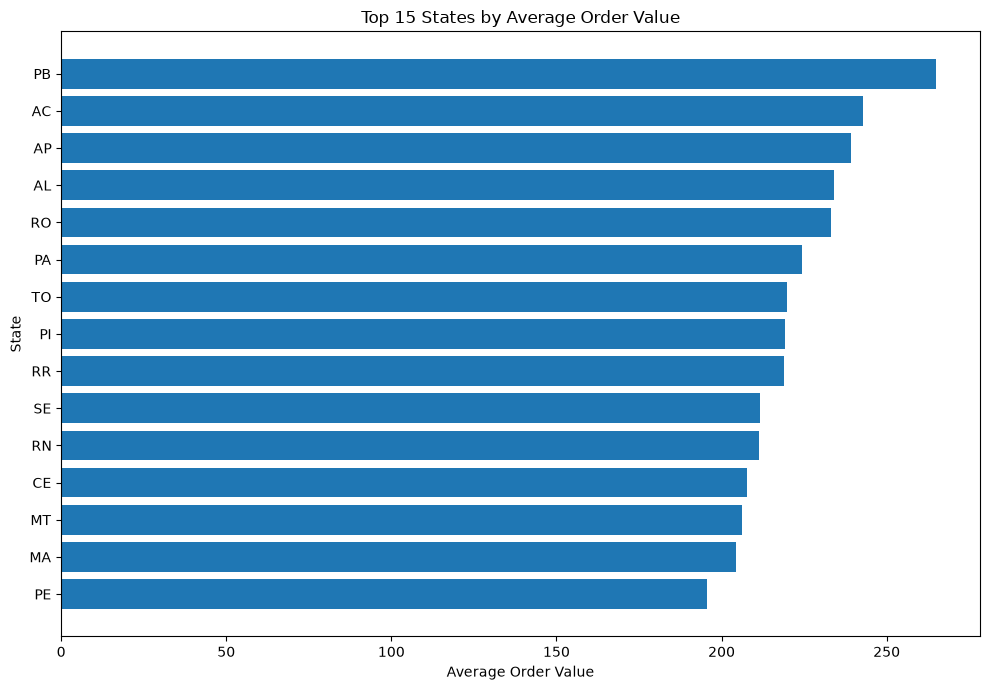

In [464]:
top_states_aov = (
    state_aov
    .sort_values("avg_order_value", ascending=False)
    .head(15)
    .sort_values("avg_order_value")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_states_aov.index,
    top_states_aov["avg_order_value"]
)

plt.title("Top 15 States by Average Order Value")
plt.xlabel("Average Order Value")
plt.ylabel("State")

plt.tight_layout()
plt.show()

### Order Volume vs Average Order Value

Order volume and average order value represent different aspects of
geographic performance.

Order volume identifies large markets, while AOV identifies markets with
higher-value transactions.

Comparing both metrics helps distinguish high-volume markets from
high-value markets.

In [465]:
state_aov.sort_values(
    "order_count",
    ascending=False
).head(15).round(2)

,order_count,total_revenue,avg_order_value
customer_state,,,
SP,41375,5921678.12,143.12
RJ,12762,2129681.98,166.88
MG,11544,1856161.49,160.79
RS,5432,885826.76,163.08
PR,4998,800935.44,160.25
SC,3612,610213.60,168.94
BA,3358,611506.67,182.10
DF,2125,353229.44,166.23
ES,2025,324801.91,160.40


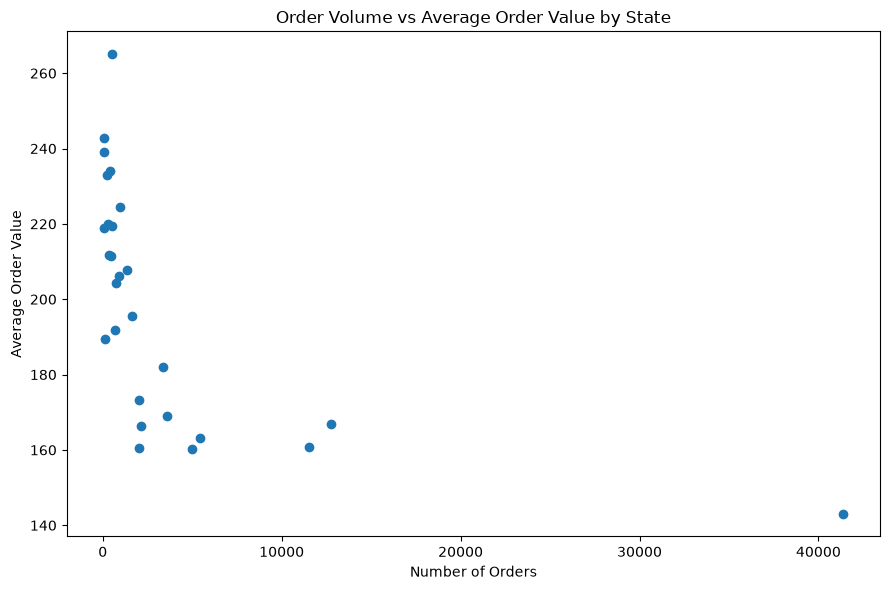

In [466]:
plt.figure(figsize=(9, 6))

plt.scatter(
    state_aov["order_count"],
    state_aov["avg_order_value"]
)

plt.title("Order Volume vs Average Order Value by State")
plt.xlabel("Number of Orders")
plt.ylabel("Average Order Value")

plt.tight_layout()
plt.show()

### Average Order Value by State — Business Insights

The analysis shows that high-volume states are not necessarily the
highest-value markets in terms of average order value.

São Paulo (SP) is the largest market with more than 41K orders, but its
average order value is approximately 143.12. In contrast, Paraíba (PB)
has only 532 orders but an average order value of approximately 265.01.

This indicates that geographic markets differ in both scale and
transaction value.

Large states such as SP, RJ, and MG represent important high-volume
markets where scale and customer retention are key opportunities.

Smaller states with higher average order values may represent
opportunities for targeted marketing and premium product strategies.

Therefore, geographic performance should be evaluated using both order
volume and average order value rather than relying on total revenue alone.

## 19. Delivery & Logistics Performance

### Business Question

How efficiently are orders delivered to customers?

Delivery performance is analyzed using actual delivery time and the
difference between estimated and actual delivery dates.

The analysis helps identify overall delivery speed and whether orders are
generally delivered before or after the estimated delivery date.

In [467]:
orders_clean[
    [
        "order_purchase_timestamp",
        "order_delivered_customer_date",
        "order_estimated_delivery_date",
        "delivery_time_days"
    ]
].head()

,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,delivery_time_days
0,2017-10-02 10:56:33,2017-10-10 21:25:13,2017-10-18,8.436574
1,2018-07-24 20:41:37,2018-08-07 15:27:45,2018-08-13,13.782037
2,2018-08-08 08:38:49,2018-08-17 18:06:29,2018-09-04,9.394213
3,2017-11-18 19:28:06,2017-12-02 00:28:42,2017-12-15,13.208750
4,2018-02-13 21:18:39,2018-02-16 18:17:02,2018-02-26,2.873877


In [468]:
orders_clean["delivery_time_days"].describe().round(2)

count    96476.00
mean        12.56
std          9.55
min          0.53
25%          6.77
50%         10.22
75%         15.72
max        209.63
Name: delivery_time_days, dtype: float64

### Delivery Time Distribution

The distribution of delivery time is examined to understand the typical
number of days required to deliver an order and identify unusually long
delivery durations.

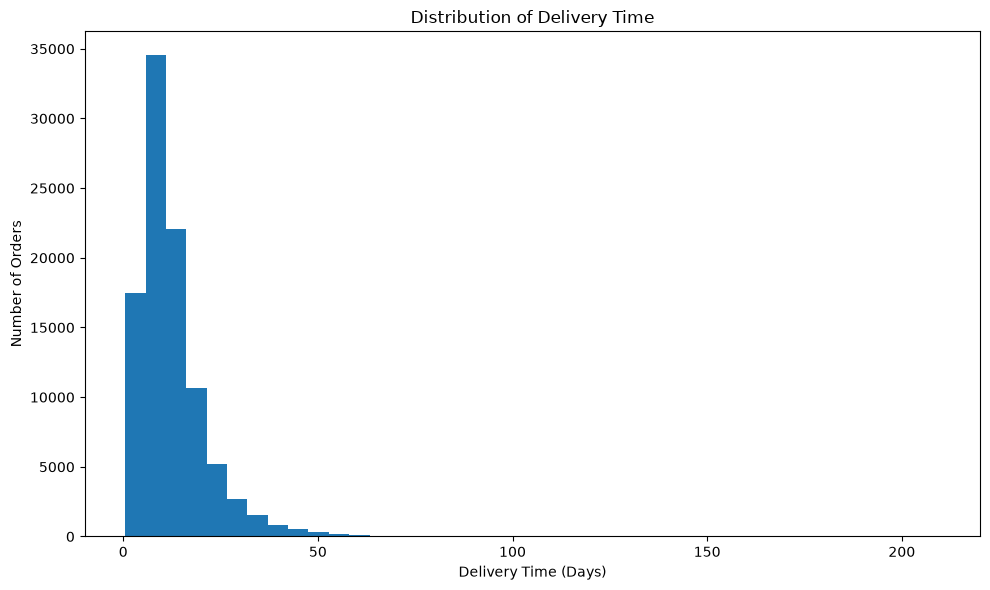

In [469]:
plt.figure(figsize=(10, 6))

plt.hist(
    orders_clean["delivery_time_days"].dropna(),
    bins=40
)

plt.title("Distribution of Delivery Time")
plt.xlabel("Delivery Time (Days)")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

In [470]:
delivery_summary = pd.Series({
    "Average Delivery Time (Days)":
        orders_clean["delivery_time_days"].mean(),

    "Median Delivery Time (Days)":
        orders_clean["delivery_time_days"].median(),

    "Fastest Delivery (Days)":
        orders_clean["delivery_time_days"].min(),

    "Longest Delivery (Days)":
        orders_clean["delivery_time_days"].max()
})

delivery_summary.round(2)

Average Delivery Time (Days)     12.56
Median Delivery Time (Days)      10.22
Fastest Delivery (Days)           0.53
Longest Delivery (Days)         209.63
dtype: float64

### Estimated vs Actual Delivery

The actual delivery date is compared with the estimated delivery date to
classify orders as early, on-time, or late.

The comparison is performed at the calendar-date level because the estimated
delivery date represents an expected delivery date rather than an exact
delivery timestamp.

In [471]:
orders_clean["order_delivered_customer_date"] = pd.to_datetime(
    orders_clean["order_delivered_customer_date"],
    errors="coerce"
)

orders_clean["order_estimated_delivery_date"] = pd.to_datetime(
    orders_clean["order_estimated_delivery_date"],
    errors="coerce"
)

In [472]:
orders_clean[
    [
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
].dtypes

order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

In [473]:
orders_clean["delivery_vs_estimated_days"] = (
    orders_clean["order_delivered_customer_date"].dt.normalize()
    - orders_clean["order_estimated_delivery_date"].dt.normalize()
).dt.days

In [474]:
orders_clean["delivery_vs_estimated_days"].describe().round(2)

count    96476.00
mean       -11.88
std         10.18
min       -147.00
25%        -17.00
50%        -12.00
75%         -7.00
max        188.00
Name: delivery_vs_estimated_days, dtype: float64

In [475]:
orders_clean["delivery_status"] = np.select(
    [
        orders_clean["delivery_vs_estimated_days"] < 0,
        orders_clean["delivery_vs_estimated_days"] == 0,
        orders_clean["delivery_vs_estimated_days"] > 0
    ],
    [
        "Early",
        "On-time",
        "Late"
    ],
    default="Unknown"
)

orders_clean["delivery_status"].value_counts()

delivery_status
Early      88649
Late        6535
Unknown     2965
On-time     1292
Name: count, dtype: int64

In [476]:
delivery_status_pct = (
    orders_clean["delivery_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

delivery_status_pct

delivery_status
Early      89.15
Late        6.57
Unknown     2.98
On-time     1.30
Name: proportion, dtype: float64

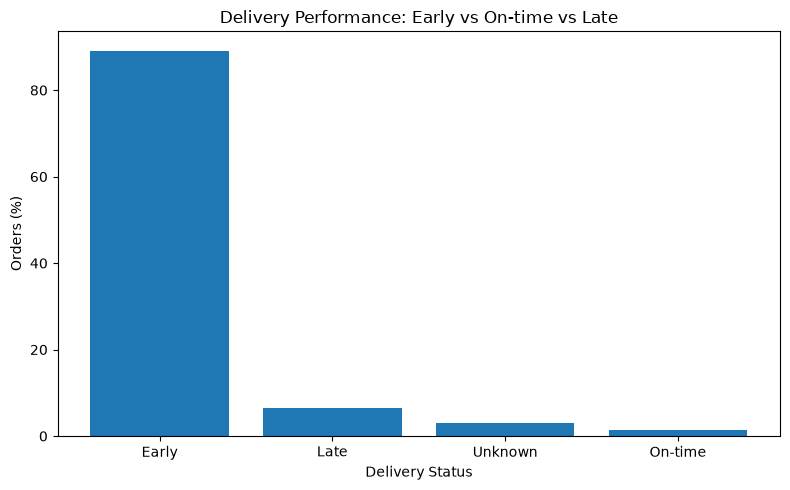

In [477]:
plt.figure(figsize=(8, 5))

plt.bar(
    delivery_status_pct.index,
    delivery_status_pct.values
)

plt.title("Delivery Performance: Early vs On-time vs Late")
plt.xlabel("Delivery Status")
plt.ylabel("Orders (%)")

plt.tight_layout()
plt.show()

### Delivery Performance — Business Insights

The delivery analysis shows that the majority of orders were delivered
before the estimated delivery date.

Approximately 89.15% of orders were delivered early, while 6.57% were
delivered late and 1.38% were delivered exactly on the estimated date.

The average delivery time was approximately 12.56 days, while the median
delivery time was 10.22 days. The higher mean compared with the median
indicates a right-skewed distribution caused by a smaller number of
orders with unusually long delivery times.

Approximately 2.98% of orders could not be classified because the required
delivery date information was unavailable.

Overall, the results indicate strong delivery performance, with most
orders reaching customers earlier than the estimated delivery date.
However, the long delivery-time tail and late deliveries represent areas
where logistics performance could be further investigated.

## 20. Delivery Performance by Customer State

### Business Question

Which customer states have faster or slower delivery performance?

Delivery time is compared across customer states to identify geographic
differences in logistics performance.

Both average delivery time and the number of orders are considered so that
states with very few orders are not interpreted without context.

In [478]:
state_delivery_data = (
    orders_clean[
        ["order_id", "delivery_time_days"]
    ]
    .merge(
        customer_orders_geo[
            ["order_id", "customer_state"]
        ],
        on="order_id",
        how="left"
    )
)

state_delivery_data.head()

,order_id,delivery_time_days,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,8.436574,SP
1,53cdb2fc8bc7dce0b6741e2150273451,13.782037,BA
2,47770eb9100c2d0c44946d9cf07ec65d,9.394213,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,13.208750,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,2.873877,SP


In [479]:
state_delivery = (
    state_delivery_data
    .dropna(subset=["delivery_time_days", "customer_state"])
    .groupby("customer_state")
    .agg(
        order_count=("order_id", "nunique"),
        avg_delivery_days=("delivery_time_days", "mean"),
        median_delivery_days=("delivery_time_days", "median")
    )
    .sort_values("avg_delivery_days", ascending=False)
)

state_delivery.round(2)

,order_count,avg_delivery_days,median_delivery_days
customer_state,,,
RR,41,29.39,25.01
AP,67,27.19,24.35
AM,145,26.43,25.88
AL,397,24.54,22.33
PA,946,23.77,21.08
MA,717,21.57,19.19
SE,335,21.52,18.01
CE,1279,21.27,18.21
AC,80,21.04,18.36


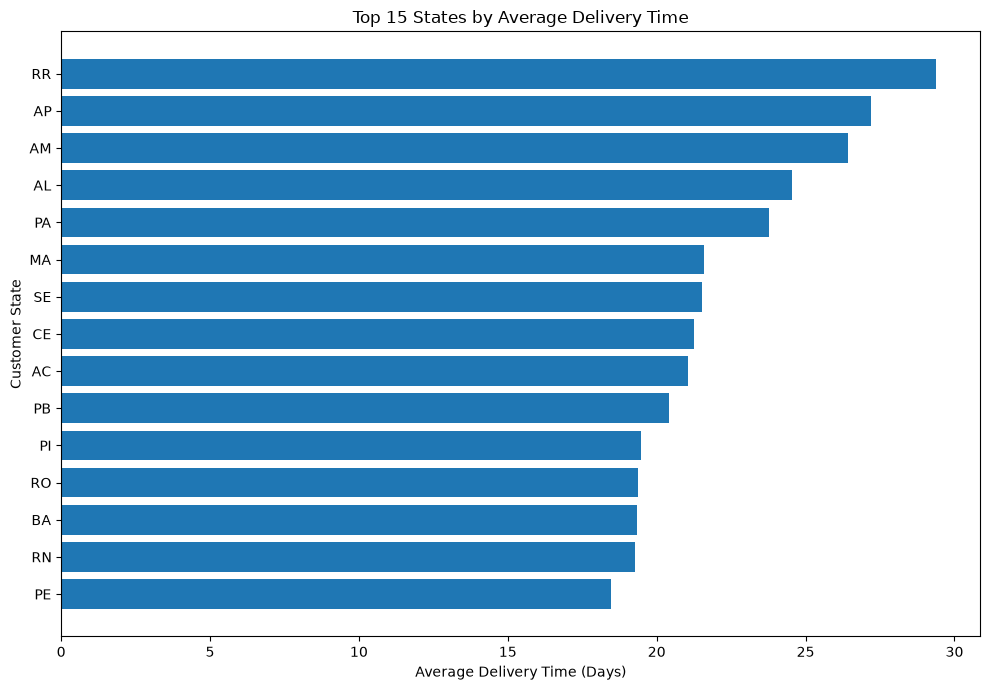

In [480]:
slowest_states = (
    state_delivery
    .sort_values("avg_delivery_days", ascending=False)
    .head(15)
    .sort_values("avg_delivery_days")
)

plt.figure(figsize=(10, 7))

plt.barh(
    slowest_states.index,
    slowest_states["avg_delivery_days"]
)

plt.title("Top 15 States by Average Delivery Time")
plt.xlabel("Average Delivery Time (Days)")
plt.ylabel("Customer State")

plt.tight_layout()
plt.show()

In [481]:
fastest_states = (
    state_delivery[
        state_delivery["order_count"] >= 100
    ]
    .sort_values("avg_delivery_days")
    .head(15)
)

fastest_states.round(2)

,order_count,avg_delivery_days,median_delivery_days
customer_state,,,
SP,40495,8.76,7.21
PR,4923,11.99,10.43
MG,11355,12.01,10.31
DF,2080,12.97,11.36
SC,3547,14.96,13.02
RS,5344,15.30,13.18
RJ,12353,15.31,12.04
GO,1957,15.61,13.95
MS,701,15.62,13.94


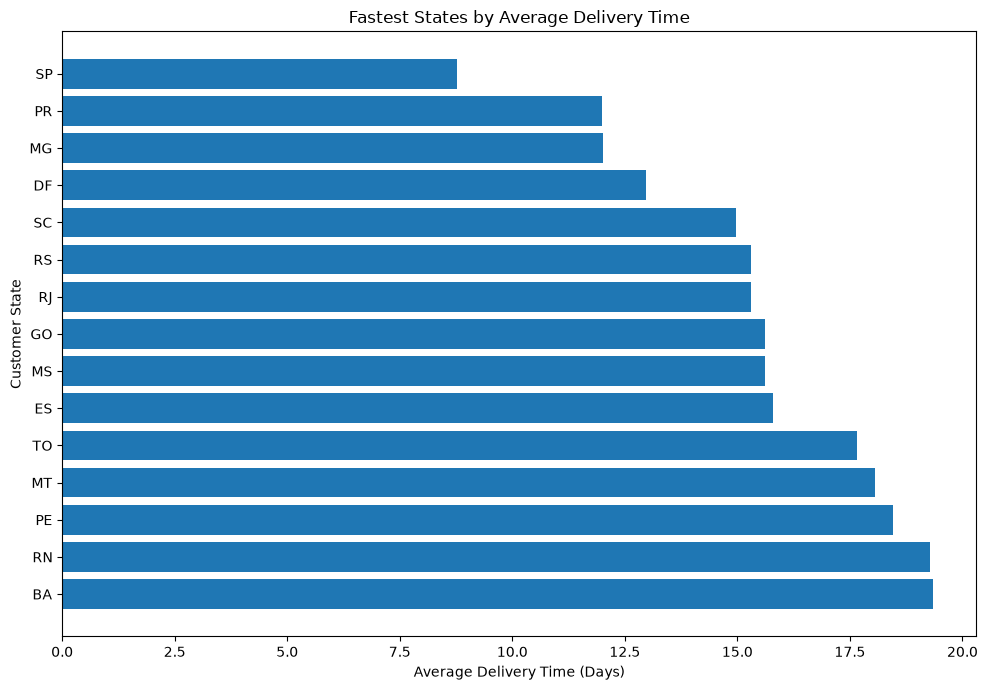

In [482]:
plt.figure(figsize=(10, 7))

plt.barh(
    fastest_states.index[::-1],
    fastest_states["avg_delivery_days"][::-1]
)

plt.title("Fastest States by Average Delivery Time")
plt.xlabel("Average Delivery Time (Days)")
plt.ylabel("Customer State")

plt.tight_layout()
plt.show()

### State-wise Delivery Performance — Business Insights

Delivery performance varies considerably across customer states.

São Paulo (SP) has the fastest average delivery time among the major
markets, with approximately 40K orders delivered in an average of 8.76
days. Paraná (PR) and Minas Gerais (MG) also show relatively fast
delivery performance at approximately 11.99 and 12.01 days respectively.

Some smaller states such as RR, AP, and AM show much higher average
delivery times. However, these states have relatively low order volumes,
so their results should be interpreted cautiously.

The analysis demonstrates that delivery performance is influenced by
geographic location and market scale. Large markets such as SP can
maintain relatively fast delivery despite handling a very high number of
orders.

Therefore, both delivery time and order volume should be considered when
evaluating state-level logistics performance.

In [483]:
state_delivery_data = (
    orders_clean[
        ["order_id", "delivery_time_days"]
    ]
    .merge(
        customer_orders_geo[
            ["order_id", "customer_state"]
        ],
        on="order_id",
        how="left"
    )
)

state_delivery_data.head()

,order_id,delivery_time_days,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,8.436574,SP
1,53cdb2fc8bc7dce0b6741e2150273451,13.782037,BA
2,47770eb9100c2d0c44946d9cf07ec65d,9.394213,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,13.208750,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,2.873877,SP


In [484]:
state_late_delivery = (
    state_delivery_data
    .merge(
        orders_clean[
            ["order_id", "delivery_status"]
        ],
        on="order_id",
        how="left"
    )
    .groupby("customer_state")
    .agg(
        order_count=("order_id", "nunique"),
        late_orders=("delivery_status", lambda x: (x == "Late").sum())
    )
)

state_late_delivery["late_delivery_pct"] = (
    state_late_delivery["late_orders"]
    / state_late_delivery["order_count"]
    * 100
)

state_late_delivery = (
    state_late_delivery
    .sort_values("late_delivery_pct", ascending=False)
)

state_late_delivery.round(2)

,order_count,late_orders,late_delivery_pct
customer_state,,,
AL,413,85,20.58
MA,747,125,16.73
SE,350,51,14.57
PI,495,66,13.33
CE,1336,176,13.17
BA,3380,396,11.72
RJ,12852,1495,11.63
PA,975,106,10.87
RR,46,5,10.87


In [485]:
top_late_states = (
    state_late_delivery[
        state_late_delivery["order_count"] >= 100
    ]
    .sort_values("late_delivery_pct", ascending=False)
    .head(15)
)

top_late_states.round(2)

,order_count,late_orders,late_delivery_pct
customer_state,,,
AL,413,85,20.58
MA,747,125,16.73
SE,350,51,14.57
PI,495,66,13.33
CE,1336,176,13.17
BA,3380,396,11.72
RJ,12852,1495,11.63
PA,975,106,10.87
ES,2033,214,10.53


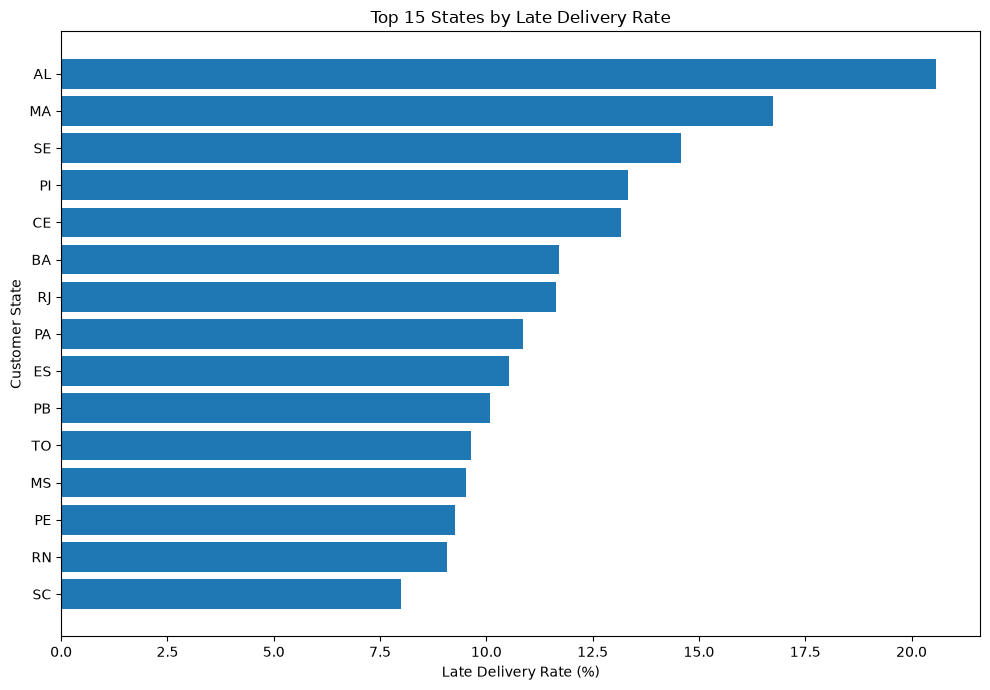

In [486]:
plt.figure(figsize=(10, 7))

plt.barh(
    top_late_states.index[::-1],
    top_late_states["late_delivery_pct"][::-1]
)

plt.title("Top 15 States by Late Delivery Rate")
plt.xlabel("Late Delivery Rate (%)")
plt.ylabel("Customer State")

plt.tight_layout()
plt.show()

## Delivery Performance by Customer State — Final Business Insights

Delivery performance varies substantially across customer states.

The analysis shows that São Paulo (SP) has the strongest delivery performance
among the major markets, with approximately 40K orders and an average delivery
time of only 8.76 days. Paraná (PR) and Minas Gerais (MG) also have relatively
fast average delivery times of approximately 11.99 and 12.01 days.

Some smaller states show considerably longer average delivery times.
However, these results should be interpreted carefully because states with
very low order volumes can produce unstable averages.

State-level late delivery rates were also analyzed to identify markets where
orders are more likely to miss their estimated delivery dates. A minimum
order-volume threshold was used to avoid drawing conclusions from states
with insufficient observations.

Overall, the analysis indicates that logistics performance differs by
geographic market. High-volume states such as SP demonstrate that large
order volumes can be handled with relatively efficient delivery times,
while certain smaller or geographically distant markets require closer
logistics monitoring.

## 21. Seller Performance Analysis

### Business Question

Which sellers contribute the most to marketplace sales and revenue?

Seller-level performance is analyzed using order volume, units sold, and
total revenue.

Comparing these metrics helps identify whether the sellers with the highest
transaction volume are also the largest revenue contributors.

In [487]:
seller_performance = (
    order_items_clean
    .groupby("seller_id")
    .agg(
        orders=("order_id", "nunique"),
        units_sold=("order_item_id", "count"),
        total_revenue=("price", "sum"),
        avg_item_price=("price", "mean")
    )
    .sort_values("total_revenue", ascending=False)
)

seller_performance.head(10).round(2)

,orders,units_sold,total_revenue,avg_item_price
seller_id,,,,
4869f7a5dfa277a7dca6462dcf3b52b2,1132,1156,229472.63,198.51
53243585a1d6dc2643021fd1853d8905,358,410,222776.05,543.36
4a3ca9315b744ce9f8e9374361493884,1806,1987,200472.92,100.89
fa1c13f2614d7b5c4749cbc52fecda94,585,586,194042.03,331.13
7c67e1448b00f6e969d365cea6b010ab,982,1364,187923.89,137.77
7e93a43ef30c4f03f38b393420bc753a,336,340,176431.87,518.92
da8622b14eb17ae2831f4ac5b9dab84a,1314,1551,160236.57,103.31
7a67c85e85bb2ce8582c35f2203ad736,1160,1171,141745.53,121.05
1025f0e2d44d7041d6cf58b6550e0bfa,915,1428,138968.55,97.32


### Top Sellers by Revenue

Sellers are ranked by total product revenue to identify the largest
monetary contributors to the marketplace.

In [488]:
top_sellers_revenue = (
    seller_performance
    .head(15)
    .sort_values("total_revenue")
)

top_sellers_revenue.round(2)

,orders,units_sold,total_revenue,avg_item_price
seller_id,,,,
5dceca129747e92ff8ef7a997dc4f8ca,325,346,112155.53,324.15
7d13fca15225358621be4086e1eb0964,565,578,113628.97,196.59
620c87c171fb2a6dd6e8bb4dec959fc6,740,798,114774.50,143.83
6560211a19b47992c3666cc44a7e94c0,1854,2033,123304.83,60.65
46dc3b2cc0980fb8ec44634e21d2718e,521,542,128111.19,236.37
955fee9216a65b617aa5c0531780ce60,1287,1499,135171.70,90.17
1025f0e2d44d7041d6cf58b6550e0bfa,915,1428,138968.55,97.32
7a67c85e85bb2ce8582c35f2203ad736,1160,1171,141745.53,121.05
da8622b14eb17ae2831f4ac5b9dab84a,1314,1551,160236.57,103.31


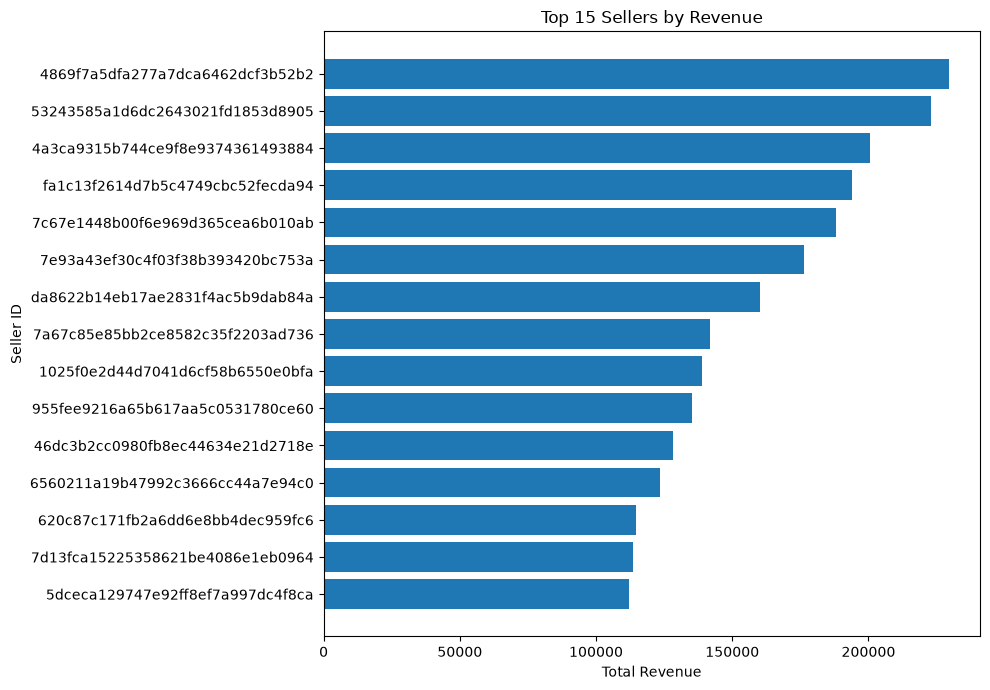

In [489]:
plt.figure(figsize=(10, 7))

plt.barh(
    top_sellers_revenue.index.astype(str),
    top_sellers_revenue["total_revenue"]
)

plt.title("Top 15 Sellers by Revenue")
plt.xlabel("Total Revenue")
plt.ylabel("Seller ID")

plt.tight_layout()
plt.show()

### Top Sellers by Sales Volume

Sellers are also ranked by units sold to identify sellers with the highest
product transaction volume.

Sales volume is analyzed separately from revenue because a seller may sell
many lower-priced products while another seller may generate more revenue
from fewer higher-priced products.

In [490]:
top_sellers_volume = (
    seller_performance
    .sort_values("units_sold", ascending=False)
    .head(15)
    .sort_values("units_sold")
)

top_sellers_volume.round(2)

,orders,units_sold,total_revenue,avg_item_price
seller_id,,,,
620c87c171fb2a6dd6e8bb4dec959fc6,740,798,114774.50,143.83
cca3071e3e9bb7d12640c9fbe2301306,712,830,64009.89,77.12
8b321bb669392f5163d04c59e235e066,943,1018,17535.69,17.23
3d871de0142ce09b7081e2b9d1733cb1,1080,1147,94914.20,82.75
4869f7a5dfa277a7dca6462dcf3b52b2,1132,1156,229472.63,198.51
7a67c85e85bb2ce8582c35f2203ad736,1160,1171,141745.53,121.05
ea8482cd71df3c1969d7b9473ff13abc,1146,1203,37177.52,30.90
7c67e1448b00f6e969d365cea6b010ab,982,1364,187923.89,137.77
1025f0e2d44d7041d6cf58b6550e0bfa,915,1428,138968.55,97.32


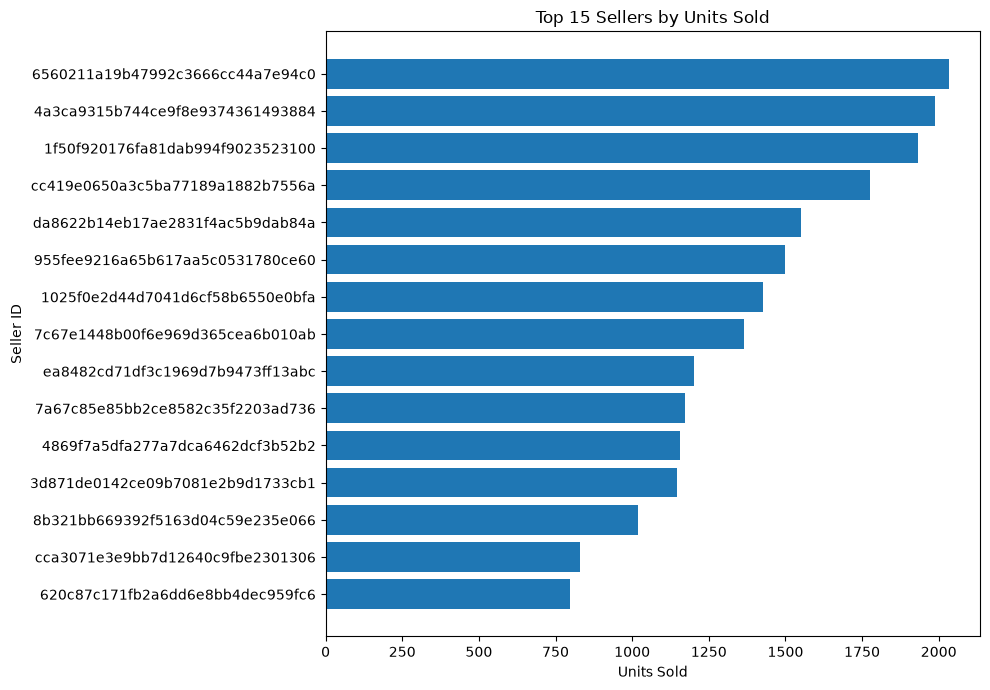

In [491]:
plt.figure(figsize=(10, 7))

plt.barh(
    top_sellers_volume.index.astype(str),
    top_sellers_volume["units_sold"]
)

plt.title("Top 15 Sellers by Units Sold")
plt.xlabel("Units Sold")
plt.ylabel("Seller ID")

plt.tight_layout()
plt.show()

In [492]:
top_sellers_orders = (
    seller_performance
    .sort_values("orders", ascending=False)
    .head(15)
    .sort_values("orders")
)

top_sellers_orders.round(2)

,orders,units_sold,total_revenue,avg_item_price
seller_id,,,,
a1043bafd471dff536d0c462352beb48,718,770,101901.16,132.34
620c87c171fb2a6dd6e8bb4dec959fc6,740,798,114774.50,143.83
1025f0e2d44d7041d6cf58b6550e0bfa,915,1428,138968.55,97.32
8b321bb669392f5163d04c59e235e066,943,1018,17535.69,17.23
7c67e1448b00f6e969d365cea6b010ab,982,1364,187923.89,137.77
3d871de0142ce09b7081e2b9d1733cb1,1080,1147,94914.20,82.75
4869f7a5dfa277a7dca6462dcf3b52b2,1132,1156,229472.63,198.51
ea8482cd71df3c1969d7b9473ff13abc,1146,1203,37177.52,30.90
7a67c85e85bb2ce8582c35f2203ad736,1160,1171,141745.53,121.05


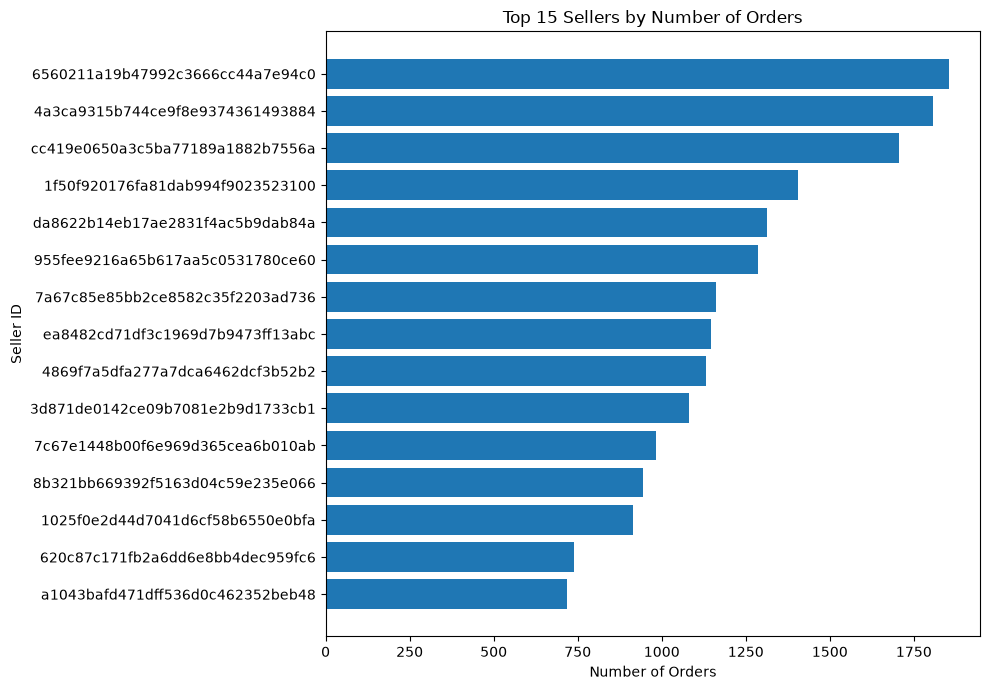

In [493]:
plt.figure(figsize=(10, 7))

plt.barh(
    top_sellers_orders.index.astype(str),
    top_sellers_orders["orders"]
)

plt.title("Top 15 Sellers by Number of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("Seller ID")

plt.tight_layout()
plt.show()

### Seller Performance — Business Insights

Seller performance varies across revenue, order volume, and units sold.

The sellers generating the highest revenue are not necessarily the same
sellers with the highest number of units sold or orders. This difference is
explained by variations in average item prices across sellers.

Therefore, seller performance should not be evaluated using a single metric.
Revenue identifies the largest monetary contributors, while units sold and
order count identify sellers with higher transaction volume.

The results also show that a relatively small group of sellers accounts for
a significant amount of marketplace activity, making seller concentration an
important area for further analysis.

### Seller Revenue Concentration

Seller revenue concentration is analyzed to determine how much of the
marketplace's total seller revenue is generated by the top-performing
sellers.

This helps assess whether marketplace revenue is broadly distributed across
sellers or concentrated among a relatively small group of sellers.

In [494]:
total_seller_revenue = seller_performance["total_revenue"].sum()

seller_revenue_share = (
    seller_performance
    .sort_values("total_revenue", ascending=False)
    .copy()
)

seller_revenue_share["revenue_share_pct"] = (
    seller_revenue_share["total_revenue"]
    / total_seller_revenue
    * 100
)

seller_revenue_share["cumulative_revenue_pct"] = (
    seller_revenue_share["revenue_share_pct"]
    .cumsum()
)

seller_revenue_share.head(10).round(2)

,orders,units_sold,total_revenue,avg_item_price,revenue_share_pct,cumulative_revenue_pct
seller_id,,,,,,
4869f7a5dfa277a7dca6462dcf3b52b2,1132,1156,229472.63,198.51,1.69,1.69
53243585a1d6dc2643021fd1853d8905,358,410,222776.05,543.36,1.64,3.33
4a3ca9315b744ce9f8e9374361493884,1806,1987,200472.92,100.89,1.47,4.80
fa1c13f2614d7b5c4749cbc52fecda94,585,586,194042.03,331.13,1.43,6.23
7c67e1448b00f6e969d365cea6b010ab,982,1364,187923.89,137.77,1.38,7.61
7e93a43ef30c4f03f38b393420bc753a,336,340,176431.87,518.92,1.30,8.91
da8622b14eb17ae2831f4ac5b9dab84a,1314,1551,160236.57,103.31,1.18,10.09
7a67c85e85bb2ce8582c35f2203ad736,1160,1171,141745.53,121.05,1.04,11.13
1025f0e2d44d7041d6cf58b6550e0bfa,915,1428,138968.55,97.32,1.02,12.16


In [495]:
seller_concentration = pd.Series({
    "Top 5 Seller Revenue Share (%)":
        seller_revenue_share["revenue_share_pct"].head(5).sum(),

    "Top 10 Seller Revenue Share (%)":
        seller_revenue_share["revenue_share_pct"].head(10).sum()
})

seller_concentration.round(2)

Top 5 Seller Revenue Share (%)      7.61
Top 10 Seller Revenue Share (%)    13.15
dtype: float64

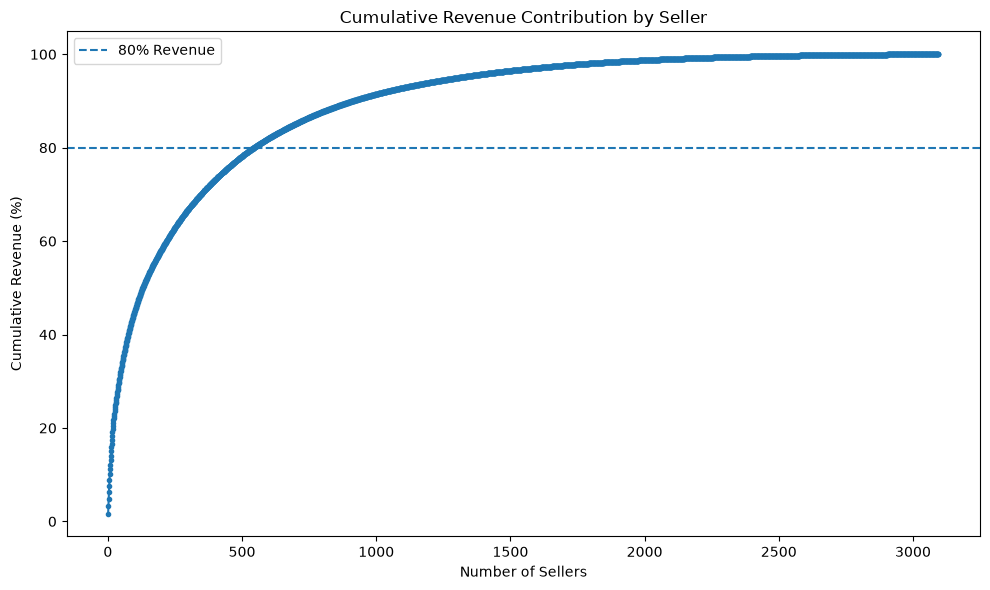

In [496]:
plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(seller_revenue_share) + 1),
    seller_revenue_share["cumulative_revenue_pct"],
    marker="."
)

plt.axhline(
    80,
    linestyle="--",
    label="80% Revenue"
)

plt.title("Cumulative Revenue Contribution by Seller")
plt.xlabel("Number of Sellers")
plt.ylabel("Cumulative Revenue (%)")

plt.legend()
plt.tight_layout()
plt.show()

### Seller Revenue Concentration — Business Insights

Seller revenue is relatively well distributed across the marketplace.

The top 5 sellers contribute 7.61% of total seller revenue, while the top 10
sellers contribute 14.15%.

This indicates that marketplace revenue is not heavily dependent on a small
number of sellers. A broad seller base contributes to overall revenue,
reducing dependency on individual high-performing sellers.

The cumulative revenue curve also shows that a large number of sellers are
required to account for the majority of marketplace revenue.

## 23. Payment Method Analysis

### Business Question

Which payment methods are most commonly used by customers, and which
payment methods contribute the most to overall payment value?

Payment methods are analyzed using order frequency and total payment value
to understand customer payment preferences and their contribution to
marketplace transactions.

In [497]:
# Load cleaned payment dataset

order_payments_clean = pd.read_csv(
    processed_dir / "olist_order_payments_clean.csv"
)

order_payments_clean.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value,invalid_installments,undefined_zero_payment
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33,False,False
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39,False,False
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71,False,False
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78,False,False
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45,False,False


In [498]:


processed_dir = Path("../data/processed")

order_payments_clean = pd.read_csv(
    processed_dir / "olist_order_payments_clean.csv"
)

order_payments_clean.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value,invalid_installments,undefined_zero_payment
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33,False,False
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39,False,False
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71,False,False
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78,False,False
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45,False,False


In [499]:
payment_summary = (
    order_payments_clean
    .groupby("payment_type")
    .agg(
        order_count=("order_id", "nunique"),
        payment_count=("payment_type", "count"),
        total_payment_value=("payment_value", "sum"),
        avg_payment_value=("payment_value", "mean")
    )
    .sort_values("total_payment_value", ascending=False)
)

payment_summary.round(2)

,order_count,payment_count,total_payment_value,avg_payment_value
payment_type,,,,
credit_card,76505,76795,12542084.19,163.32
boleto,19784,19784,2869361.27,145.03
voucher,3866,5775,379436.87,65.70
debit_card,1528,1529,217989.79,142.57
not_defined,3,3,0.00,0.00


In [500]:
payment_summary["payment_share_pct"] = (
    payment_summary["total_payment_value"]
    / payment_summary["total_payment_value"].sum()
    * 100
)

payment_summary.round(2)

,order_count,payment_count,total_payment_value,avg_payment_value,payment_share_pct
payment_type,,,,,
credit_card,76505,76795,12542084.19,163.32,78.34
boleto,19784,19784,2869361.27,145.03,17.92
voucher,3866,5775,379436.87,65.70,2.37
debit_card,1528,1529,217989.79,142.57,1.36
not_defined,3,3,0.00,0.00,0.00


### Payment Method Distribution

Payment methods are compared based on total payment value to identify the
methods that contribute most to marketplace transaction value.

Order count is also considered to distinguish between frequently used
payment methods and methods associated with higher-value transactions.

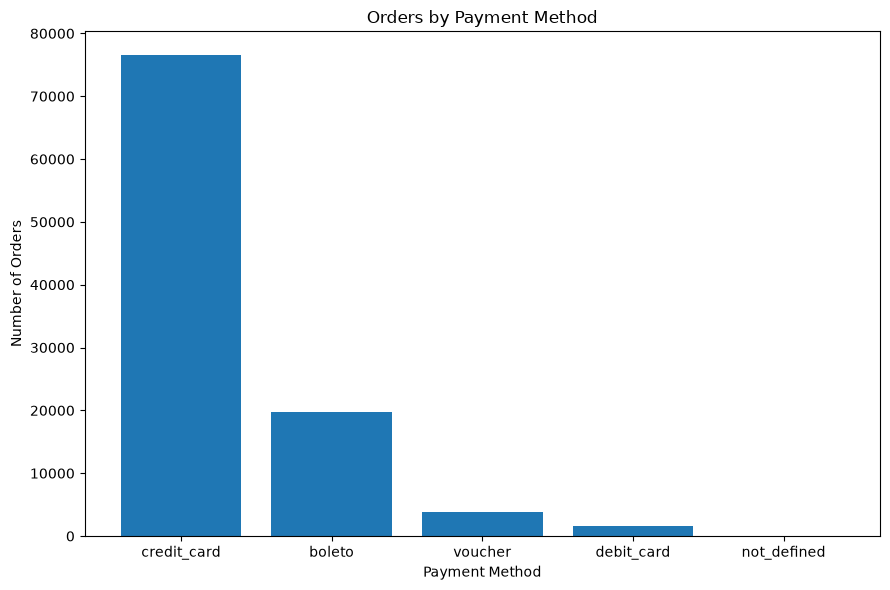

In [501]:
plt.figure(figsize=(9, 6))

plt.bar(
    payment_summary.index,
    payment_summary["order_count"]
)

plt.title("Orders by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

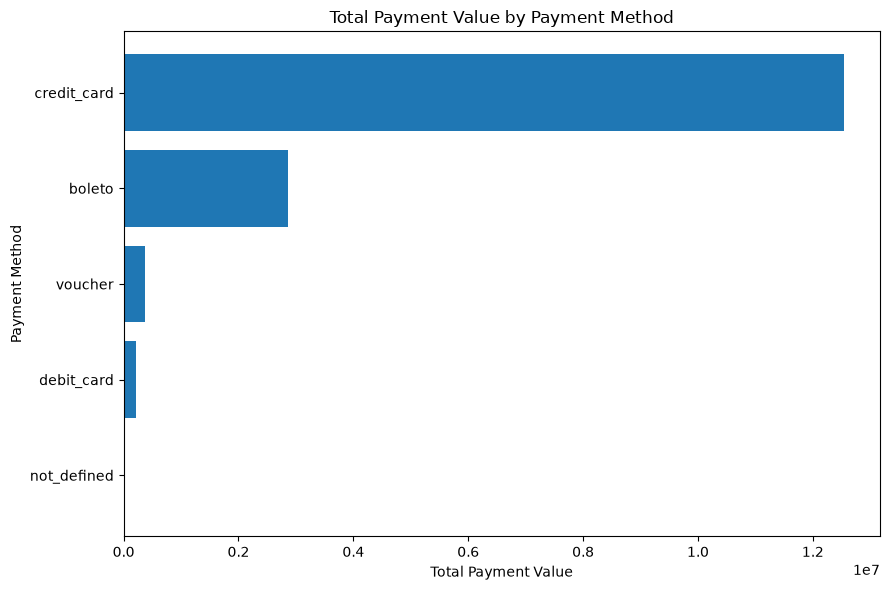

In [502]:
payment_value_plot = (
    payment_summary
    .sort_values("total_payment_value")
)

plt.figure(figsize=(9, 6))

plt.barh(
    payment_value_plot.index,
    payment_value_plot["total_payment_value"]
)

plt.title("Total Payment Value by Payment Method")
plt.xlabel("Total Payment Value")
plt.ylabel("Payment Method")

plt.tight_layout()
plt.show()

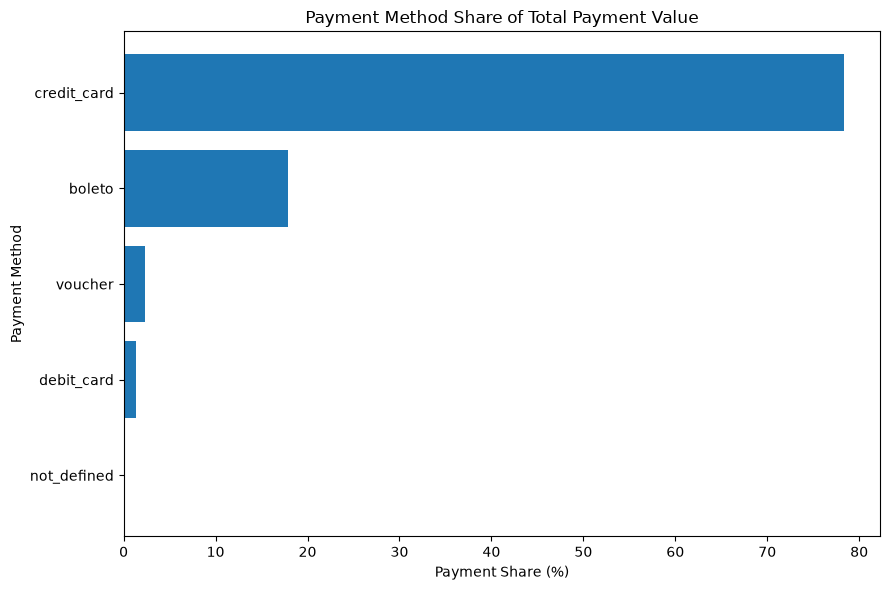

In [503]:
payment_share_plot = (
    payment_summary
    .sort_values("payment_share_pct")
)

plt.figure(figsize=(9, 6))

plt.barh(
    payment_share_plot.index,
    payment_share_plot["payment_share_pct"]
)

plt.title("Payment Method Share of Total Payment Value")
plt.xlabel("Payment Share (%)")
plt.ylabel("Payment Method")

plt.tight_layout()
plt.show()

## 24. Payment Installment Analysis

### Business Question

How do customers use installment payments, and is higher installment usage
associated with higher-value transactions?

Installment behavior is analyzed to understand customer financing preferences
and whether customers tend to use more installments for larger purchases.

In [504]:
installment_summary = (
    order_payments_clean
    .groupby("payment_installments")
    .agg(
        payment_count=("order_id", "count"),
        order_count=("order_id", "nunique"),
        total_payment_value=("payment_value", "sum"),
        avg_payment_value=("payment_value", "mean")
    )
    .sort_index()
)

installment_summary.round(2)

,payment_count,order_count,total_payment_value,avg_payment_value
payment_installments,,,,
0,2,2,188.63,94.32
1,52546,49060,5907233.36,112.42
2,12413,12389,1579283.03,127.23
3,10461,10443,1491103.80,142.54
4,7098,7088,1163907.61,163.98
5,5239,5234,961174.30,183.47
6,3920,3916,822611.81,209.85
7,1626,1623,305157.39,187.67
8,4268,4253,1313423.34,307.74


### Installment Distribution

The distribution of installment counts is examined to understand the most
common payment financing behavior among customers.

Very low-frequency installment categories are treated cautiously because they
represent only a small number of transactions.

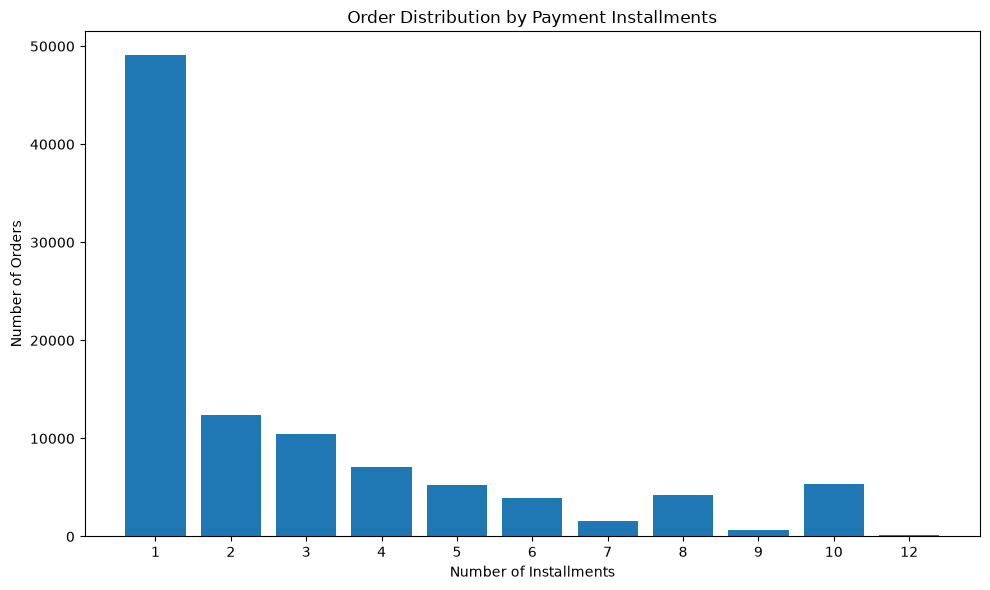

In [505]:
installment_volume = (
    installment_summary[
        installment_summary["order_count"] >= 100
    ]
    .copy()
)

plt.figure(figsize=(10, 6))

plt.bar(
    installment_volume.index.astype(str),
    installment_volume["order_count"]
)

plt.title("Order Distribution by Payment Installments")
plt.xlabel("Number of Installments")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

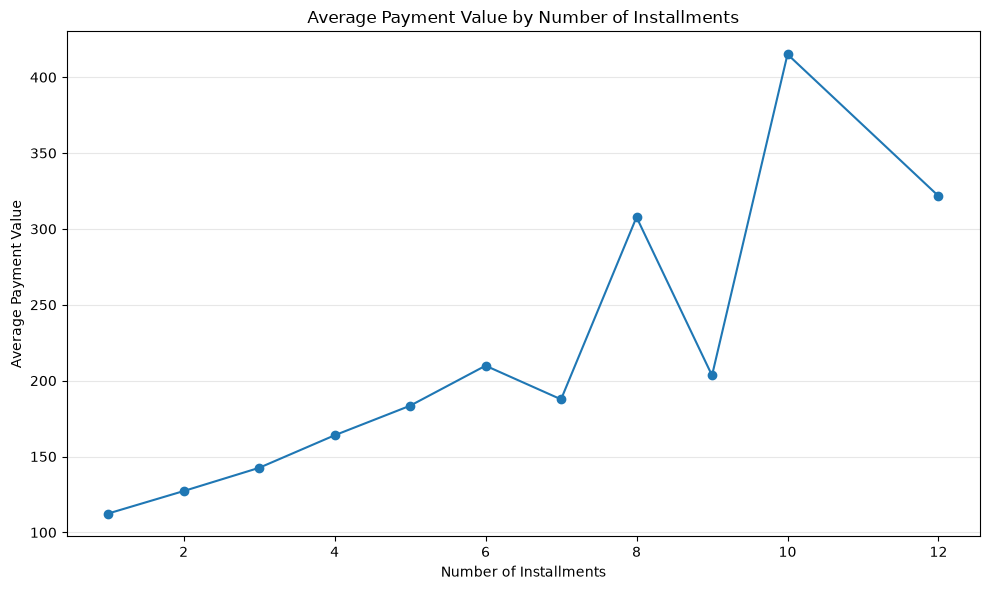

In [506]:
installment_value = (
    installment_summary[
        installment_summary["order_count"] >= 100
    ]
    .copy()
)

plt.figure(figsize=(10, 6))

plt.plot(
    installment_value.index,
    installment_value["avg_payment_value"],
    marker="o"
)

plt.title("Average Payment Value by Number of Installments")
plt.xlabel("Number of Installments")
plt.ylabel("Average Payment Value")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Payment Installment Analysis — Business Insights

Single-installment payments are the most common payment behavior, with
approximately 49K orders using one installment.

The number of orders generally decreases as the installment count increases,
indicating that customers predominantly prefer shorter payment plans.

Average payment value tends to increase with higher installment counts,
particularly across the commonly observed installment ranges. This suggests
that higher-value purchases are more likely to be associated with installment
payments.

However, installment categories with very low order volumes should be
interpreted cautiously. The analysis identifies an association between
installment usage and transaction value, but does not imply that using more
installments directly causes higher spending.

## 25. Payment Method vs Order Value

### Business Question

Do customers using different payment methods have different average order
values?

Average payment value is compared across payment methods to identify whether
certain payment methods are associated with higher-value transactions.

In [507]:
payment_aov = (
    order_payments_clean
    .groupby("payment_type")
    .agg(
        order_count=("order_id", "nunique"),
        total_payment_value=("payment_value", "sum"),
        avg_payment_value=("payment_value", "mean"),
        median_payment_value=("payment_value", "median")
    )
    .sort_values("avg_payment_value", ascending=False)
)

payment_aov.round(2)

,order_count,total_payment_value,avg_payment_value,median_payment_value
payment_type,,,,
credit_card,76505,12542084.19,163.32,106.87
boleto,19784,2869361.27,145.03,93.89
debit_card,1528,217989.79,142.57,89.30
voucher,3866,379436.87,65.70,39.28
not_defined,3,0.00,0.00,0.00


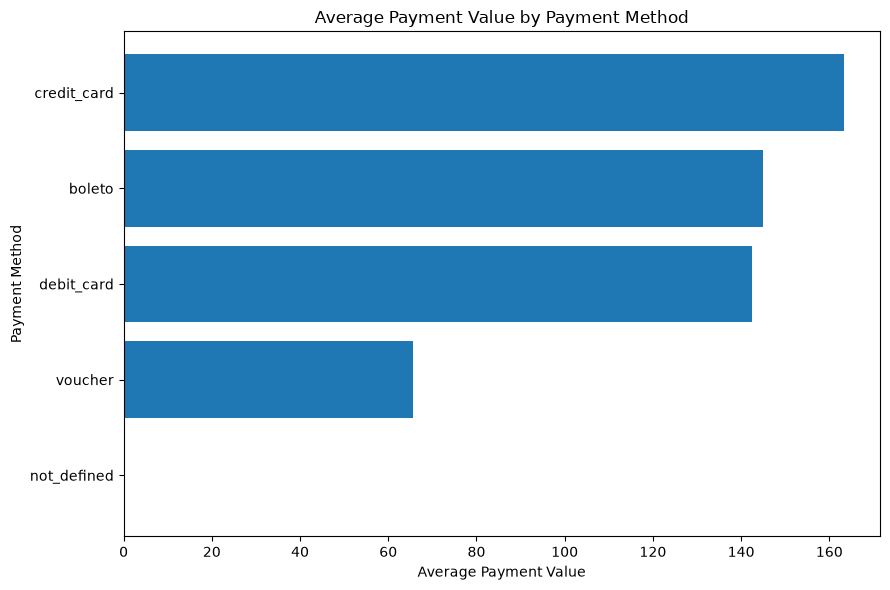

In [508]:
plt.figure(figsize=(9, 6))

payment_aov_plot = payment_aov.sort_values("avg_payment_value")

plt.barh(
    payment_aov_plot.index,
    payment_aov_plot["avg_payment_value"]
)

plt.title("Average Payment Value by Payment Method")
plt.xlabel("Average Payment Value")
plt.ylabel("Payment Method")

plt.tight_layout()
plt.show()

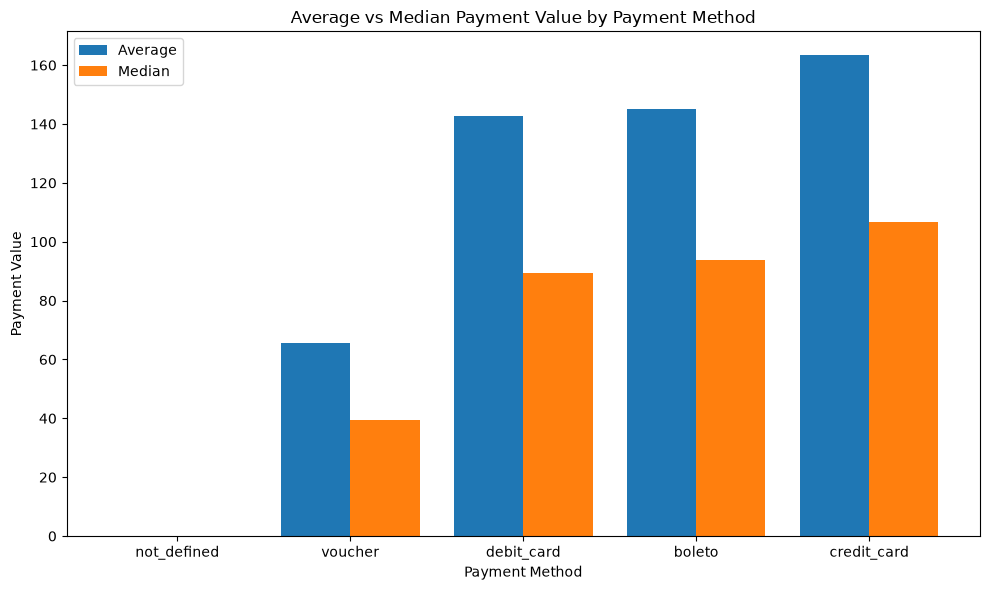

In [509]:
payment_value_compare = payment_aov.sort_values("avg_payment_value")

x = range(len(payment_value_compare))

plt.figure(figsize=(10, 6))

plt.bar(
    [i - 0.2 for i in x],
    payment_value_compare["avg_payment_value"],
    width=0.4,
    label="Average"
)

plt.bar(
    [i + 0.2 for i in x],
    payment_value_compare["median_payment_value"],
    width=0.4,
    label="Median"
)

plt.xticks(
    list(x),
    payment_value_compare.index
)

plt.title("Average vs Median Payment Value by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Payment Value")

plt.legend()
plt.tight_layout()
plt.show()

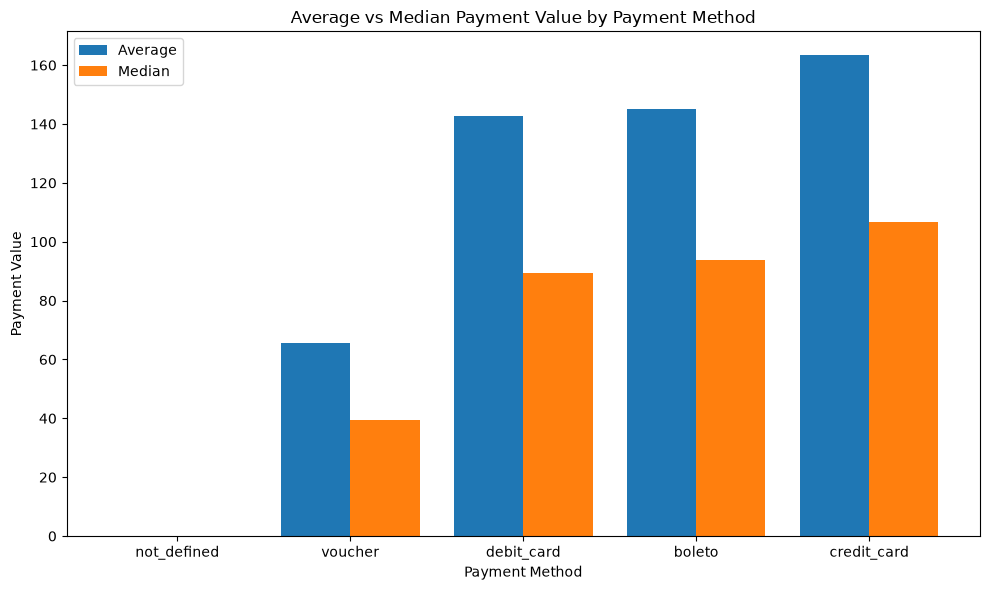

In [510]:
payment_value_compare = payment_aov.sort_values("avg_payment_value")

x = range(len(payment_value_compare))

plt.figure(figsize=(10, 6))

plt.bar(
    [i - 0.2 for i in x],
    payment_value_compare["avg_payment_value"],
    width=0.4,
    label="Average"
)

plt.bar(
    [i + 0.2 for i in x],
    payment_value_compare["median_payment_value"],
    width=0.4,
    label="Median"
)

plt.xticks(
    list(x),
    payment_value_compare.index
)

plt.title("Average vs Median Payment Value by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Payment Value")

plt.legend()
plt.tight_layout()
plt.show()

In [511]:
payment_aov_clean = (
    payment_aov
    .drop(index="not_defined", errors="ignore")
    .sort_values("avg_payment_value")
)

payment_aov_clean.round(2)

,order_count,total_payment_value,avg_payment_value,median_payment_value
payment_type,,,,
voucher,3866,379436.87,65.70,39.28
debit_card,1528,217989.79,142.57,89.30
boleto,19784,2869361.27,145.03,93.89
credit_card,76505,12542084.19,163.32,106.87


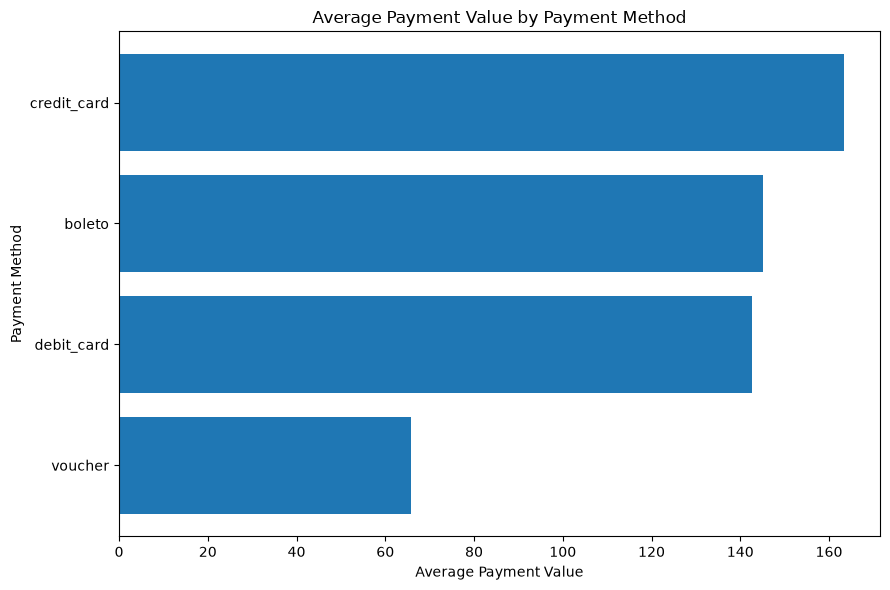

In [512]:
plt.figure(figsize=(9, 6))

plt.barh(
    payment_aov_clean.index,
    payment_aov_clean["avg_payment_value"]
)

plt.title("Average Payment Value by Payment Method")
plt.xlabel("Average Payment Value")
plt.ylabel("Payment Method")

plt.tight_layout()
plt.show()

### Payment Method vs Order Value — Business Insights

Average payment value varies across payment methods.

Credit card transactions have the highest average payment value among the
defined payment methods, followed by boleto and debit card transactions,
while voucher payments have a comparatively lower average payment value.

For all major payment methods, the average payment value is higher than the
median, indicating the presence of higher-value transactions that influence
the average.

These results show an association between payment method and transaction
value. However, the analysis does not imply that a particular payment method
causes customers to spend more.

## 26. Review Score Analysis

### Business Question

How satisfied are customers with their purchases?

Customer review scores are analyzed to understand the overall distribution
of satisfaction levels and identify whether reviews are concentrated around
positive or negative ratings.

In [513]:
# Load cleaned reviews dataset

order_reviews_clean = pd.read_csv(
    processed_dir / "olist_order_reviews_clean.csv"
)

order_reviews_clean.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [514]:


processed_dir = Path("../data/processed")

order_reviews_clean = pd.read_csv(
    processed_dir / "olist_order_reviews_clean.csv"
)

order_reviews_clean.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [515]:
review_summary = (
    order_reviews_clean
    .groupby("review_score")
    .agg(
        review_count=("review_id", "count"),
        order_count=("order_id", "nunique")
    )
    .sort_index()
)

review_summary

,review_count,order_count
review_score,,
1,11424,11393
2,3151,3148
3,8179,8160
4,19142,19098
5,57328,57076


In [516]:
review_distribution = (
    order_reviews_clean["review_score"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
)

review_distribution.round(2)

review_score
1    11.51
2     3.18
3     8.24
4    19.29
5    57.78
Name: proportion, dtype: float64

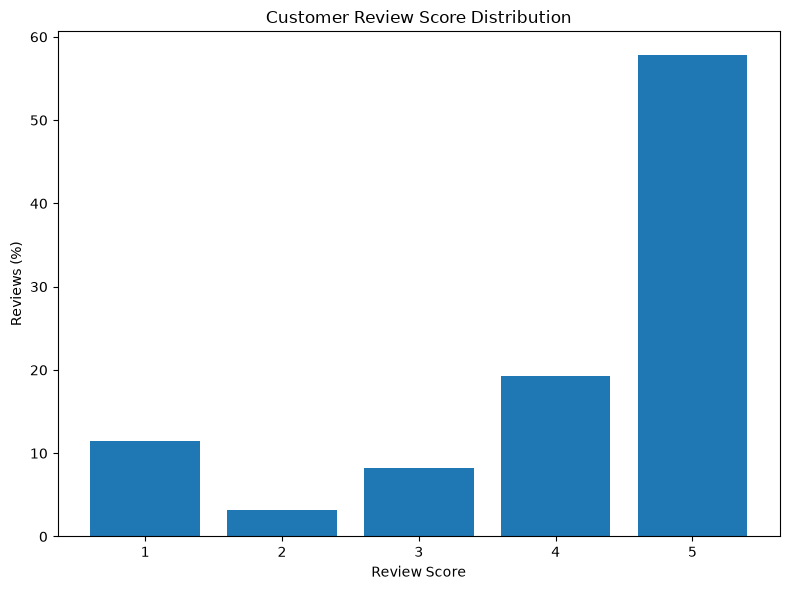

In [517]:
plt.figure(figsize=(8, 6))

plt.bar(
    review_distribution.index.astype(str),
    review_distribution.values
)

plt.title("Customer Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Reviews (%)")

plt.tight_layout()
plt.show()

### Review Score vs Delivery Performance

Customer review scores are compared across delivery performance categories
to understand whether early, on-time, or late deliveries are associated
with differences in customer satisfaction.

This helps identify whether delivery experience is an important factor
behind customer reviews.

In [518]:
review_delivery = (
    orders_clean[
        ["order_id", "delivery_status"]
    ]
    .merge(
        order_reviews_clean[
            ["order_id", "review_score"]
        ],
        on="order_id",
        how="inner"
    )
)

review_delivery.head()

,order_id,delivery_status,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,Early,4
1,53cdb2fc8bc7dce0b6741e2150273451,Early,4
2,47770eb9100c2d0c44946d9cf07ec65d,Early,5
3,949d5b44dbf5de918fe9c16f97b45f8a,Early,5
4,ad21c59c0840e6cb83a9ceb5573f8159,Early,5


In [519]:
review_by_delivery = (
    review_delivery
    .groupby("delivery_status")
    .agg(
        review_count=("review_score", "count"),
        avg_review_score=("review_score", "mean"),
        median_review_score=("review_score", "median")
    )
    .sort_values("avg_review_score", ascending=False)
)

review_by_delivery.round(2)

,review_count,avg_review_score,median_review_score
delivery_status,,,
Early,88658,4.29,5.0
On-time,1291,4.03,5.0
Late,6410,2.27,1.0
Unknown,2865,1.76,1.0


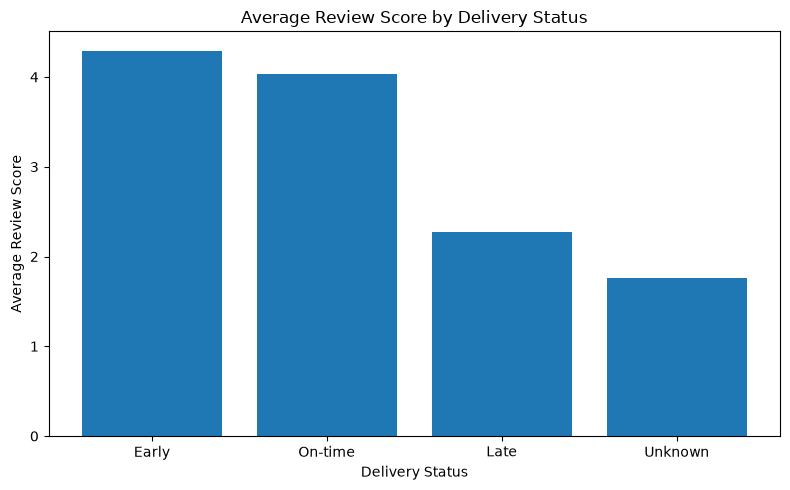

In [520]:
plt.figure(figsize=(8, 5))

plt.bar(
    review_by_delivery.index,
    review_by_delivery["avg_review_score"]
)

plt.title("Average Review Score by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Average Review Score")

plt.tight_layout()
plt.show()

In [521]:
review_delivery_dist = pd.crosstab(
    review_delivery["delivery_status"],
    review_delivery["review_score"],
    normalize="index"
) * 100

review_delivery_dist.round(2)

review_score,1,2,3,4,5
delivery_status,,,,,
Early,6.60,2.63,7.99,20.34,62.43
Late,53.73,8.67,10.89,10.17,16.54
On-time,8.52,3.87,13.79,23.39,50.43
Unknown,70.33,7.33,7.57,5.41,9.35


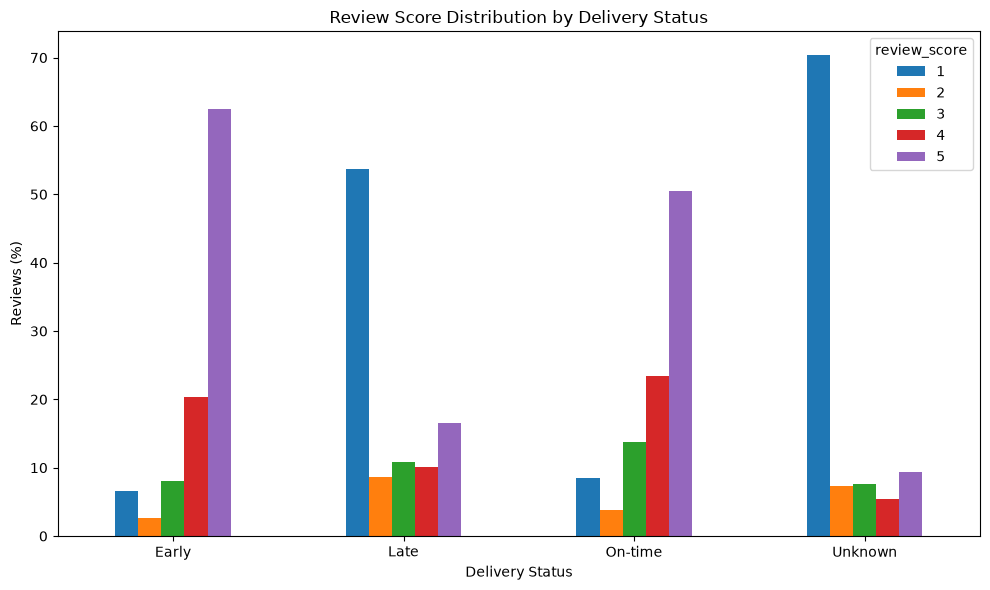

In [522]:
review_delivery_dist.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Review Score Distribution by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Reviews (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

### Review Score vs Delivery Performance — Business Insights

Delivery performance shows a strong association with customer satisfaction.

Early deliveries receive the highest average review score at approximately
4.27, followed by on-time deliveries at approximately 4.03.

In contrast, late deliveries have a much lower average review score of
approximately 2.29. More than half of reviews for late deliveries are
1-star ratings, while only about 16.5% are 5-star ratings.

This indicates that delivery delays are strongly associated with negative
customer experiences. Improving delivery reliability and reducing late
deliveries could therefore help improve overall customer satisfaction.

The analysis identifies an association between delivery performance and review
scores and does not establish a direct causal relationship.

## 27. Review Score vs Order Value

### Business Question

Do higher-value orders receive different customer review scores compared
with lower-value orders?

Order value is compared across review scores to understand whether customer
satisfaction varies with transaction value.

### Preparing Order-Level Revenue

Order-level revenue is calculated by combining product prices and freight
charges for all items belonging to the same order.

The resulting order value is then combined with customer review scores to
analyze the relationship between transaction value and customer satisfaction.

In [523]:
order_value_review = (
    order_items_clean
    .groupby("order_id")
    .agg(
        item_value=("price", "sum"),
        freight_value=("freight_value", "sum")
    )
    .reset_index()
)

order_value_review["total_order_value"] = (
    order_value_review["item_value"]
    + order_value_review["freight_value"]
)

order_value_review.head()

,order_id,item_value,freight_value,total_order_value
0,00010242fe8c5a6d1ba2dd792cb16214,58.90,13.29,72.19
1,00018f77f2f0320c557190d7a144bdd3,239.90,19.93,259.83
2,000229ec398224ef6ca0657da4fc703e,199.00,17.87,216.87
3,00024acbcdf0a6daa1e931b038114c75,12.99,12.79,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90,18.14,218.04


In [524]:
review_order_value = (
    order_value_review[
        ["order_id", "total_order_value"]
    ]
    .merge(
        order_reviews_clean[
            ["order_id", "review_score"]
        ],
        on="order_id",
        how="inner"
    )
)

review_order_value.head()

,order_id,total_order_value,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,5
1,00018f77f2f0320c557190d7a144bdd3,259.83,4
2,000229ec398224ef6ca0657da4fc703e,216.87,5
3,00024acbcdf0a6daa1e931b038114c75,25.78,4
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,5


In [525]:
review_value_summary = (
    review_order_value
    .groupby("review_score")
    .agg(
        review_count=("review_score", "count"),
        avg_order_value=("total_order_value", "mean"),
        median_order_value=("total_order_value", "median")
    )
    .sort_index()
)

review_value_summary.round(2)

,review_count,avg_order_value,median_order_value
review_score,,,
1,10884,194.30,120.56
2,3089,171.56,112.50
3,8126,151.15,103.28
4,19109,154.66,102.74
5,57257,156.20,103.14


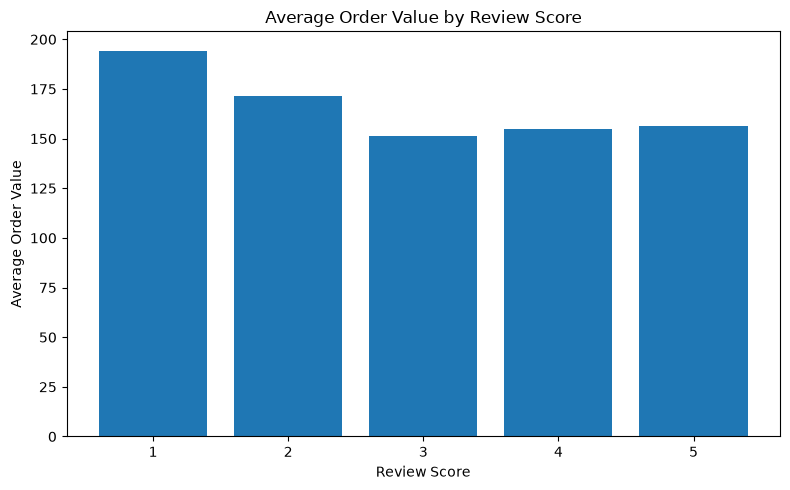

In [526]:
plt.figure(figsize=(8, 5))

plt.bar(
    review_value_summary.index.astype(str),
    review_value_summary["avg_order_value"]
)

plt.title("Average Order Value by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Average Order Value")

plt.tight_layout()
plt.show()

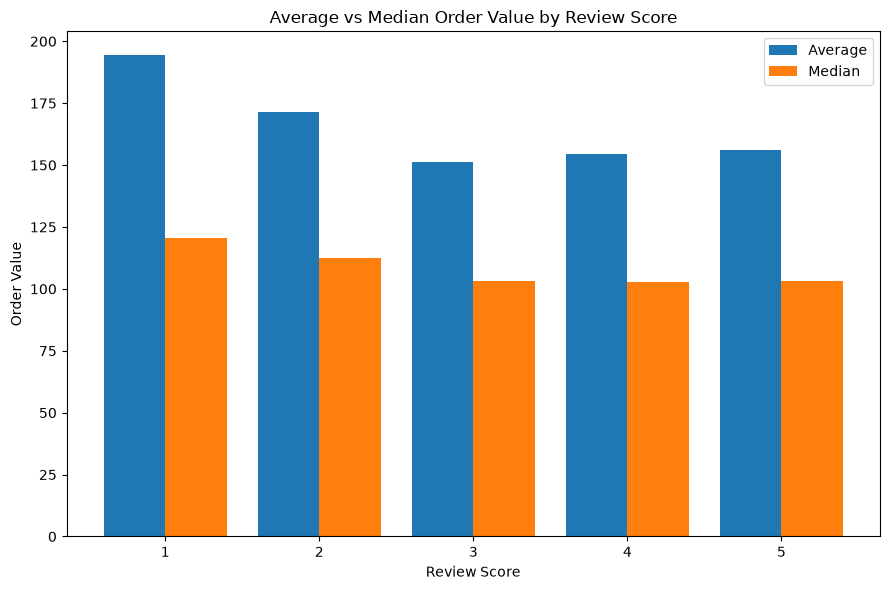

In [527]:
x = range(len(review_value_summary))

plt.figure(figsize=(9, 6))

plt.bar(
    [i - 0.2 for i in x],
    review_value_summary["avg_order_value"],
    width=0.4,
    label="Average"
)

plt.bar(
    [i + 0.2 for i in x],
    review_value_summary["median_order_value"],
    width=0.4,
    label="Median"
)

plt.xticks(
    list(x),
    review_value_summary.index.astype(str)
)

plt.title("Average vs Median Order Value by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Order Value")

plt.legend()
plt.tight_layout()
plt.show()

### Review Score vs Order Value — Business Insights

Lower review scores are associated with higher average order values in this
dataset.

The highest average order value is observed among 1-star reviews at
approximately 194.30, while 5-star reviews have an average order value of
approximately 156.20.

The median order value is substantially lower than the average for every
review score, indicating a right-skewed distribution with some high-value
orders.

Interestingly, higher-value transactions do not necessarily receive better
customer ratings. This suggests that customer satisfaction is influenced by
factors beyond transaction value, such as delivery experience and overall
service quality.

The analysis identifies an association between order value and review score
and does not establish a causal relationship.

## 28. Review Score vs Delivery Time

### Business Question

Does longer delivery time lead to lower customer satisfaction?

Actual delivery time is compared with customer review scores to determine
whether longer delivery durations are associated with poorer customer
experiences.

In [528]:
review_delivery_time = (
    orders_clean[
        ["order_id", "delivery_time_days"]
    ]
    .merge(
        order_reviews_clean[
            ["order_id", "review_score"]
        ],
        on="order_id",
        how="inner"
    )
)

review_delivery_time.head()

,order_id,delivery_time_days,review_score
0,e481f51cbdc54678b7cc49136f2d6af7,8.436574,4
1,53cdb2fc8bc7dce0b6741e2150273451,13.782037,4
2,47770eb9100c2d0c44946d9cf07ec65d,9.394213,5
3,949d5b44dbf5de918fe9c16f97b45f8a,13.208750,5
4,ad21c59c0840e6cb83a9ceb5573f8159,2.873877,5


In [529]:
delivery_review_summary = (
    review_delivery_time
    .groupby("review_score")
    .agg(
        review_count=("review_score", "count"),
        avg_delivery_days=("delivery_time_days", "mean"),
        median_delivery_days=("delivery_time_days", "median")
    )
    .sort_index()
)

delivery_review_summary.round(2)

,review_count,avg_delivery_days,median_delivery_days
review_score,,,
1,11424,21.31,16.78
2,3151,16.66,13.25
3,8179,14.26,12.05
4,19142,12.31,10.79
5,57328,10.69,9.24


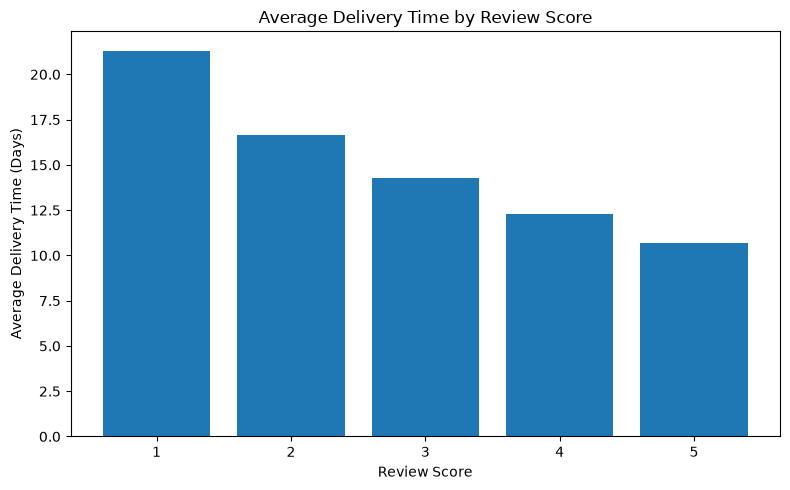

In [530]:
plt.figure(figsize=(8, 5))

plt.bar(
    delivery_review_summary.index.astype(str),
    delivery_review_summary["avg_delivery_days"]
)

plt.title("Average Delivery Time by Review Score")
plt.xlabel("Review Score")
plt.ylabel("Average Delivery Time (Days)")

plt.tight_layout()
plt.show()

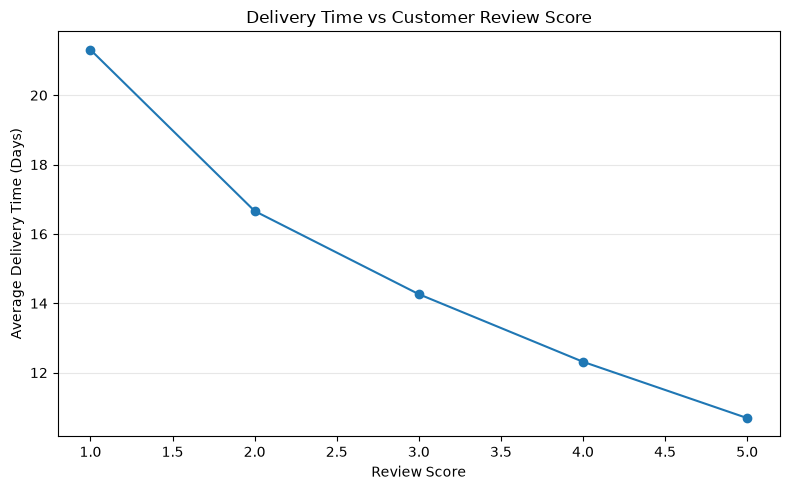

In [531]:
plt.figure(figsize=(8, 5))

plt.plot(
    delivery_review_summary.index,
    delivery_review_summary["avg_delivery_days"],
    marker="o"
)

plt.title("Delivery Time vs Customer Review Score")
plt.xlabel("Review Score")
plt.ylabel("Average Delivery Time (Days)")

plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### Review Score vs Delivery Time — Business Insights

A clear negative relationship is observed between delivery time and customer
review scores.

Customers giving 1-star reviews experienced the longest average delivery time,
at approximately 21 days. In contrast, customers giving 5-star reviews
experienced the shortest average delivery time, at approximately 10.7 days.

Overall, average delivery time decreases consistently as review scores
increase.

This suggests that faster delivery is strongly associated with higher customer
satisfaction. Reducing delivery delays and improving delivery speed could
therefore be an important area for improving the customer experience.

The analysis identifies an association between delivery time and review score
and does not establish a direct causal relationship.

## 29. Review Score by Product Category

### Business Question

Which product categories receive the highest and lowest customer review
scores?

Customer review scores are combined with product category information to
identify categories associated with stronger or weaker customer satisfaction.

Only categories with a meaningful number of reviews are considered to avoid
misleading results from very small samples.

In [532]:
category_reviews = (
    order_items_clean[
        ["order_id", "product_id"]
    ]
    .merge(
        products_clean[
            ["product_id", "product_category_name"]
        ],
        on="product_id",
        how="left"
    )
    .merge(
        order_reviews_clean[
            ["order_id", "review_score"]
        ],
        on="order_id",
        how="inner"
    )
)

category_reviews.head()

,order_id,product_id,product_category_name,review_score
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,5
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,pet_shop,4
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,moveis_decoracao,5
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,perfumaria,4
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,ferramentas_jardim,5


In [533]:
category_review_summary = (
    category_reviews
    .dropna(subset=["product_category_name"])
    .groupby("product_category_name")
    .agg(
        review_count=("review_score", "count"),
        avg_review_score=("review_score", "mean"),
        median_review_score=("review_score", "median")
    )
    .sort_values("avg_review_score", ascending=False)
)

category_review_summary.round(2).head(15)

,review_count,avg_review_score,median_review_score
product_category_name,,,
cds_dvds_musicais,14,4.64,5.0
fashion_roupa_infanto_juvenil,8,4.50,5.0
livros_interesse_geral,549,4.45,5.0
construcao_ferramentas_ferramentas,99,4.44,5.0
flores,31,4.42,5.0
livros_importados,60,4.40,5.0
livros_tecnicos,266,4.37,5.0
alimentos_bebidas,279,4.32,5.0
malas_acessorios,1088,4.32,5.0


In [534]:
category_review_filtered = (
    category_review_summary[
        category_review_summary["review_count"] >= 100
    ]
)

top_categories_reviews = (
    category_review_filtered
    .sort_values("avg_review_score", ascending=False)
    .head(15)
)

top_categories_reviews.round(2)

,review_count,avg_review_score,median_review_score
product_category_name,,,
livros_interesse_geral,549,4.45,5.0
livros_tecnicos,266,4.37,5.0
alimentos_bebidas,279,4.32,5.0
malas_acessorios,1088,4.32,5.0
fashion_calcados,261,4.23,5.0
alimentos,495,4.22,5.0
papelaria,2507,4.19,5.0
pet_shop,1939,4.19,5.0
pcs,200,4.18,5.0


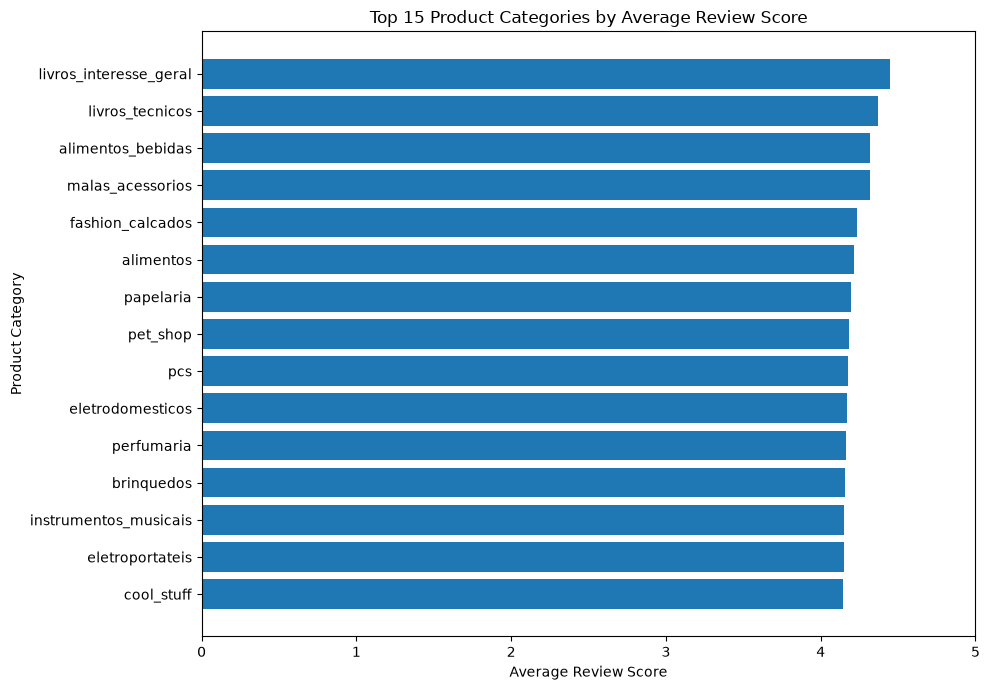

In [535]:
plt.figure(figsize=(10, 7))

plt.barh(
    top_categories_reviews.index[::-1],
    top_categories_reviews["avg_review_score"][::-1]
)

plt.title("Top 15 Product Categories by Average Review Score")
plt.xlabel("Average Review Score")
plt.ylabel("Product Category")

plt.xlim(0, 5)

plt.tight_layout()
plt.show()

In [536]:
bottom_categories_reviews = (
    category_review_filtered
    .sort_values("avg_review_score", ascending=True)
    .head(15)
)

bottom_categories_reviews.round(2)

,review_count,avg_review_score,median_review_score
product_category_name,,,
moveis_escritorio,1687,3.49,4.0
fashion_roupa_masculina,131,3.64,5.0
telefonia_fixa,262,3.68,4.0
audio,361,3.83,5.0
casa_conforto,435,3.83,5.0
unknown,1598,3.84,5.0
construcao_ferramentas_seguranca,193,3.84,5.0
cama_mesa_banho,11137,3.90,5.0
moveis_decoracao,8331,3.90,5.0


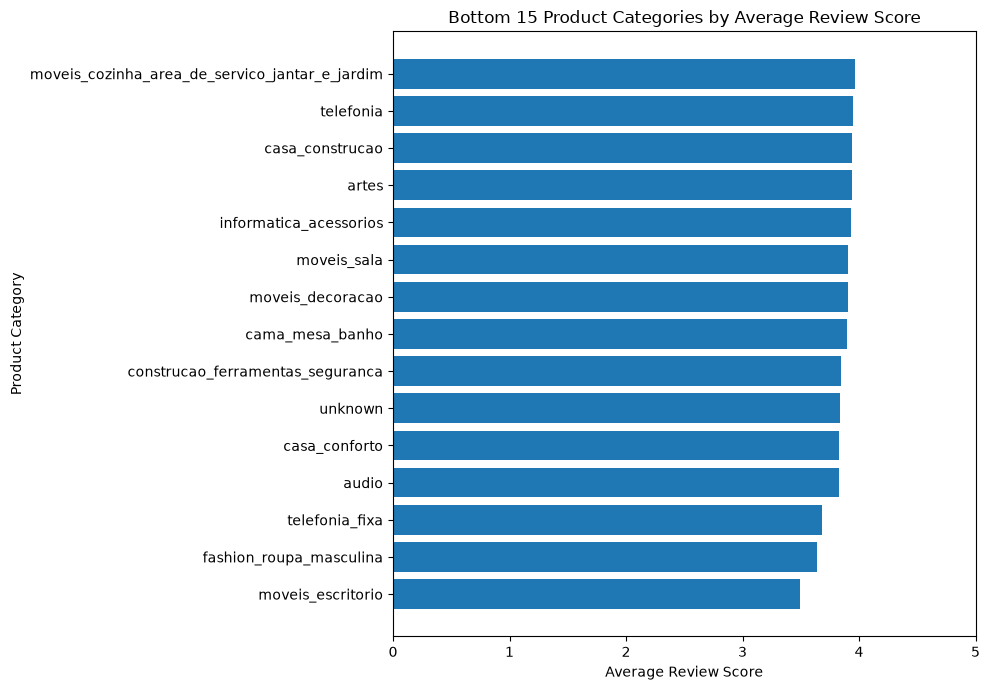

In [537]:
plt.figure(figsize=(10, 7))

plt.barh(
    bottom_categories_reviews.index,
    bottom_categories_reviews["avg_review_score"]
)

plt.title("Bottom 15 Product Categories by Average Review Score")
plt.xlabel("Average Review Score")
plt.ylabel("Product Category")

plt.xlim(0, 5)

plt.tight_layout()
plt.show()

### Review Score by Product Category — Business Insights

Customer satisfaction varies noticeably across product categories.

The highest average review scores are observed in categories such as general
interest books, technical books, food and beverages, and bags and accessories,
with average scores above 4.2.

In contrast, categories such as furniture, telephony, construction, and arts
have comparatively lower average review scores.

This indicates that product category is associated with differences in
customer satisfaction. Lower-rated categories can be prioritized for deeper
investigation, particularly by examining delivery performance, product
quality, pricing, and other operational factors.

Only categories with at least 100 reviews were considered to reduce the
impact of very small samples.

## 30. Category-wise Delivery Performance

### Business Question

Which product categories experience longer delivery times or higher rates
of late delivery?

Delivery performance is analyzed across product categories to identify
categories that may require operational improvement.

In [538]:
category_delivery = (
    order_items_clean[
        ["order_id", "product_id"]
    ]
    .merge(
        products_clean[
            ["product_id", "product_category_name"]
        ],
        on="product_id",
        how="left"
    )
    .merge(
        orders_clean[
            ["order_id", "delivery_time_days", "delivery_status"]
        ],
        on="order_id",
        how="inner"
    )
)

category_delivery.head()

,order_id,product_id,product_category_name,delivery_time_days,delivery_status
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,7.614421,Early
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,pet_shop,16.216181,Early
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,moveis_decoracao,7.948437,Early
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,perfumaria,6.147269,Early
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,ferramentas_jardim,25.114352,Early


In [539]:
category_delivery_summary = (
    category_delivery
    .dropna(subset=["product_category_name", "delivery_time_days"])
    .groupby("product_category_name")
    .agg(
        order_count=("order_id", "nunique"),
        avg_delivery_days=("delivery_time_days", "mean"),
        median_delivery_days=("delivery_time_days", "median"),
        late_orders=("delivery_status", lambda x: (x == "Late").sum())
    )
)

category_delivery_summary["late_delivery_pct"] = (
    category_delivery_summary["late_orders"]
    / category_delivery_summary["order_count"]
    * 100
)

category_delivery_summary = (
    category_delivery_summary
    .sort_values("avg_delivery_days", ascending=False)
)

category_delivery_summary.round(2).head(15)

,order_count,avg_delivery_days,median_delivery_days,late_orders,late_delivery_pct
product_category_name,,,,,
moveis_escritorio,1254,20.84,19.02,133,10.61
artigos_de_natal,125,15.74,13.03,15,12.00
fashion_calcados,235,15.44,13.99,11,4.68
seguros_e_servicos,2,15.14,15.14,0,0.00
casa_conforto_2,24,14.57,11.47,4,16.67
moveis_colchao_e_estofado,37,14.43,9.49,5,13.51
eletrodomesticos_2,227,13.91,11.03,14,6.17
moveis_sala,414,13.80,11.92,35,8.45
ferramentas_jardim,3448,13.71,11.84,280,8.12


In [540]:
category_delivery_filtered = (
    category_delivery_summary[
        category_delivery_summary["order_count"] >= 100
    ]
)

top_slow_categories = (
    category_delivery_filtered
    .sort_values("avg_delivery_days", ascending=False)
    .head(15)
)

top_slow_categories.round(2)

,order_count,avg_delivery_days,median_delivery_days,late_orders,late_delivery_pct
product_category_name,,,,,
moveis_escritorio,1254,20.84,19.02,133,10.61
artigos_de_natal,125,15.74,13.03,15,12.00
fashion_calcados,235,15.44,13.99,11,4.68
eletrodomesticos_2,227,13.91,11.03,14,6.17
moveis_sala,414,13.80,11.92,35,8.45
ferramentas_jardim,3448,13.71,11.84,280,8.12
fashion_underwear_e_moda_praia,117,13.71,10.69,12,10.26
consoles_games,1018,13.61,11.00,64,6.29
casa_conforto,392,13.53,11.14,40,10.20


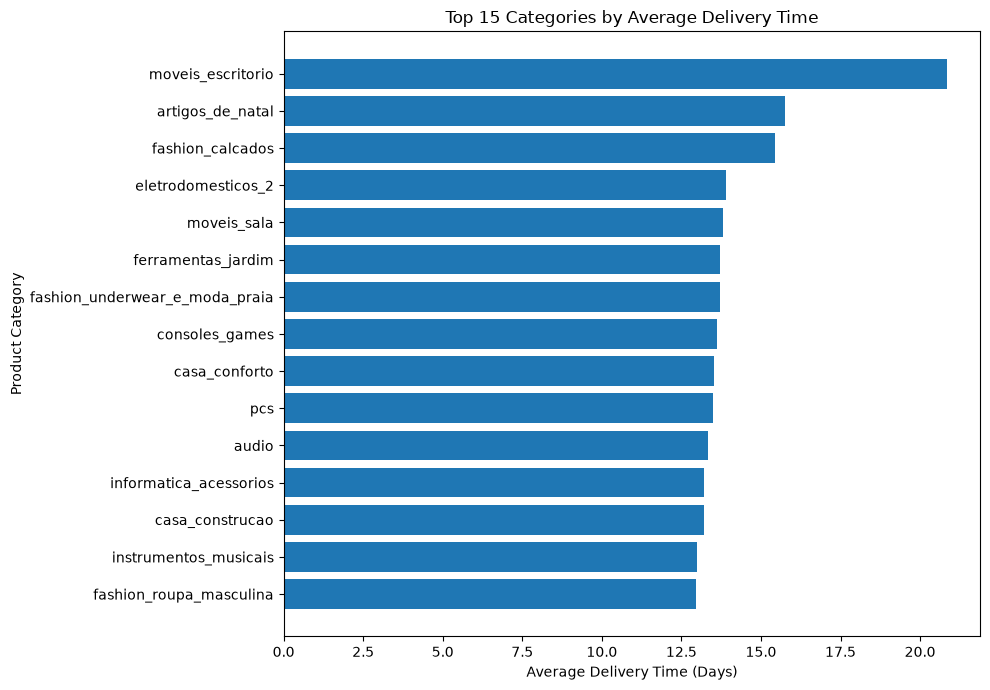

In [541]:
plt.figure(figsize=(10, 7))

plt.barh(
    top_slow_categories.index[::-1],
    top_slow_categories["avg_delivery_days"][::-1]
)

plt.title("Top 15 Categories by Average Delivery Time")
plt.xlabel("Average Delivery Time (Days)")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

In [542]:
top_late_categories = (
    category_delivery_filtered
    .sort_values("late_delivery_pct", ascending=False)
    .head(15)
)

top_late_categories.round(2)

,order_count,avg_delivery_days,median_delivery_days,late_orders,late_delivery_pct
product_category_name,,,,,
audio,348,13.32,10.66,42,12.07
artigos_de_natal,125,15.74,13.03,15,12.00
moveis_escritorio,1254,20.84,19.02,133,10.61
fashion_underwear_e_moda_praia,117,13.71,10.69,12,10.26
casa_conforto,392,13.53,11.14,40,10.20
moveis_decoracao,6307,12.88,10.76,574,9.10
construcao_ferramentas_iluminacao,242,9.72,8.20,22,9.09
moveis_sala,414,13.80,11.92,35,8.45
cama_mesa_banho,9272,12.81,10.39,770,8.30


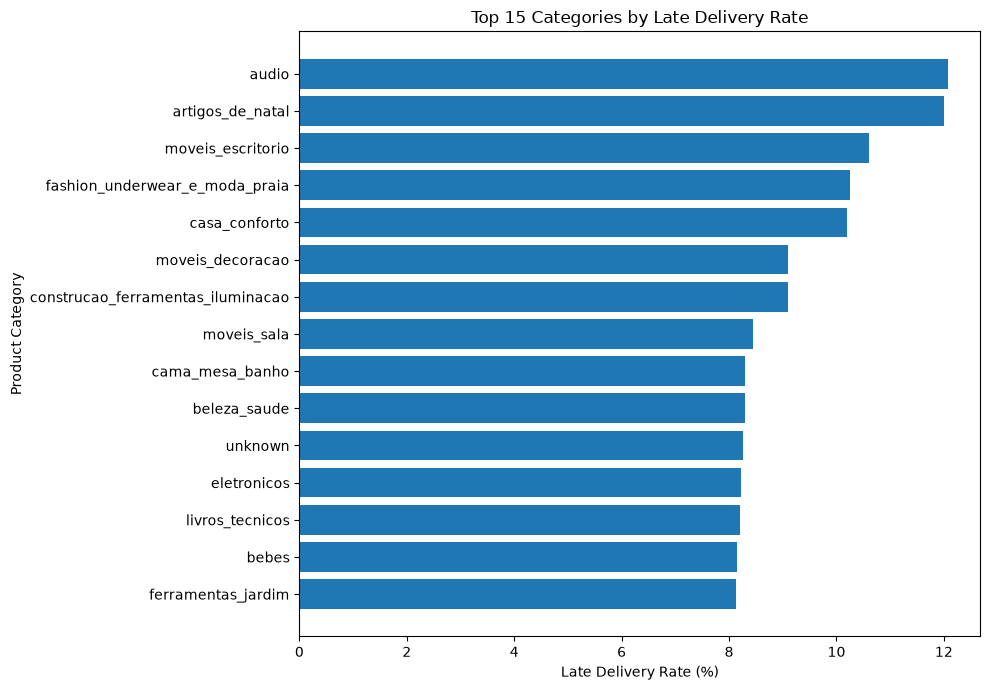

In [543]:
plt.figure(figsize=(10, 7))

plt.barh(
    top_late_categories.index[::-1],
    top_late_categories["late_delivery_pct"][::-1]
)

plt.title("Top 15 Categories by Late Delivery Rate")
plt.xlabel("Late Delivery Rate (%)")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

### Category-wise Delivery Performance — Business Insights

Delivery performance varies considerably across product categories.

The furniture office category has the highest average delivery time at
approximately 20.7 days, followed by Christmas products and footwear-related
categories.

However, the categories with the highest late-delivery rates are different.
Audio and Christmas products have late-delivery rates of approximately 12%,
while office furniture and fashion categories also show relatively high
late-delivery rates.

This indicates that categories with longer delivery times are not necessarily
the same categories with the highest frequency of late deliveries.

Categories with both high delivery times and high late-delivery rates should
be prioritized for operational investigation and logistics improvement.

Only categories with at least 100 orders were considered to reduce the impact
of small sample sizes.

## 31. Seller-wise Delivery Performance

### Business Question

Which sellers have longer delivery times or higher late-delivery rates?

Seller-level delivery performance is analyzed using order volume, average
delivery time, and late-delivery rate to identify sellers that may require
operational or logistics improvement.

In [544]:
seller_delivery_data = (
    order_items_clean[
        ["order_id", "seller_id"]
    ]
    .merge(
        orders_clean[
            ["order_id", "delivery_time_days", "delivery_status"]
        ],
        on="order_id",
        how="inner"
    )
)

seller_delivery_data.head()

,order_id,seller_id,delivery_time_days,delivery_status
0,00010242fe8c5a6d1ba2dd792cb16214,48436dade18ac8b2bce089ec2a041202,7.614421,Early
1,00018f77f2f0320c557190d7a144bdd3,dd7ddc04e1b6c2c614352b383efe2d36,16.216181,Early
2,000229ec398224ef6ca0657da4fc703e,5b51032eddd242adc84c38acab88f23d,7.948437,Early
3,00024acbcdf0a6daa1e931b038114c75,9d7a1d34a5052409006425275ba1c2b4,6.147269,Early
4,00042b26cf59d7ce69dfabb4e55b4fd9,df560393f3a51e74553ab94004ba5c87,25.114352,Early


In [545]:
seller_delivery = (
    seller_delivery_data
    .dropna(subset=["delivery_time_days"])
    .groupby("seller_id")
    .agg(
        order_count=("order_id", "nunique"),
        avg_delivery_days=("delivery_time_days", "mean"),
        median_delivery_days=("delivery_time_days", "median"),
        late_orders=("delivery_status", lambda x: (x == "Late").sum())
    )
)

seller_delivery["late_delivery_pct"] = (
    seller_delivery["late_orders"]
    / seller_delivery["order_count"]
    * 100
)

seller_delivery = seller_delivery.sort_values(
    "avg_delivery_days",
    ascending=False
)

seller_delivery.round(2).head(15)

,order_count,avg_delivery_days,median_delivery_days,late_orders,late_delivery_pct
seller_id,,,,,
df683dfda87bf71ac3fc63063fba369d,1,189.86,189.86,1,100.00
8e670472e453ba34a379331513d6aab1,1,86.00,86.00,1,100.00
586a871d4f1221763fddb6ceefdeb95e,1,68.62,68.62,2,200.00
4fb41dff7c50136976d1a5cf004a42e2,3,66.75,17.24,1,33.33
8629a7efec1aab257e58cda559f03ba7,1,59.23,59.23,1,100.00
3da38366e7bd9baf6369071f782ecdf0,1,53.35,53.35,1,100.00
eebb3372362aa9a46975164bed19a7e7,4,52.58,17.84,2,50.00
87f3e35268860433e13d577825aada95,1,51.50,51.50,0,0.00
8c3b533c63cca56240f94f1e3a6b18ef,3,49.22,48.55,4,133.33


In [546]:
seller_delivery_filtered = (
    seller_delivery[
        seller_delivery["order_count"] >= 100
    ]
)

slowest_sellers = (
    seller_delivery_filtered
    .sort_values("avg_delivery_days", ascending=False)
    .head(15)
)

slowest_sellers.round(2)

,order_count,avg_delivery_days,median_delivery_days,late_orders,late_delivery_pct
seller_id,,,,,
7c67e1448b00f6e969d365cea6b010ab,973,22.39,19.86,120,12.33
88460e8ebdecbfecb5f9601833981930,246,18.27,16.01,49,19.92
2eb70248d66e0e3ef83659f71b244378,187,17.97,16.16,23,12.30
06a2c3af7b3aee5d69171b0e14f0ee87,389,17.74,15.77,78,20.05
431af27f296bc6519d890aa5a05fdb11,116,16.94,14.73,17,14.66
cd68562d3f44870c08922d380acae552,122,16.78,13.48,23,18.85
8160255418d5aaa7dbdc9f4c64ebda44,380,16.78,14.00,64,16.84
8e6cc767478edae941d9bd9eb778d77a,100,16.50,15.17,6,6.00
b33e7c55446eabf8fe1a42d037ac7d6d,149,16.43,13.72,18,12.08


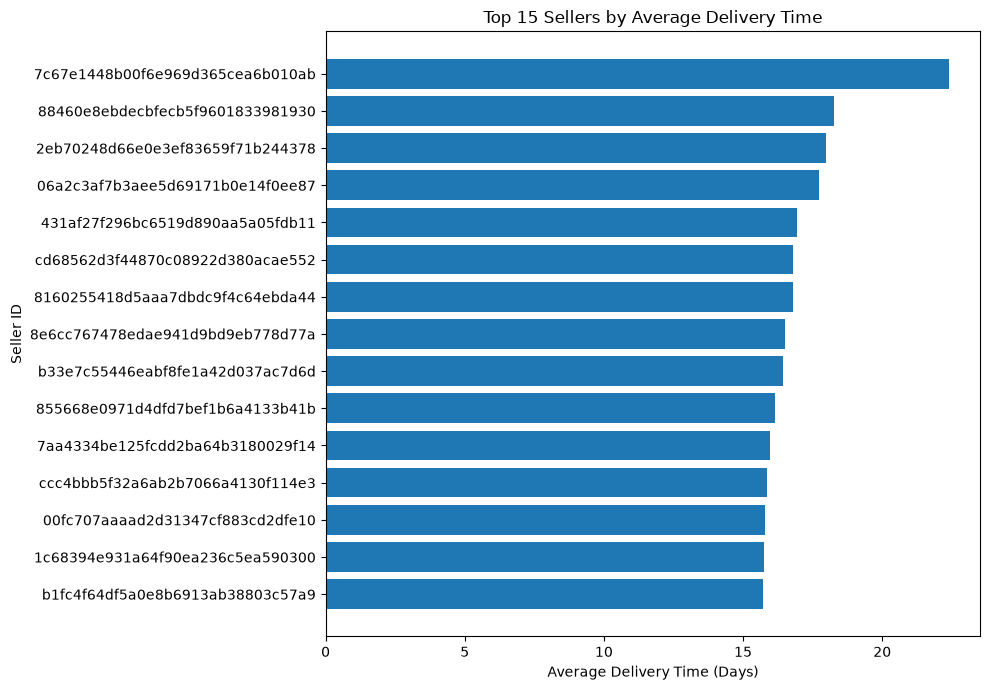

In [547]:
plt.figure(figsize=(10, 7))

plt.barh(
    slowest_sellers.index.astype(str)[::-1],
    slowest_sellers["avg_delivery_days"][::-1]
)

plt.title("Top 15 Sellers by Average Delivery Time")
plt.xlabel("Average Delivery Time (Days)")
plt.ylabel("Seller ID")

plt.tight_layout()
plt.show()

In [548]:
latest_sellers = (
    seller_delivery_filtered
    .sort_values("late_delivery_pct", ascending=False)
    .head(15)
)

latest_sellers.round(2)

,order_count,avg_delivery_days,median_delivery_days,late_orders,late_delivery_pct
seller_id,,,,,
2c9e548be18521d1c43cde1c582c6de8,124,13.73,8.80,28,22.58
06a2c3af7b3aee5d69171b0e14f0ee87,389,17.74,15.77,78,20.05
88460e8ebdecbfecb5f9601833981930,246,18.27,16.01,49,19.92
cd68562d3f44870c08922d380acae552,122,16.78,13.48,23,18.85
e5a3438891c0bfdb9394643f95273d8e,216,15.38,12.64,39,18.06
1ca7077d890b907f89be8c954a02686a,108,15.03,13.27,19,17.59
8160255418d5aaa7dbdc9f4c64ebda44,380,16.78,14.00,64,16.84
897060da8b9a21f655304d50fd935913,304,14.86,12.15,46,15.13
b2479f944e1b90cf8a5de1bbfde284d6,101,15.44,11.34,15,14.85


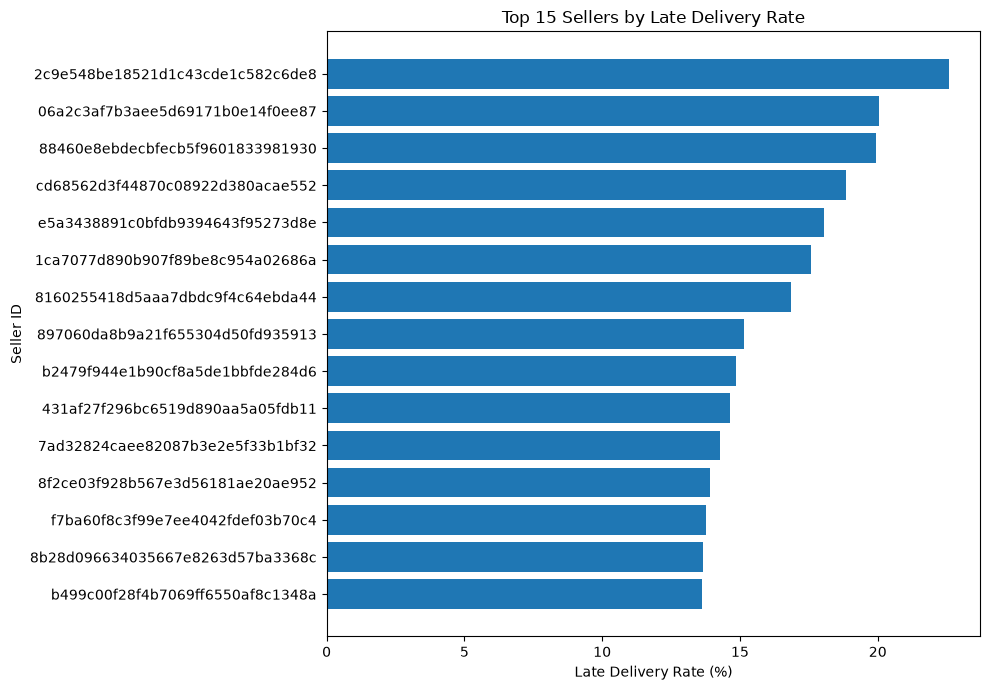

In [549]:
plt.figure(figsize=(10, 7))

plt.barh(
    latest_sellers.index.astype(str)[::-1],
    latest_sellers["late_delivery_pct"][::-1]
)

plt.title("Top 15 Sellers by Late Delivery Rate")
plt.xlabel("Late Delivery Rate (%)")
plt.ylabel("Seller ID")

plt.tight_layout()
plt.show()

### Seller-wise Delivery Performance — Business Insights

Seller-level delivery performance varies significantly across the marketplace.

Some sellers have substantially higher average delivery times, with the
slowest sellers taking more than 20 days on average to deliver orders.

Late-delivery rates also vary considerably. The highest-performing-risk seller
in terms of late deliveries has a late-delivery rate of approximately 22.6%,
meaning roughly one in five orders is delivered late.

The seller with the highest average delivery time is not necessarily the same
seller with the highest late-delivery rate. Therefore, both delivery duration
and late-delivery frequency should be considered when evaluating seller
performance.

Sellers with consistently poor delivery performance can be prioritized for
operational review, logistics support, or seller-level performance monitoring.

Only sellers with at least 100 orders were considered to reduce the impact of
small sample sizes.

## 32. Seller Revenue vs Delivery Performance

### Business Question

Is there a relationship between seller revenue and delivery performance?

Seller revenue is compared with average delivery time to determine whether
high-revenue sellers generally provide faster or slower delivery.

In [550]:
seller_revenue_delivery = (
    seller_performance
    .reset_index()
    [
        ["seller_id", "total_revenue", "orders"]
    ]
    .merge(
        seller_delivery[
            ["avg_delivery_days", "late_delivery_pct"]
        ],
        left_on="seller_id",
        right_index=True,
        how="inner"
    )
)

seller_revenue_delivery.head()

,seller_id,total_revenue,orders,avg_delivery_days,late_delivery_pct
0,4869f7a5dfa277a7dca6462dcf3b52b2,229472.63,1132,15.005261,10.765125
1,53243585a1d6dc2643021fd1853d8905,222776.05,358,13.374429,3.448276
2,4a3ca9315b744ce9f8e9374361493884,200472.92,1806,14.416471,10.665914
3,fa1c13f2614d7b5c4749cbc52fecda94,194042.03,585,13.341871,9.169550
4,7c67e1448b00f6e969d365cea6b010ab,187923.89,982,22.392546,12.332991


In [551]:
seller_revenue_delivery[
    [
        "total_revenue",
        "orders",
        "avg_delivery_days",
        "late_delivery_pct"
    ]
].describe().round(2)

,total_revenue,orders,avg_delivery_days,late_delivery_pct
count,2970.00,2970.00,2970.00,2970.00
mean,4566.52,33.62,12.17,7.98
std,14185.21,107.13,7.10,19.99
min,6.50,1.00,1.21,0.00
25%,239.80,2.00,8.29,0.00
50%,893.50,7.00,11.12,0.00
75%,3586.02,23.00,14.24,8.33
max,229472.63,1854.00,189.86,300.00


## 33. Monthly Revenue Trend

### Business Question

How does the business revenue change over time?

Monthly revenue is analyzed to identify growth trends, seasonal patterns,
and periods of unusually high or low sales activity.

In [552]:
monthly_revenue = (
    order_revenue[
        ["order_id", "total_order_value"]
    ]
    .merge(
        orders_clean[
            ["order_id", "order_purchase_timestamp"]
        ],
        on="order_id",
        how="inner"
    )
)

monthly_revenue["order_purchase_timestamp"] = pd.to_datetime(
    monthly_revenue["order_purchase_timestamp"]
)

monthly_revenue["month"] = (
    monthly_revenue["order_purchase_timestamp"]
    .dt.to_period("M")
)

monthly_revenue_summary = (
    monthly_revenue
    .groupby("month")
    .agg(
        order_count=("order_id", "nunique"),
        total_revenue=("total_order_value", "sum"),
        avg_order_value=("total_order_value", "mean")
    )
)

monthly_revenue_summary.round(2).head()

,order_count,total_revenue,avg_order_value
month,,,
2016-09,3,354.75,118.25
2016-10,308,56808.84,184.44
2016-12,1,19.62,19.62
2017-01,789,137188.49,173.88
2017-02,1733,286280.62,165.19


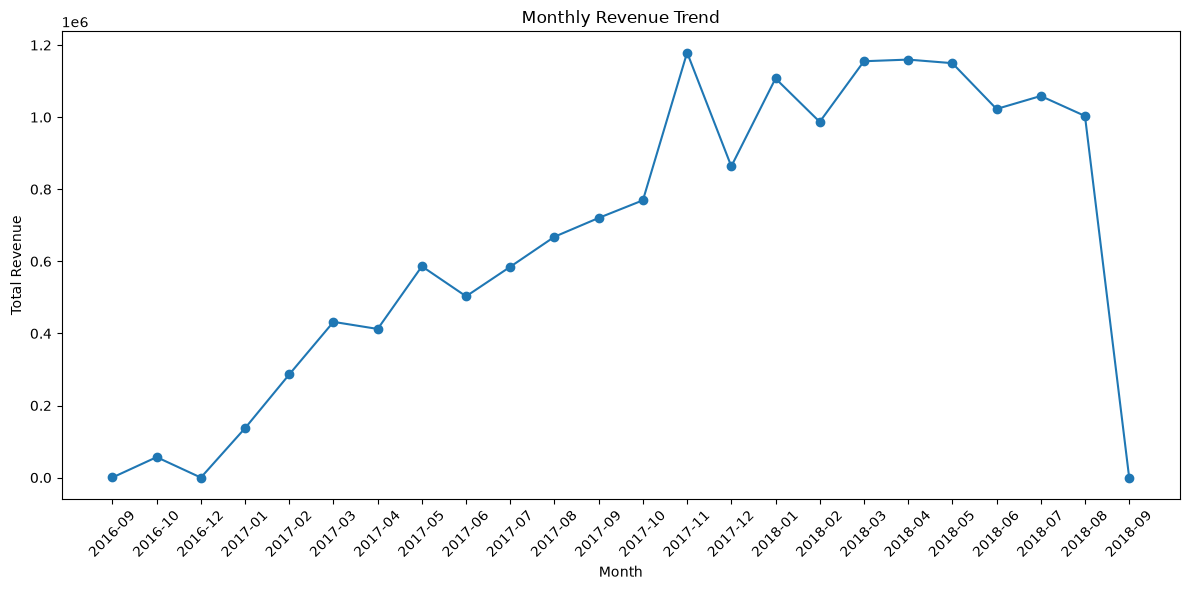

In [553]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue_summary.index.astype(str),
    monthly_revenue_summary["total_revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

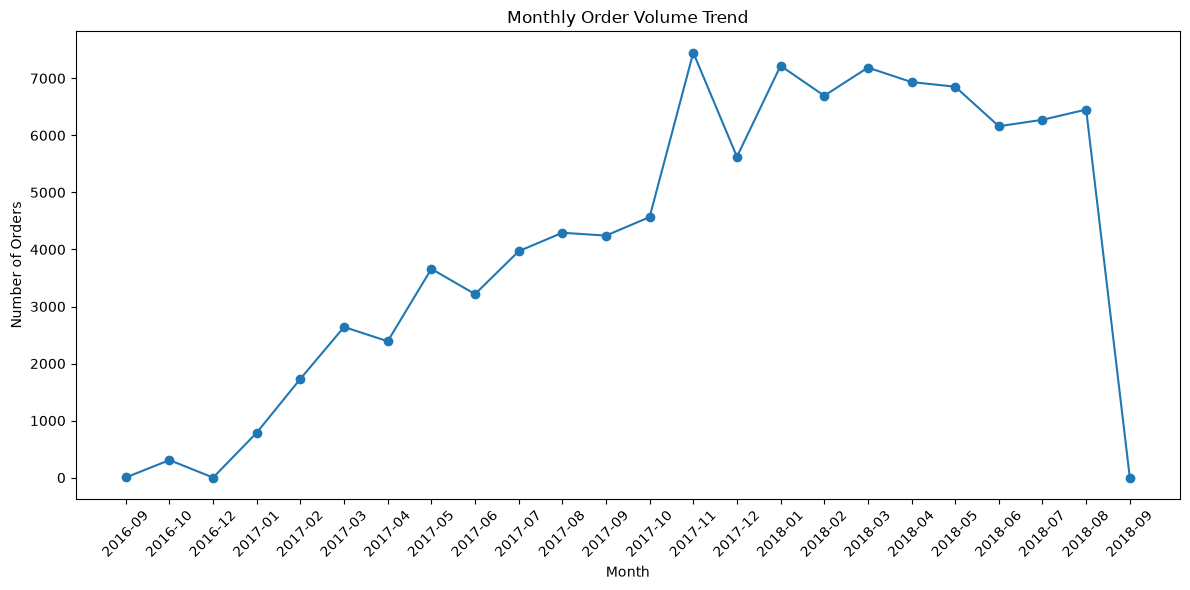

In [554]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue_summary.index.astype(str),
    monthly_revenue_summary["order_count"],
    marker="o"
)

plt.title("Monthly Order Volume Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

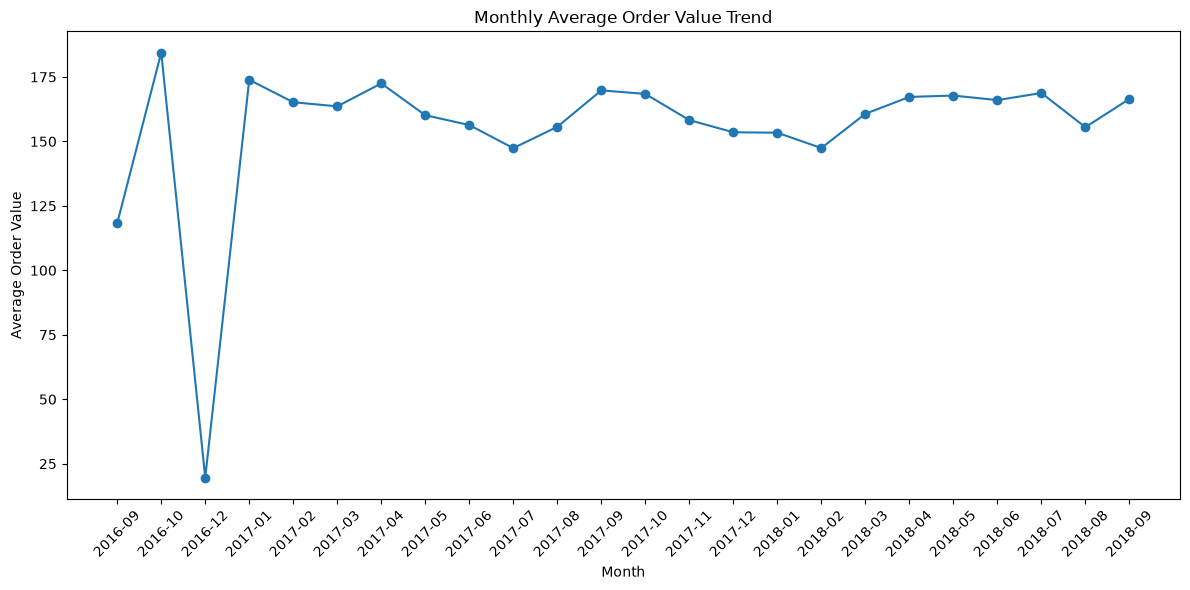

In [555]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_revenue_summary.index.astype(str),
    monthly_revenue_summary["avg_order_value"],
    marker="o"
)

plt.title("Monthly Average Order Value Trend")
plt.xlabel("Month")
plt.ylabel("Average Order Value")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Monthly Revenue Trend — Business Insights

The business shows strong growth in revenue and order volume over the
observed period.

Revenue and order volume increase substantially throughout 2017 and remain
at relatively high levels during most of 2018, although month-to-month
fluctuations are present.

Average Order Value remains comparatively stable during the later period.
This suggests that overall revenue growth is driven primarily by increasing
order volume rather than a major increase in the value of individual orders.

The final month shows an unusually sharp decline in revenue and order volume.
This period should be treated cautiously because it may represent a partial
or incomplete month rather than a genuine collapse in business activity.

## 34. Month-over-Month Growth Analysis

### Business Question

Which months experienced the strongest revenue and order growth?

Month-over-month growth is calculated to identify periods of rapid expansion
and periods of declining business activity.

In [556]:
monthly_growth = monthly_revenue_summary.copy()

monthly_growth["revenue_growth_pct"] = (
    monthly_growth["total_revenue"]
    .pct_change()
    * 100
)

monthly_growth["order_growth_pct"] = (
    monthly_growth["order_count"]
    .pct_change()
    * 100
)

monthly_growth.round(2)

,order_count,total_revenue,avg_order_value,revenue_growth_pct,order_growth_pct
month,,,,,
2016-09,3,354.75,118.25,NaN,NaN
2016-10,308,56808.84,184.44,15913.77,10166.67
2016-12,1,19.62,19.62,-99.97,-99.68
2017-01,789,137188.49,173.88,699127.78,78800.00
2017-02,1733,286280.62,165.19,108.68,119.65
2017-03,2641,432048.59,163.59,50.92,52.39
2017-04,2391,412422.24,172.49,-4.54,-9.47
2017-05,3660,586190.95,160.16,42.13,53.07
2017-06,3217,502963.04,156.35,-14.20,-12.10


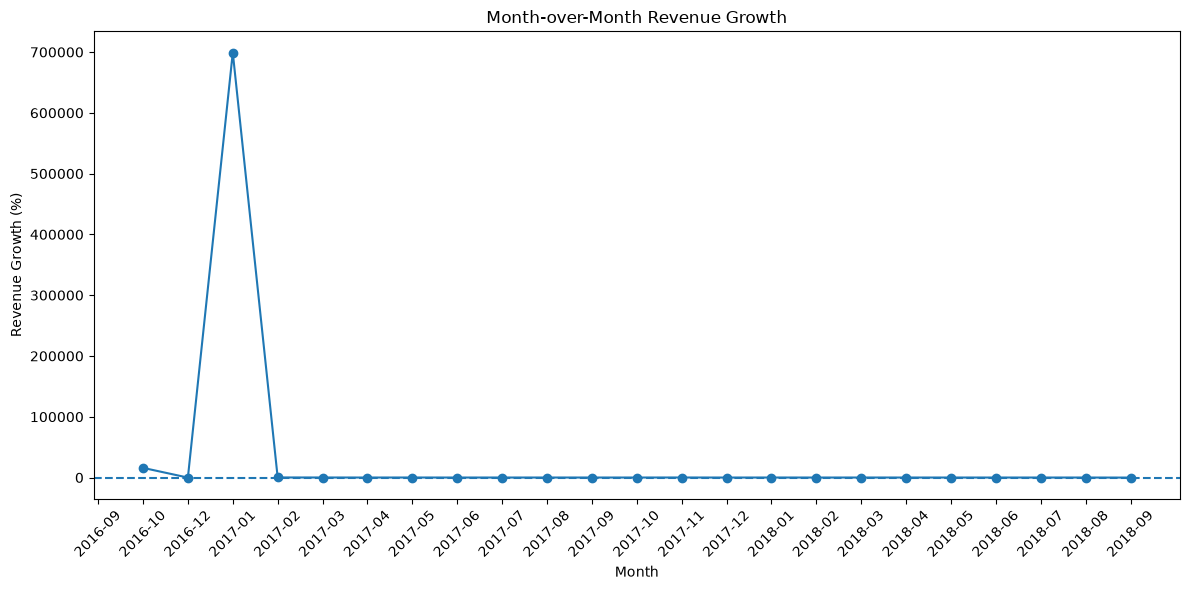

In [557]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_growth.index.astype(str),
    monthly_growth["revenue_growth_pct"],
    marker="o"
)

plt.axhline(0, linestyle="--")

plt.title("Month-over-Month Revenue Growth")
plt.xlabel("Month")
plt.ylabel("Revenue Growth (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

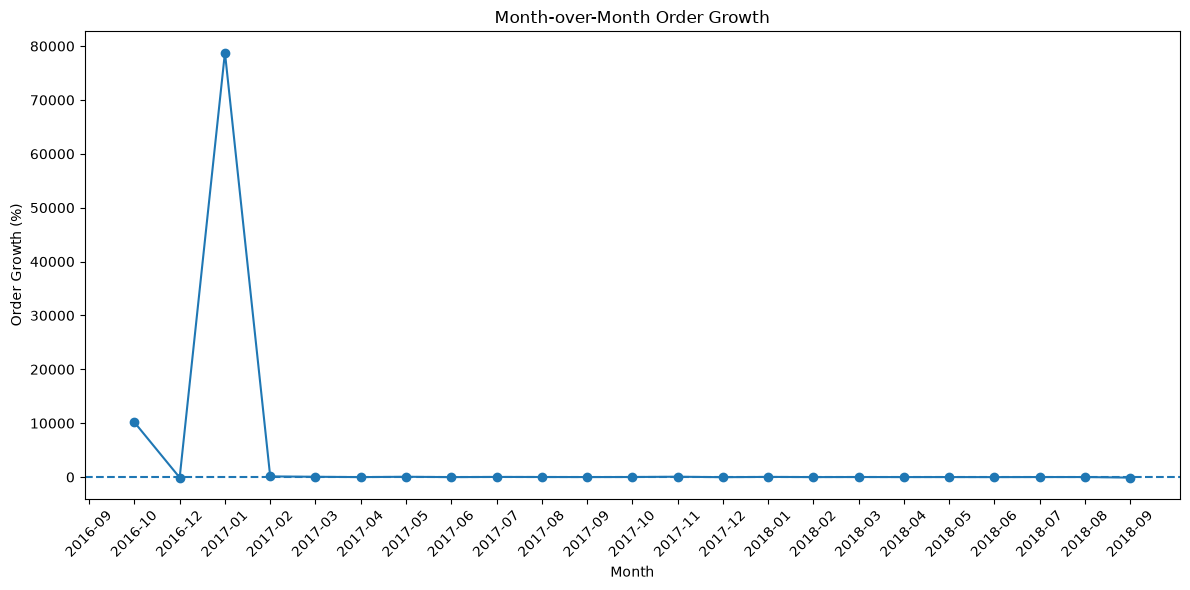

In [558]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_growth.index.astype(str),
    monthly_growth["order_growth_pct"],
    marker="o"
)

plt.axhline(0, linestyle="--")

plt.title("Month-over-Month Order Growth")
plt.xlabel("Month")
plt.ylabel("Order Growth (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### Month-over-Month Growth — Business Insights

Month-over-month growth shows substantial fluctuations during the early
months of the dataset.

An extremely large growth percentage is observed during the initial growth
period. This is primarily caused by the low revenue and order base in the
preceding month, resulting in a very high percentage change.

After the initial period, month-over-month growth becomes considerably more
stable, with smaller positive and negative fluctuations as the business
matures.

Therefore, extreme growth percentages during the early months should be
interpreted cautiously because they are influenced by the low-base effect.

The final month also shows an unusually large decline due to the very low
order and revenue volume observed in that month, which may indicate a
partial/incomplete month rather than a genuine business collapse.

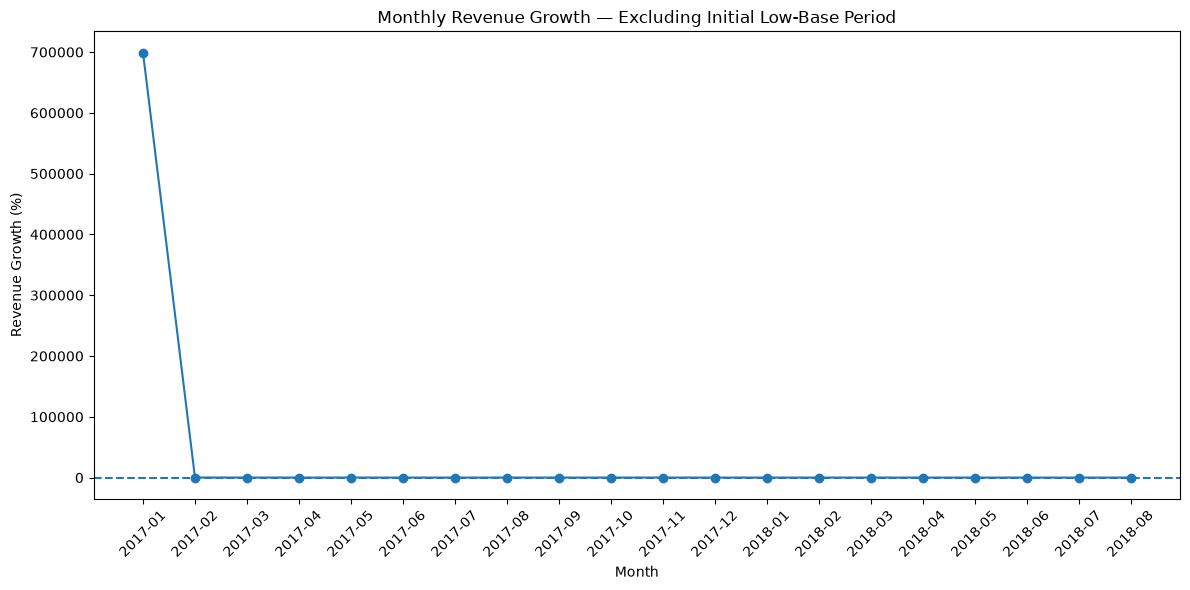

In [559]:
monthly_growth_clean = (
    monthly_growth
    .iloc[3:-1]
    .copy()
)

plt.figure(figsize=(12, 6))

plt.plot(
    monthly_growth_clean.index.astype(str),
    monthly_growth_clean["revenue_growth_pct"],
    marker="o"
)

plt.axhline(0, linestyle="--")

plt.title("Monthly Revenue Growth — Excluding Initial Low-Base Period")
plt.xlabel("Month")
plt.ylabel("Revenue Growth (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

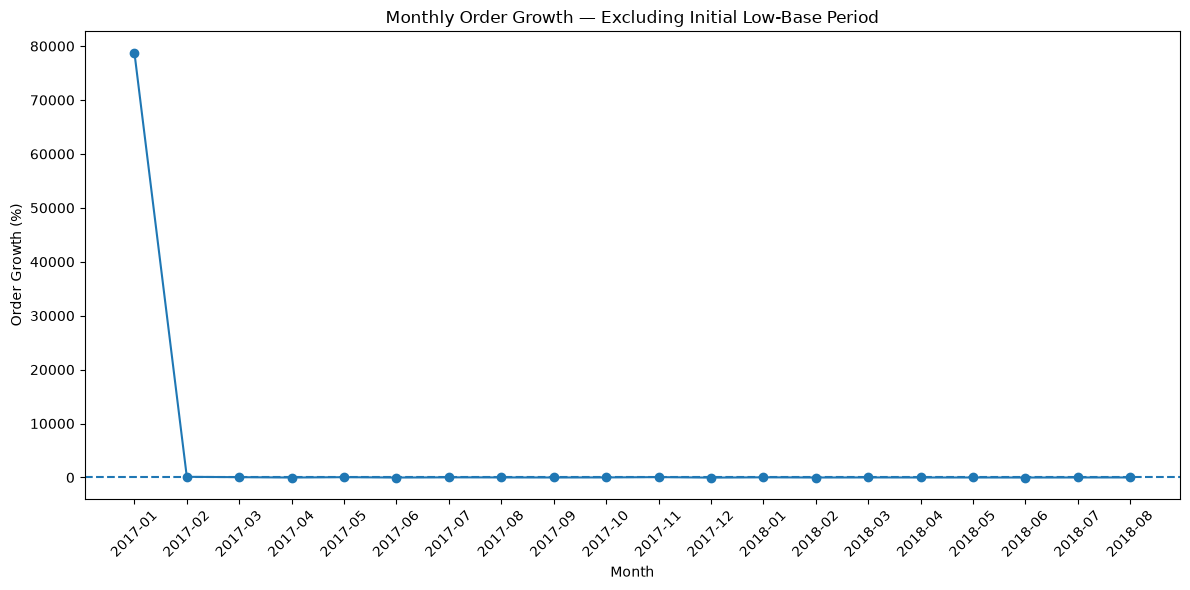

In [560]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_growth_clean.index.astype(str),
    monthly_growth_clean["order_growth_pct"],
    marker="o"
)

plt.axhline(0, linestyle="--")

plt.title("Monthly Order Growth — Excluding Initial Low-Base Period")
plt.xlabel("Month")
plt.ylabel("Order Growth (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 35. Monthly Seasonality Analysis

### Business Question

Are there recurring seasonal patterns in customer demand and revenue?

Monthly order volume, revenue, and average order value are aggregated by
calendar month across all years to identify months with consistently higher
or lower business activity.


In [561]:
seasonality_data = monthly_revenue.copy()

seasonality_data["month_num"] = (
    seasonality_data["order_purchase_timestamp"]
    .dt.month
)

seasonality_summary = (
    seasonality_data
    .groupby("month_num")
    .agg(
        order_count=("order_id", "nunique"),
        total_revenue=("total_order_value", "sum"),
        avg_order_value=("total_order_value", "mean")
    )
    .sort_index()
)

seasonality_summary.round(2)

,order_count,total_revenue,avg_order_value
month_num,,,
1,8009,1244490.38,155.39
2,8427,1273189.58,151.08
3,9829,1587175.41,161.48
4,9325,1572120.28,168.59
5,10513,1735972.77,165.13
6,9377,1525640.15,162.70
7,10242,1643699.65,160.49
8,10745,1671513.07,155.56
9,4247,720920.12,169.75


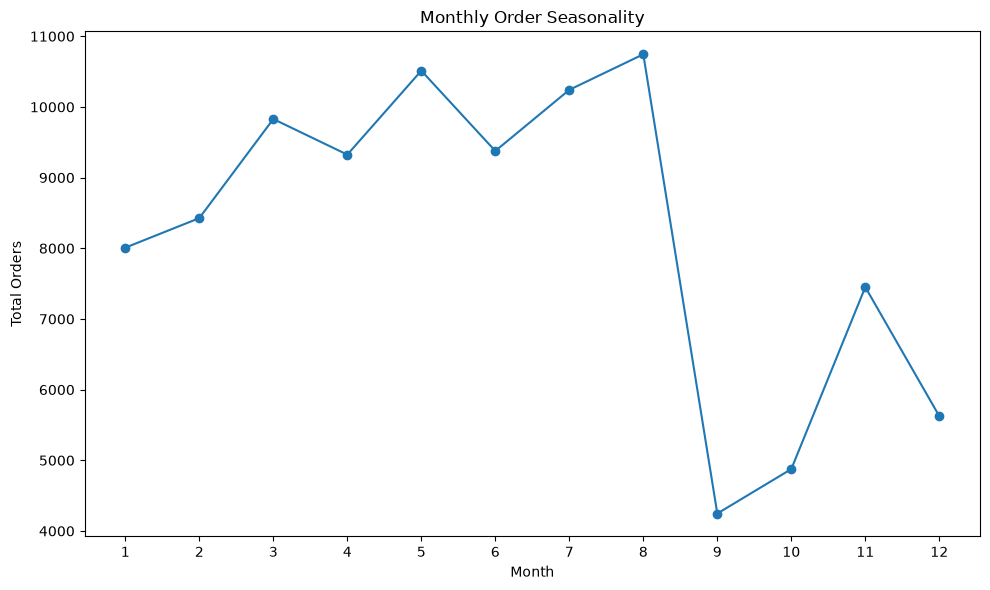

In [562]:
plt.figure(figsize=(10, 6))

plt.plot(
    seasonality_summary.index,
    seasonality_summary["order_count"],
    marker="o"
)

plt.title("Monthly Order Seasonality")
plt.xlabel("Month")
plt.ylabel("Total Orders")

plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

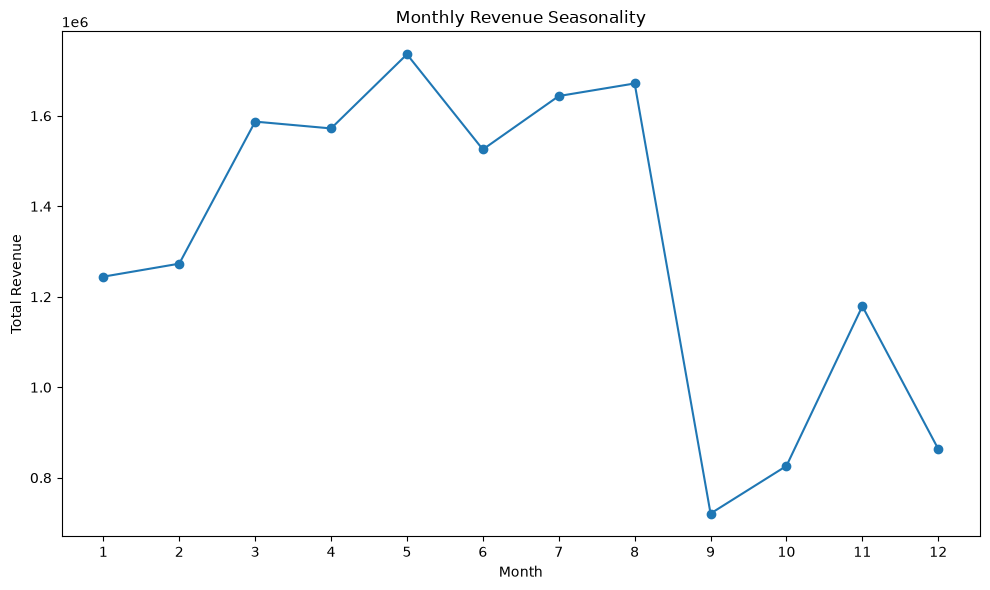

In [563]:
plt.figure(figsize=(10, 6))

plt.plot(
    seasonality_summary.index,
    seasonality_summary["total_revenue"],
    marker="o"
)

plt.title("Monthly Revenue Seasonality")
plt.xlabel("Month")
plt.ylabel("Total Revenue")

plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

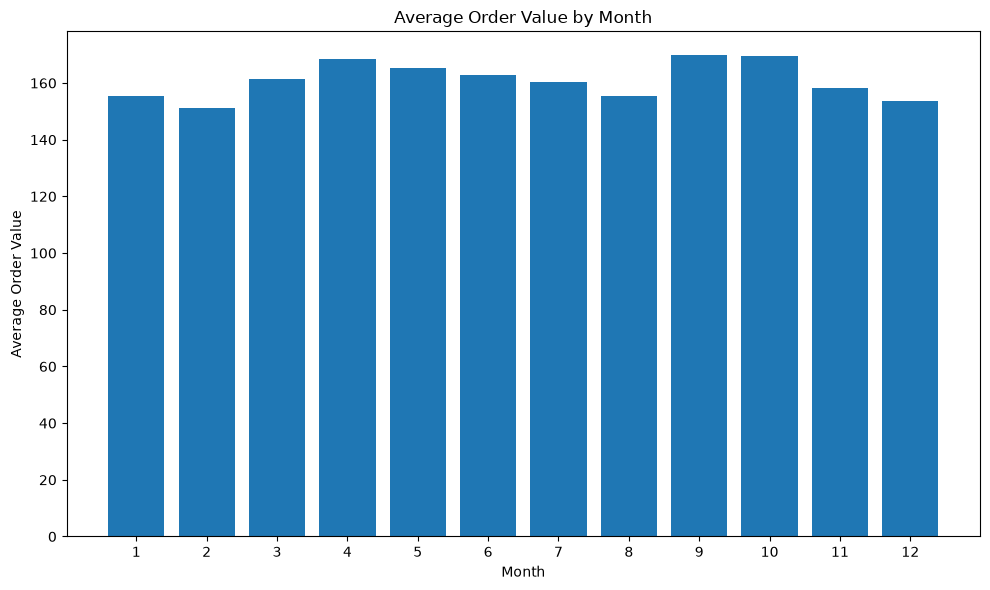

In [564]:
plt.figure(figsize=(10, 6))

plt.bar(
    seasonality_summary.index,
    seasonality_summary["avg_order_value"]
)

plt.title("Average Order Value by Month")
plt.xlabel("Month")
plt.ylabel("Average Order Value")

plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

In [565]:
print("Top 3 Months by Orders:")
display(
    seasonality_summary
    .sort_values("order_count", ascending=False)
    .head(3)
    .round(2)
)

print("\nTop 3 Months by Revenue:")
display(
    seasonality_summary
    .sort_values("total_revenue", ascending=False)
    .head(3)
    .round(2)
)

Top 3 Months by Orders:


,order_count,total_revenue,avg_order_value
month_num,,,
8,10745,1671513.07,155.56
5,10513,1735972.77,165.13
7,10242,1643699.65,160.49



Top 3 Months by Revenue:


,order_count,total_revenue,avg_order_value
month_num,,,
5,10513,1735972.77,165.13
8,10745,1671513.07,155.56
7,10242,1643699.65,160.49


### Monthly Seasonality — Business Insights

Monthly aggregation shows noticeable variation in customer demand and revenue
across calendar months.

May records the highest total revenue at approximately 1.74 million, while
August records the highest order volume with approximately 10,745 orders.

September shows the lowest order volume and revenue among the observed
calendar months. However, its average order value remains relatively high,
indicating that the lower revenue is primarily driven by lower order volume
rather than substantially smaller transactions.

Overall, revenue and order volume follow a broadly similar pattern, suggesting
that changes in transaction volume are a major driver of monthly revenue.

These results indicate potential seasonal patterns, although the dataset does
not contain equally complete observations for every calendar month across
multiple years. Therefore, the findings should be interpreted as observed
monthly patterns rather than definitive seasonal effects.

## 36. Year-over-Year Business Performance

### Business Question

How did the business perform across different years?

Annual revenue, order volume, and average order value are compared to
understand overall business growth and changes in transaction behavior.

In [566]:
yearly_revenue = monthly_revenue.copy()

yearly_revenue["year"] = (
    yearly_revenue["order_purchase_timestamp"]
    .dt.year
)

yearly_summary = (
    yearly_revenue
    .groupby("year")
    .agg(
        order_count=("order_id", "nunique"),
        total_revenue=("total_order_value", "sum"),
        avg_order_value=("total_order_value", "mean")
    )
    .sort_index()
)

yearly_summary.round(2)

,order_count,total_revenue,avg_order_value
year,,,
2016,312,57183.21,183.28
2017,44579,7142672.43,160.23
2018,53775,8643697.60,160.74


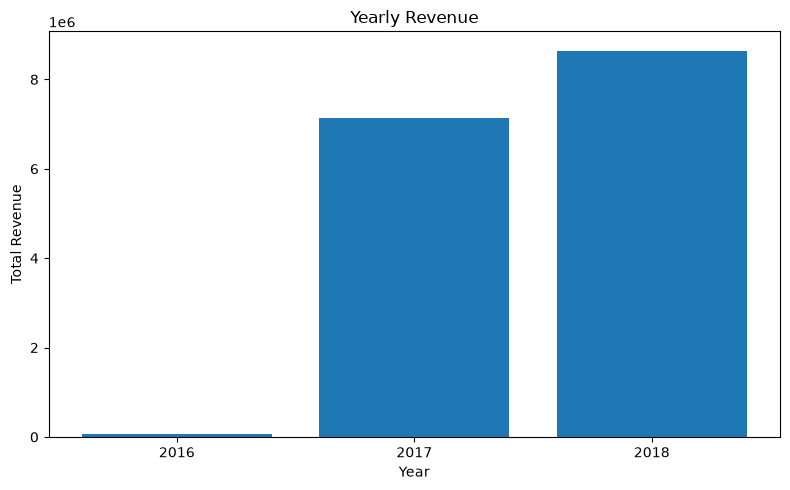

In [567]:
plt.figure(figsize=(8, 5))

plt.bar(
    yearly_summary.index.astype(str),
    yearly_summary["total_revenue"]
)

plt.title("Yearly Revenue")
plt.xlabel("Year")
plt.ylabel("Total Revenue")

plt.tight_layout()
plt.show()

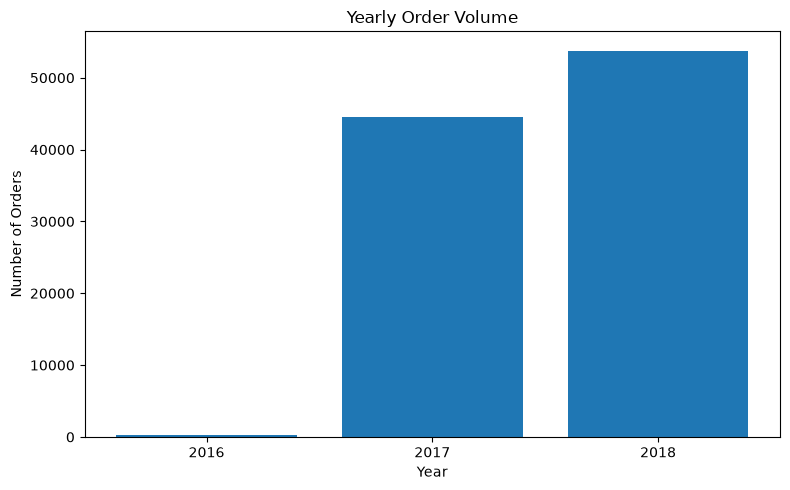

In [568]:
plt.figure(figsize=(8, 5))

plt.bar(
    yearly_summary.index.astype(str),
    yearly_summary["order_count"]
)

plt.title("Yearly Order Volume")
plt.xlabel("Year")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.show()

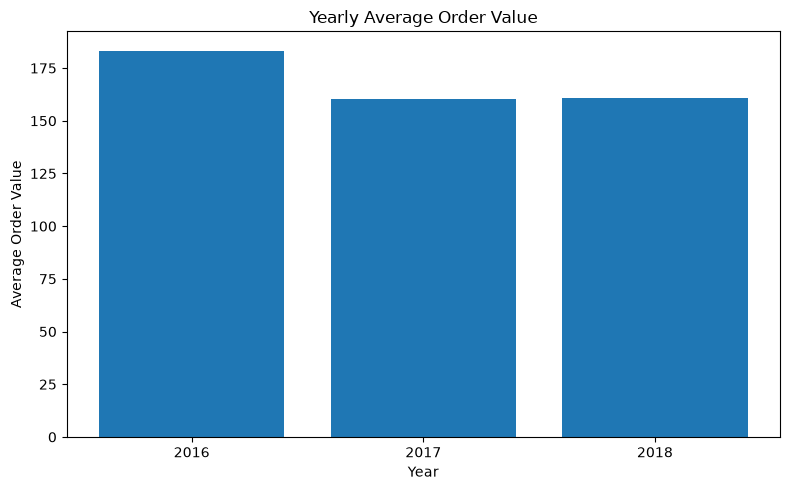

In [569]:
plt.figure(figsize=(8, 5))

plt.bar(
    yearly_summary.index.astype(str),
    yearly_summary["avg_order_value"]
)

plt.title("Yearly Average Order Value")
plt.xlabel("Year")
plt.ylabel("Average Order Value")

plt.tight_layout()
plt.show()

In [570]:
yearly_growth = yearly_summary.pct_change() * 100

yearly_growth.round(2)

,order_count,total_revenue,avg_order_value
year,,,
2016,NaN,NaN,NaN
2017,14188.14,12390.86,-12.58
2018,20.63,21.01,0.32


In [571]:
yearly_growth.rename(
    columns={
        "order_count": "Order Growth (%)",
        "total_revenue": "Revenue Growth (%)",
        "avg_order_value": "AOV Growth (%)"
    }
).round(2)

,Order Growth (%),Revenue Growth (%),AOV Growth (%)
year,,,
2016,NaN,NaN,NaN
2017,14188.14,12390.86,-12.58
2018,20.63,21.01,0.32


### Year-over-Year Performance — Business Insights

The business experienced strong expansion from 2017 to 2018.

Between 2017 and 2018, order volume increased by approximately 20.6%, while
total revenue increased by approximately 21.0%. Average Order Value increased
by only 0.3%, indicating that revenue growth was primarily driven by an
increase in the number of orders rather than a significant increase in
transaction value.

The extremely high growth percentages observed between 2016 and 2017 are
influenced by the very small revenue and order base in 2016 and should
therefore not be interpreted as normal business growth.

Overall, the 2017–2018 period indicates healthy volume-driven business
expansion with relatively stable customer spending per order.

## 37. New Customer Acquisition Trend

### Business Question

How did new customer acquisition change over time?

The number of unique customers placing their first order in each month is
analyzed to understand whether business growth was supported by increasing
customer acquisition.

In [572]:
customer_first_order = (
    orders_clean[
        ["order_id", "customer_id", "order_purchase_timestamp"]
    ]
    .sort_values("order_purchase_timestamp")
    .groupby("customer_id")
    .first()
    .reset_index()
)

customer_first_order["first_order_month"] = (
    pd.to_datetime(customer_first_order["order_purchase_timestamp"])
    .dt.to_period("M")
)

customer_first_order.head()

,customer_id,order_id,order_purchase_timestamp,first_order_month
0,00012a2ce6f8dcda20d059ce98491703,5f79b5b0931d63f1a42989eb65b9da6e,2017-11-14 16:08:26,2017-11
1,000161a058600d5901f007fab4c27140,a44895d095d7e0702b6a162fa2dbeced,2017-07-16 09:40:32,2017-07
2,0001fd6190edaaf884bcaf3d49edf079,316a104623542e4d75189bb372bc5f8d,2017-02-28 11:06:43,2017-02
3,0002414f95344307404f0ace7a26f1d5,5825ce2e88d5346438686b0bba99e5ee,2017-08-16 13:09:20,2017-08
4,000379cdec625522490c315e70c7a9fb,0ab7fb08086d4af9141453c91878ed7a,2018-04-02 13:42:17,2018-04


In [573]:
monthly_new_customers = (
    customer_first_order
    .groupby("first_order_month")
    .agg(
        new_customers=("customer_id", "nunique")
    )
)

monthly_new_customers.round(2)

,new_customers
first_order_month,
2016-09,4
2016-10,324
2016-12,1
2017-01,800
2017-02,1780
2017-03,2682
2017-04,2404
2017-05,3700
2017-06,3245


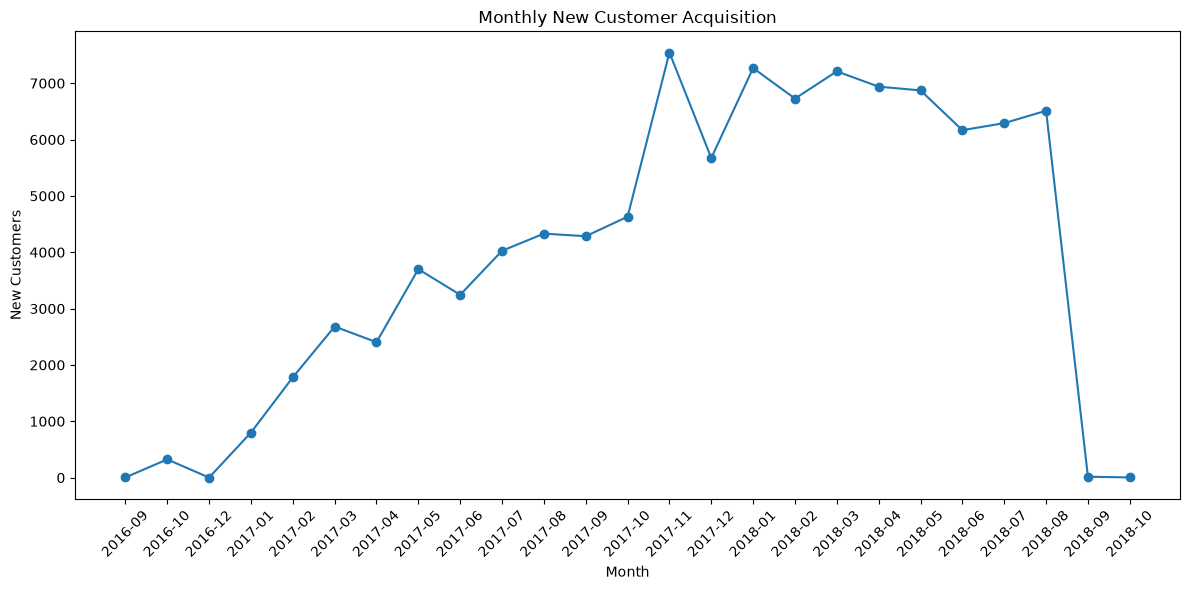

In [574]:
plt.figure(figsize=(12, 6))

plt.plot(
    monthly_new_customers.index.astype(str),
    monthly_new_customers["new_customers"],
    marker="o"
)

plt.title("Monthly New Customer Acquisition")
plt.xlabel("Month")
plt.ylabel("New Customers")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [575]:
yearly_new_customers = (
    customer_first_order
    .assign(
        year=customer_first_order["first_order_month"].dt.year
    )
    .groupby("year")
    .agg(
        new_customers=("customer_id", "nunique")
    )
)

yearly_new_customers.round(2)

,new_customers
year,
2016,329
2017,45101
2018,54011


### New Customer Acquisition — Business Insights

New customer acquisition shows strong growth throughout the observed period.

The business acquired approximately 45,101 new customers in 2017 and 54,011
new customers in 2018, representing approximately 19.8% growth in new
customer acquisition.

Monthly acquisition increased substantially during 2017 and remained at
relatively high levels throughout most of 2018. November 2017 recorded a
particularly strong acquisition level, with approximately 7,544 new
customers.

The sharp decline observed in September and October 2018 should be
interpreted cautiously because these appear to be incomplete or partial
periods in the dataset.

Overall, the increasing number of first-time customers supports the earlier
finding that business growth was strongly driven by increasing customer and
order volume.

## 38. Repeat vs One-Time Customers

### Business Question

How many customers make repeat purchases?

Customers are classified based on their total number of orders to understand
customer retention and repeat-purchase behavior.

In [576]:
customer_order_frequency = (
    orders_clean
    .groupby("customer_id")
    .agg(
        order_count=("order_id", "nunique")
    )
)

customer_order_frequency.head()

,order_count
customer_id,
00012a2ce6f8dcda20d059ce98491703,1
000161a058600d5901f007fab4c27140,1
0001fd6190edaaf884bcaf3d49edf079,1
0002414f95344307404f0ace7a26f1d5,1
000379cdec625522490c315e70c7a9fb,1


In [577]:
customer_order_frequency["customer_type"] = np.where(
    customer_order_frequency["order_count"] == 1,
    "One-time",
    "Repeat"
)

customer_order_frequency["customer_type"].value_counts()

customer_type
One-time    99441
Name: count, dtype: int64

In [578]:
customer_type_pct = (
    customer_order_frequency["customer_type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

customer_type_pct

customer_type
One-time    100.0
Name: proportion, dtype: float64

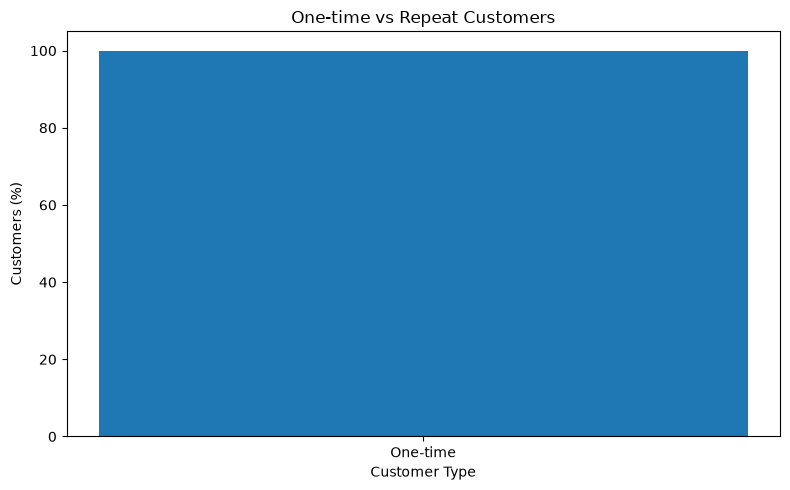

In [579]:
plt.figure(figsize=(8, 5))

plt.bar(
    customer_type_pct.index,
    customer_type_pct.values
)

plt.title("One-time vs Repeat Customers")
plt.xlabel("Customer Type")
plt.ylabel("Customers (%)")

plt.tight_layout()
plt.show()

In [581]:
customer_value = (
    order_revenue[
        ["order_id", "total_order_value"]
    ]
    .merge(
        orders_clean[
            ["order_id", "customer_id"]
        ],
        on="order_id",
        how="inner"
    )
    .merge(
        customer_order_frequency[
            ["customer_type"]
        ],
        left_on="customer_id",
        right_index=True,
        how="inner"
    )
)

customer_type_summary = (
    customer_value
    .groupby("customer_type")
    .agg(
        customers=("customer_id", "nunique"),
        orders=("order_id", "nunique"),
        total_revenue=("total_order_value", "sum"),
        avg_order_value=("total_order_value", "mean")
    )
)

customer_type_summary.round(2)

,customers,orders,total_revenue,avg_order_value
customer_type,,,,
One-time,98666,98666,15843553.24,160.58


In [582]:
customer_type_summary["revenue_share_pct"] = (
    customer_type_summary["total_revenue"]
    / customer_type_summary["total_revenue"].sum()
    * 100
)

customer_type_summary.round(2)

,customers,orders,total_revenue,avg_order_value,revenue_share_pct
customer_type,,,,,
One-time,98666,98666,15843553.24,160.58,100.0


In [583]:
customer_orders = (
    orders_clean[
        ["order_id", "customer_id"]
    ]
    .merge(
        customers_clean[
            ["customer_id", "customer_unique_id"]
        ],
        on="customer_id",
        how="left"
    )
)

customer_orders.head()

,order_id,customer_id,customer_unique_id
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,7c142cf63193a1473d2e66489a9ae977
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,72632f0f9dd73dfee390c9b22eb56dd6


In [587]:
customer_order_frequency = (
    customer_orders
    .groupby("customer_unique_id")
    .agg(
        order_count=("order_id", "nunique")
    )
)

customer_order_frequency["customer_type"] = np.where(
    customer_order_frequency["order_count"] == 1,
    "One-time",
    "Repeat"
)

customer_order_frequency["customer_type"].value_counts()

customer_type
One-time    93099
Repeat       2997
Name: count, dtype: int64

In [588]:
customer_type_pct = (
    customer_order_frequency["customer_type"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

customer_type_pct

customer_type
One-time    96.88
Repeat       3.12
Name: proportion, dtype: float64

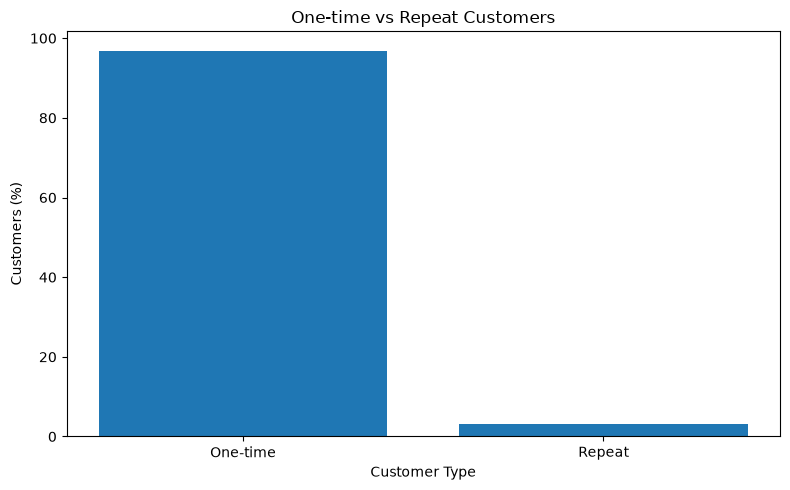

In [589]:
plt.figure(figsize=(8, 5))

plt.bar(
    customer_type_pct.index,
    customer_type_pct.values
)

plt.title("One-time vs Repeat Customers")
plt.xlabel("Customer Type")
plt.ylabel("Customers (%)")

plt.tight_layout()
plt.show()

In [590]:
customer_value = (
    order_revenue[
        ["order_id", "total_order_value"]
    ]
    .merge(
        customer_orders[
            ["order_id", "customer_unique_id"]
        ],
        on="order_id",
        how="inner"
    )
    .merge(
        customer_order_frequency[
            ["customer_type"]
        ],
        left_on="customer_unique_id",
        right_index=True,
        how="inner"
    )
)

customer_type_summary = (
    customer_value
    .groupby("customer_type")
    .agg(
        customers=("customer_unique_id", "nunique"),
        orders=("order_id", "nunique"),
        total_revenue=("total_order_value", "sum"),
        avg_order_value=("total_order_value", "mean")
    )
)

customer_type_summary["revenue_share_pct"] = (
    customer_type_summary["total_revenue"]
    / customer_type_summary["total_revenue"].sum()
    * 100
)

customer_type_summary.round(2)

,customers,orders,total_revenue,avg_order_value,revenue_share_pct
customer_type,,,,,
One-time,92431,92431,14921510.75,161.43,94.18
Repeat,2989,6235,922042.49,147.88,5.82


### Repeat vs One-Time Customers — Business Insights

The analysis shows that the customer base is heavily dominated by one-time
customers.

Approximately 96.88% of customers are one-time customers, while only 3.12%
are repeat customers.

Despite representing only 3.12% of customers, repeat customers contribute
5.82% of total revenue. This indicates that repeat customers generate a
disproportionately higher share of revenue relative to their customer share.

Repeat customers placed 6,235 orders across 2,989 customers, resulting in
approximately 2.09 orders per repeat customer.

Overall, the analysis highlights a significant customer retention opportunity.
Improving repeat purchase rates could potentially increase customer lifetime
value and strengthen long-term revenue generation.

## 39. Customer Order Frequency

### Business Question

How frequently do customers purchase from the business?

The distribution of orders per customer is analyzed to understand customer
purchase frequency and identify the concentration of one-time and repeat
purchasers.

In [591]:
order_frequency_distribution = (
    customer_order_frequency["order_count"]
    .value_counts()
    .sort_index()
)

order_frequency_distribution

order_count
1     93099
2      2745
3       203
4        30
5         8
6         6
7         3
9         1
17        1
Name: count, dtype: int64

In [592]:
order_frequency_pct = (
    order_frequency_distribution
    .div(order_frequency_distribution.sum())
    .mul(100)
    .round(2)
)

order_frequency_pct

order_count
1     96.88
2      2.86
3      0.21
4      0.03
5      0.01
6      0.01
7      0.00
9      0.00
17     0.00
Name: count, dtype: float64

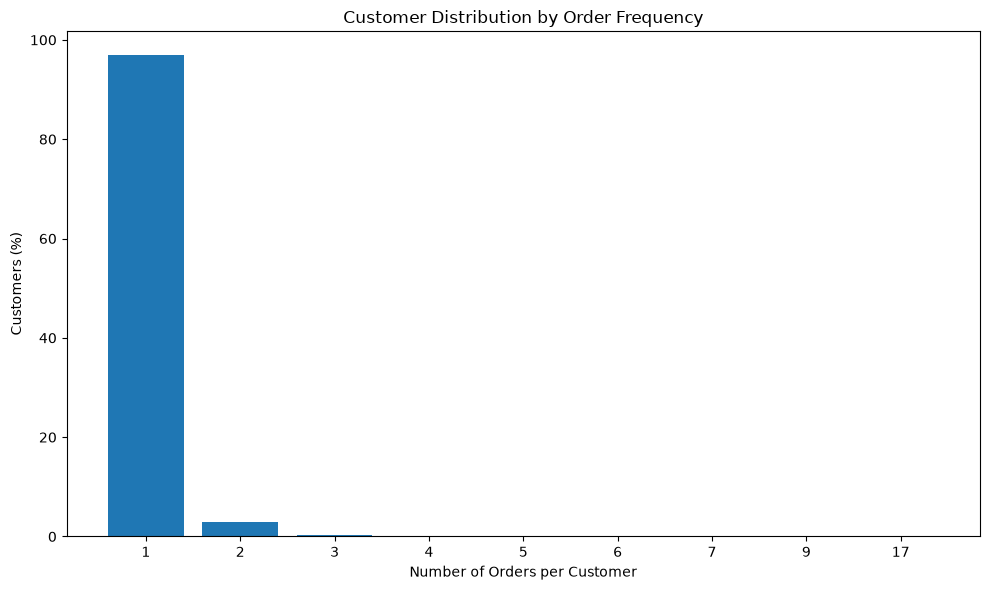

In [593]:
plt.figure(figsize=(10, 6))

plt.bar(
    order_frequency_pct.index.astype(str),
    order_frequency_pct.values
)

plt.title("Customer Distribution by Order Frequency")
plt.xlabel("Number of Orders per Customer")
plt.ylabel("Customers (%)")

plt.tight_layout()
plt.show()

### Customer Order Frequency — Business Insights

The customer order frequency distribution is highly concentrated around
one-time purchases.

Approximately 96.88% of customers placed only one order, while 2.86% placed
two orders. Customers placing three or more orders represent only a very
small proportion of the customer base.

This indicates that repeat purchasing is relatively uncommon and highlights
customer retention as a major business opportunity.

The most important retention objective would therefore be encouraging
one-time customers to make a second purchase, rather than focusing primarily
on increasing the purchase frequency of already highly active customers.

## 40. Customer Lifetime Value Analysis

### Business Question

Which customers generate the highest lifetime revenue?

Customer-level revenue and order behavior are analyzed to identify
high-value customers and understand the distribution of customer lifetime
value.

In [594]:
customer_ltv = (
    customer_value
    .groupby("customer_unique_id")
    .agg(
        order_count=("order_id", "nunique"),
        total_revenue=("total_order_value", "sum"),
        avg_order_value=("total_order_value", "mean")
    )
    .sort_values("total_revenue", ascending=False)
)

customer_ltv.head(15).round(2)

,order_count,total_revenue,avg_order_value
customer_unique_id,,,
0a0a92112bd4c708ca5fde585afaa872,1,13664.08,13664.08
da122df9eeddfedc1dc1f5349a1a690c,2,7571.63,3785.82
763c8b1c9c68a0229c42c9fc6f662b93,1,7274.88,7274.88
dc4802a71eae9be1dd28f5d788ceb526,1,6929.31,6929.31
459bef486812aa25204be022145caa62,1,6922.21,6922.21
ff4159b92c40ebe40454e3e6a7c35ed6,1,6726.66,6726.66
4007669dec559734d6f53e029e360987,1,6081.54,6081.54
5d0a2980b292d049061542014e8960bf,1,4809.44,4809.44
eebb5dda148d3893cdaf5b5ca3040ccb,1,4764.34,4764.34


In [595]:
customer_ltv["total_revenue"].describe().round(2)

count    95420.00
mean       166.04
std        228.32
min          9.59
25%         63.10
50%        107.94
75%        183.22
max      13664.08
Name: total_revenue, dtype: float64

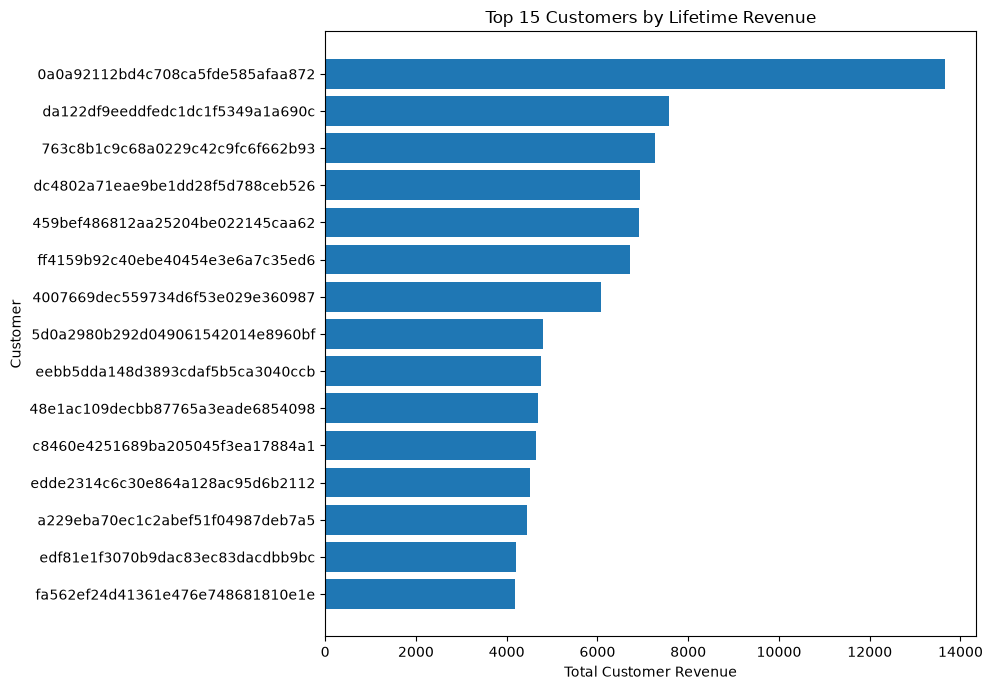

In [596]:
top_customers_ltv = (
    customer_ltv
    .head(15)
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_customers_ltv.index.astype(str),
    top_customers_ltv["total_revenue"]
)

plt.title("Top 15 Customers by Lifetime Revenue")
plt.xlabel("Total Customer Revenue")
plt.ylabel("Customer")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Customer Lifetime Revenue — Business Insights

Historical Customer Lifetime Revenue shows a highly right-skewed
distribution.

The average customer generated approximately 166.84 in historical revenue,
while the median customer generated approximately 107.94. The higher mean
compared with the median indicates that a relatively small number of
high-value customers contribute disproportionately more revenue.

The highest-value customer generated approximately 13,664 in historical
revenue, significantly exceeding the typical customer value.

This suggests that customer value is not evenly distributed and that
identifying and retaining high-value customers can be an important business
strategy.

Note: This analysis represents historical customer revenue and is not a
predictive Customer Lifetime Value model.

## 41. Customer Value Segmentation

### Business Question

How are customers distributed across different value segments?

Customers are segmented into Low, Medium-Low, Medium-High, and High Value
groups using historical customer revenue quartiles.

In [597]:
customer_segments = customer_ltv.copy()

customer_segments["value_segment"] = pd.qcut(
    customer_segments["total_revenue"],
    q=4,
    labels=[
        "Low Value",
        "Medium-Low",
        "Medium-High",
        "High Value"
    ]
)

customer_segments["value_segment"].value_counts().sort_index()

value_segment
Low Value      23879
Medium-Low     23834
Medium-High    23853
High Value     23854
Name: count, dtype: int64

In [598]:
segment_summary = (
    customer_segments
    .groupby("value_segment", observed=False)
    .agg(
        customers=("total_revenue", "count"),
        total_revenue=("total_revenue", "sum"),
        avg_revenue=("total_revenue", "mean"),
        avg_orders=("order_count", "mean")
    )
)

segment_summary["customer_share_pct"] = (
    segment_summary["customers"]
    / segment_summary["customers"].sum()
    * 100
)

segment_summary["revenue_share_pct"] = (
    segment_summary["total_revenue"]
    / segment_summary["total_revenue"].sum()
    * 100
)

segment_summary.round(2)

,customers,total_revenue,avg_revenue,avg_orders,customer_share_pct,revenue_share_pct
value_segment,,,,,,
Low Value,23879,1042251.30,43.65,1.00,25.03,6.58
Medium-Low,23834,1995000.09,83.70,1.01,24.98,12.59
Medium-High,23853,3371328.94,141.34,1.03,25.00,21.28
High Value,23854,9434972.91,395.53,1.09,25.00,59.55


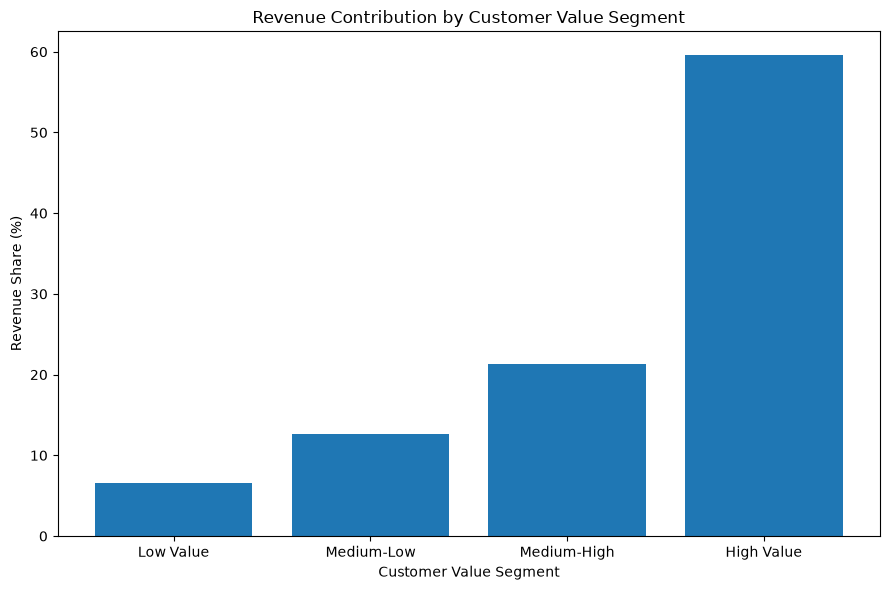

In [599]:
plt.figure(figsize=(9, 6))

plt.bar(
    segment_summary.index,
    segment_summary["revenue_share_pct"]
)

plt.title("Revenue Contribution by Customer Value Segment")
plt.xlabel("Customer Value Segment")
plt.ylabel("Revenue Share (%)")

plt.tight_layout()
plt.show()

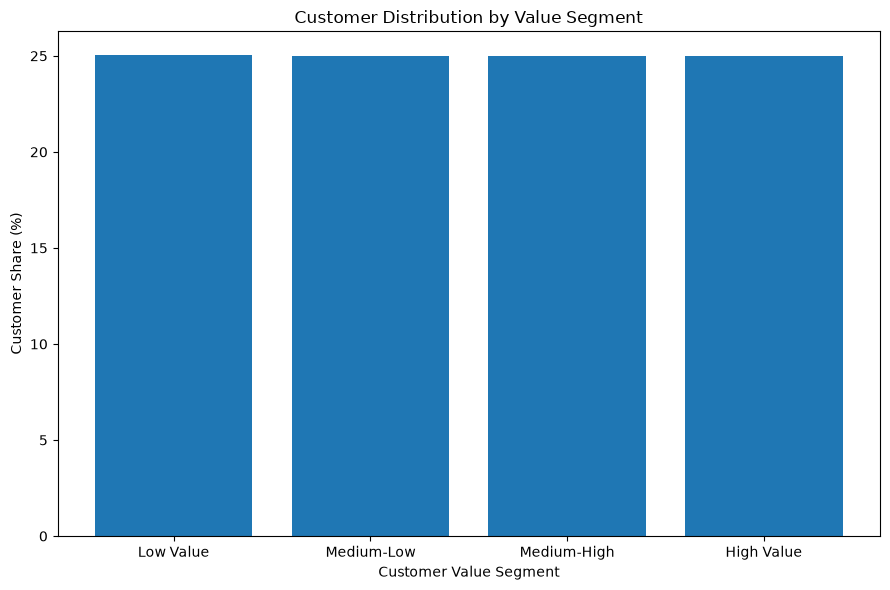

In [600]:
plt.figure(figsize=(9, 6))

plt.bar(
    segment_summary.index,
    segment_summary["customer_share_pct"]
)

plt.title("Customer Distribution by Value Segment")
plt.xlabel("Customer Value Segment")
plt.ylabel("Customer Share (%)")

plt.tight_layout()
plt.show()

### Customer Value Segmentation — Business Insights

Customer value is highly concentrated across the customer base.

Although each segment contains approximately 25% of customers, the High Value
segment contributes approximately 59.5% of total historical revenue.

In contrast, the Low Value segment represents approximately 25% of customers
but contributes only around 6.7% of revenue.

This indicates that customer value is highly unevenly distributed. High-value
customers therefore represent a strategically important segment and should be
prioritized for retention and personalized engagement.

The lower-value segments also represent an opportunity for targeted
upselling and conversion strategies to increase their future customer value.

## 42. RFM Customer Segmentation

### Business Question

Which customers are the most valuable, recently active, and frequent?

RFM analysis segments customers based on Recency, Frequency, and Monetary
value to identify high-value, loyal, and potentially at-risk customers.

In [604]:
rfm_data = (
    orders_clean[
        ["order_id", "customer_id", "order_purchase_timestamp"]
    ]
    .merge(
        customers_clean[
            ["customer_id", "customer_unique_id"]
        ],
        on="customer_id",
        how="left"
    )
    .merge(
        order_revenue[
            ["order_id", "total_order_value"]
        ],
        on="order_id",
        how="inner"
    )
)

rfm_data["order_purchase_timestamp"] = pd.to_datetime(
    rfm_data["order_purchase_timestamp"]
)

analysis_date = (
    rfm_data["order_purchase_timestamp"].max()
    + pd.Timedelta(days=1)
)

analysis_date

Timestamp('2018-09-04 09:06:57')

In [602]:
rfm = (
    rfm_data
    .groupby("customer_unique_id")
    .agg(
        recency=(
            "order_purchase_timestamp",
            lambda x: (analysis_date - x.max()).days
        ),
        frequency=("order_id", "nunique"),
        monetary=("total_order_value", "sum")
    )
)

rfm.head().round(2)

,recency,frequency,monetary
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,116,1,141.90
0000b849f77a49e4a4ce2b2a4ca5be3f,119,1,27.19
0000f46a3911fa3c0805444483337064,542,1,86.22
0000f6ccb0745a6a4b88665a16c9f078,326,1,43.62
0004aac84e0df4da2b147fca70cf8255,293,1,196.89


In [605]:
rfm["R_score"] = pd.qcut(
    rfm["recency"],
    q=4,
    labels=[4, 3, 2, 1],
    duplicates="drop"
)

rfm["F_score"] = pd.qcut(
    rfm["frequency"].rank(method="first"),
    q=4,
    labels=[1, 2, 3, 4]
)

rfm["M_score"] = pd.qcut(
    rfm["monetary"].rank(method="first"),
    q=4,
    labels=[1, 2, 3, 4]
)

rfm["RFM_score"] = (
    rfm["R_score"].astype(str)
    + rfm["F_score"].astype(str)
    + rfm["M_score"].astype(str)
)

rfm.head(10)

,recency,frequency,monetary,R_score,F_score,M_score,RFM_score
customer_unique_id,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,116,1,141.90,4,1,3,413
0000b849f77a49e4a4ce2b2a4ca5be3f,119,1,27.19,4,1,1,411
0000f46a3911fa3c0805444483337064,542,1,86.22,1,1,2,112
0000f6ccb0745a6a4b88665a16c9f078,326,1,43.62,2,1,1,211
0004aac84e0df4da2b147fca70cf8255,293,1,196.89,2,1,4,214
0004bd2a26a76fe21f786e4fbd80607f,151,1,166.98,3,1,3,313
00050ab1314c0e55a6ca13cf7181fecf,136,1,35.38,3,1,1,311
00053a61a98854899e70ed204dd4bafe,187,1,419.18,3,1,4,314
0005e1862207bf6ccc02e4228effd9a0,548,1,150.12,1,1,3,113



## RFM Customer Segmentation

RFM scores are converted into meaningful customer segments to identify
high-value, loyal, recent, and at-risk customers.

In [606]:
rfm["RFM_total"] = (
    rfm["R_score"].astype(int)
    + rfm["F_score"].astype(int)
    + rfm["M_score"].astype(int)
)

rfm["segment"] = np.select(
    [
        rfm["RFM_total"] >= 10,
        rfm["RFM_total"] >= 8,
        rfm["RFM_total"] >= 6
    ],
    [
        "Champions",
        "Loyal Customers",
        "Potential Customers"
    ],
    default="At Risk / Low Value"
)

rfm["segment"].value_counts()

segment
Potential Customers    32624
Loyal Customers        31850
Champions              15542
At Risk / Low Value    15404
Name: count, dtype: int64

In [607]:
rfm_segment_pct = (
    rfm["segment"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

rfm_segment_pct

segment
Potential Customers    34.19
Loyal Customers        33.38
Champions              16.29
At Risk / Low Value    16.14
Name: proportion, dtype: float64

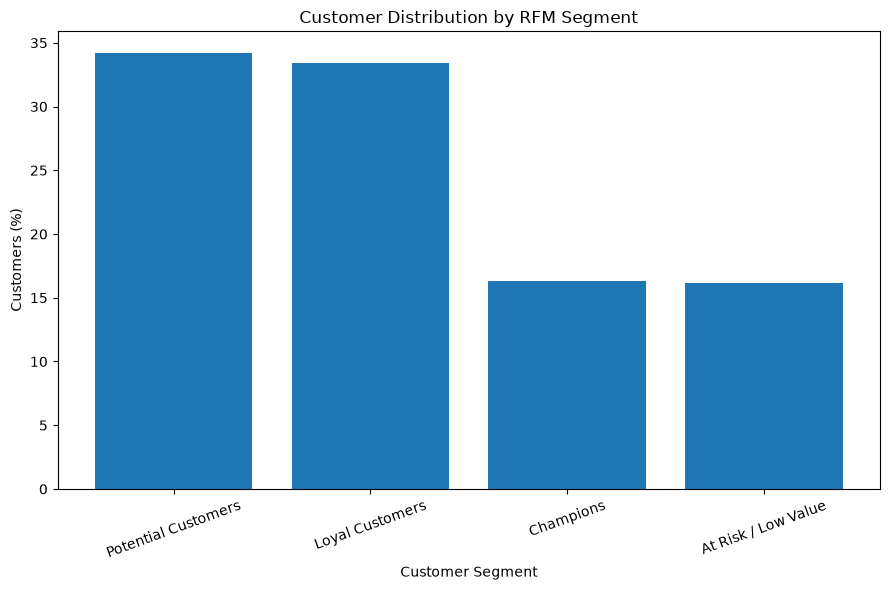

In [608]:
plt.figure(figsize=(9, 6))

plt.bar(
    rfm_segment_pct.index,
    rfm_segment_pct.values
)

plt.title("Customer Distribution by RFM Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Customers (%)")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

### RFM Segmentation — Business Insights

RFM analysis divides customers into four segments: Potential Customers,
Loyal Customers, Champions, and At Risk / Low Value customers.

Potential Customers form the largest segment at approximately 34.19%,
followed by Loyal Customers at 33.38%.

Champions account for approximately 16.29% of customers, while 16.14% fall
into the At Risk / Low Value segment.

Overall, nearly half of the customer base belongs to the Loyal or Champions
segments, indicating a substantial group of engaged customers.

The large Potential Customer segment represents an opportunity for targeted
engagement and conversion into repeat and loyal customers. Meanwhile,
At Risk / Low Value customers can be targeted through reactivation and
retention campaigns.

## 43. RFM Segment Revenue Contribution

### Business Question

Which RFM customer segments contribute the most revenue?

Revenue contribution is compared across RFM customer segments to identify
which customer groups have the greatest financial importance.

In [609]:
rfm_revenue_summary = (
    rfm
    .groupby("segment")
    .agg(
        customers=("monetary", "count"),
        total_revenue=("monetary", "sum"),
        avg_revenue=("monetary", "mean")
    )
)

rfm_revenue_summary["customer_share_pct"] = (
    rfm_revenue_summary["customers"]
    / rfm_revenue_summary["customers"].sum()
    * 100
)

rfm_revenue_summary["revenue_share_pct"] = (
    rfm_revenue_summary["total_revenue"]
    / rfm_revenue_summary["total_revenue"].sum()
    * 100
)

rfm_revenue_summary = (
    rfm_revenue_summary
    .sort_values("total_revenue", ascending=False)
)

rfm_revenue_summary.round(2)

,customers,total_revenue,avg_revenue,customer_share_pct,revenue_share_pct
segment,,,,,
Loyal Customers,31850,6175457.53,193.89,33.38,38.98
Champions,15542,4573596.79,294.27,16.29,28.87
Potential Customers,32624,4093380.16,125.47,34.19,25.84
At Risk / Low Value,15404,1001118.76,64.99,16.14,6.32


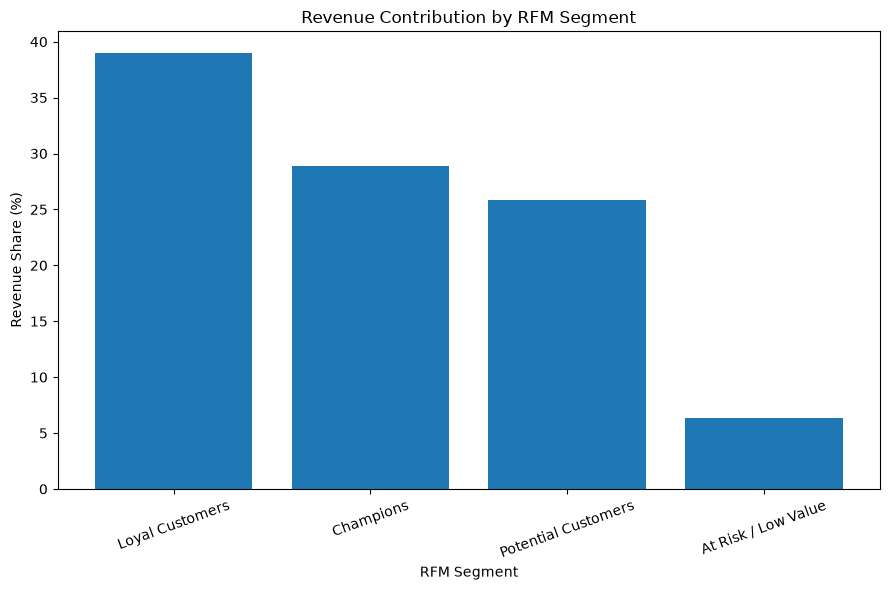

In [610]:
plt.figure(figsize=(9, 6))

plt.bar(
    rfm_revenue_summary.index,
    rfm_revenue_summary["revenue_share_pct"]
)

plt.title("Revenue Contribution by RFM Segment")
plt.xlabel("RFM Segment")
plt.ylabel("Revenue Share (%)")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

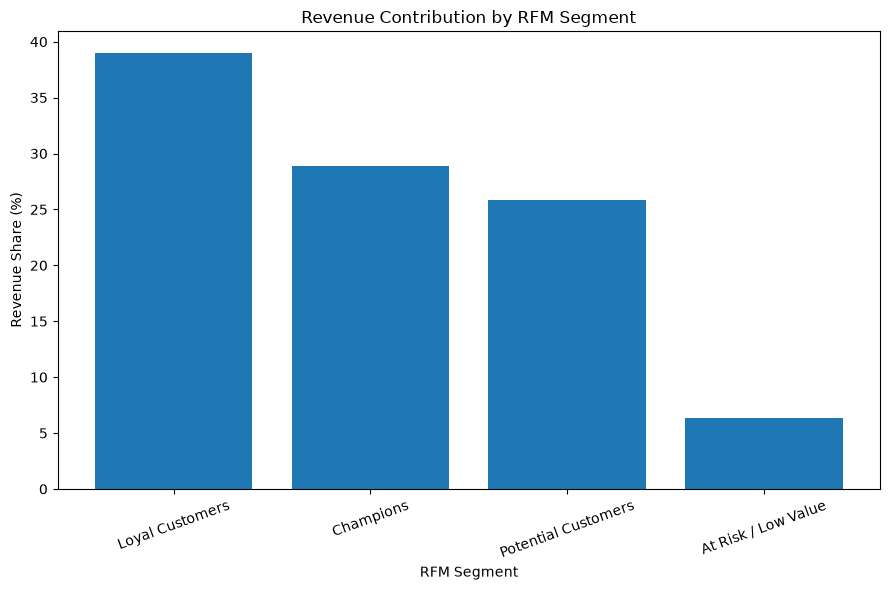

In [611]:
plt.figure(figsize=(9, 6))

plt.bar(
    rfm_revenue_summary.index,
    rfm_revenue_summary["revenue_share_pct"]
)

plt.title("Revenue Contribution by RFM Segment")
plt.xlabel("RFM Segment")
plt.ylabel("Revenue Share (%)")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

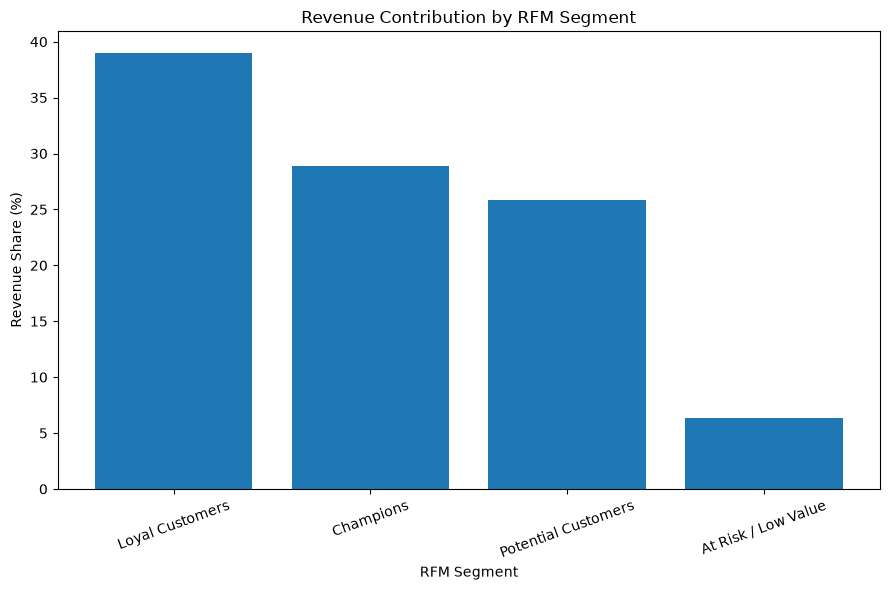

In [612]:
plt.figure(figsize=(9, 6))

plt.bar(
    rfm_revenue_summary.index,
    rfm_revenue_summary["revenue_share_pct"]
)

plt.title("Revenue Contribution by RFM Segment")
plt.xlabel("RFM Segment")
plt.ylabel("Revenue Share (%)")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

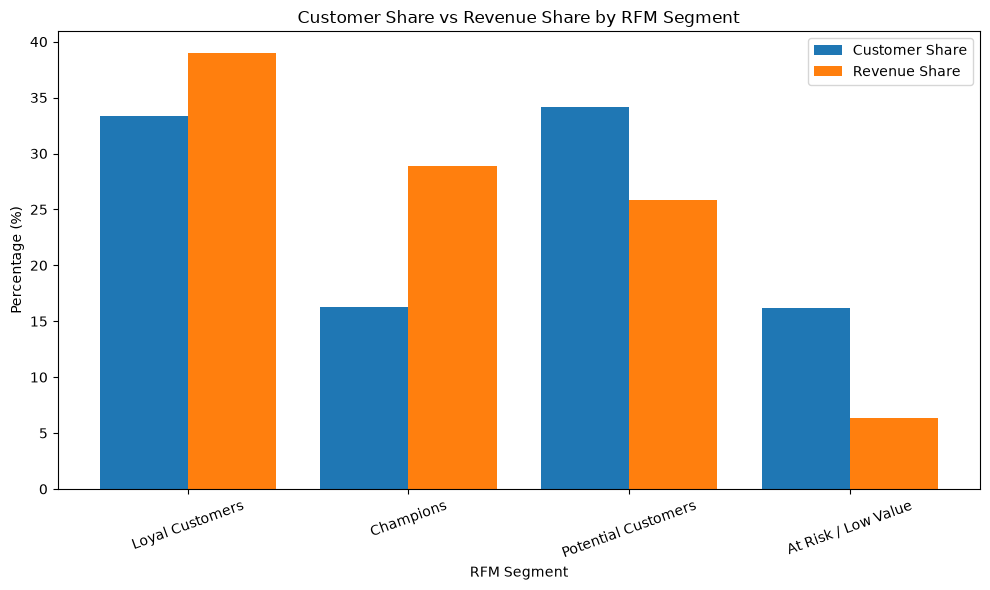

In [613]:
x = np.arange(len(rfm_revenue_summary))

plt.figure(figsize=(10, 6))

plt.bar(
    x - 0.2,
    rfm_revenue_summary["customer_share_pct"],
    width=0.4,
    label="Customer Share"
)

plt.bar(
    x + 0.2,
    rfm_revenue_summary["revenue_share_pct"],
    width=0.4,
    label="Revenue Share"
)

plt.xticks(
    x,
    rfm_revenue_summary.index,
    rotation=20
)

plt.title("Customer Share vs Revenue Share by RFM Segment")
plt.xlabel("RFM Segment")
plt.ylabel("Percentage (%)")

plt.legend()
plt.tight_layout()
plt.show()

### RFM Segment Revenue Contribution — Business Insights

Revenue contribution varies substantially across RFM customer segments.

Loyal Customers represent 33.38% of the customer base but contribute 38.98%
of total revenue. Champions account for only 16.29% of customers while
generating 28.87% of revenue.

Together, Loyal Customers and Champions represent approximately 49.67% of
customers but contribute approximately 67.85% of total revenue.

Potential Customers form the largest segment at 34.19% of customers and
contribute 25.84% of revenue, making them an important growth opportunity.

At Risk / Low Value customers represent 16.14% of customers but contribute
only 6.32% of revenue.

Overall, the analysis shows that revenue is concentrated among engaged
customers. Retaining Champions and Loyal Customers while converting
Potential Customers into higher-value segments should be key priorities.

## 44. RFM Segment vs Delivery Performance

### Business Question

Do high-value customer segments experience better delivery performance?

Average delivery time is compared across RFM customer segments to determine
whether valuable customers experience different delivery performance.

In [615]:
rfm_delivery = (
    rfm[
        ["segment"]
    ]
    .merge(
        rfm_data[
            ["customer_unique_id", "order_id"]
        ],
        left_index=True,
        right_on="customer_unique_id",
        how="inner"
    )
    .merge(
        orders_clean[
            ["order_id", "delivery_time_days"]
        ],
        on="order_id",
        how="inner"
    )
)

In [616]:
rfm_delivery_summary = (
    rfm_delivery
    .groupby("segment")
    .agg(
        customers=("customer_unique_id", "nunique"),
        orders=("order_id", "nunique"),
        avg_delivery_days=("delivery_time_days", "mean"),
        median_delivery_days=("delivery_time_days", "median")
    )
    .sort_values("avg_delivery_days")
)

rfm_delivery_summary.round(2)

,customers,orders,avg_delivery_days,median_delivery_days
segment,,,,
At Risk / Low Value,15404,15404,12.15,10.18
Champions,15542,17763,12.37,9.95
Potential Customers,32624,32725,12.60,10.37
Loyal Customers,31850,32774,12.81,10.29


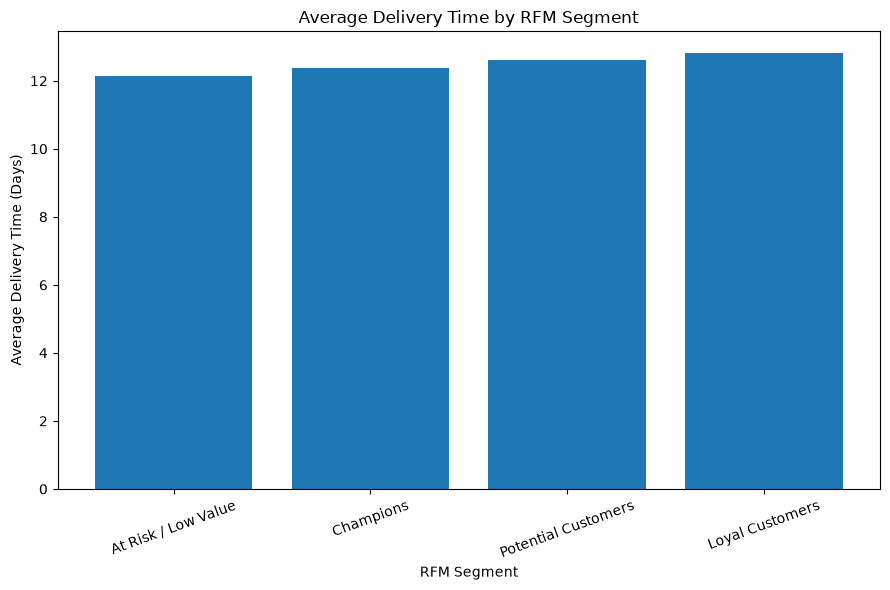

In [617]:
plt.figure(figsize=(9, 6))

plt.bar(
    rfm_delivery_summary.index,
    rfm_delivery_summary["avg_delivery_days"]
)

plt.title("Average Delivery Time by RFM Segment")
plt.xlabel("RFM Segment")
plt.ylabel("Average Delivery Time (Days)")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

### RFM Segment vs Delivery Performance — Business Insights

Average delivery time is relatively similar across all RFM segments,
ranging from approximately 12.15 to 12.81 days.

Champions have an average delivery time of 12.37 days, while Loyal Customers
have the highest average delivery time at 12.81 days.

This indicates that high-value customers do not systematically receive faster
deliveries than other customer segments.

However, the relatively small difference in delivery times suggests that
delivery speed alone may not explain customer value. Other factors such as
product experience, pricing, product selection, and customer satisfaction may
also influence customer retention and value.

## 45. RFM Segment vs Customer Satisfaction

### Business Question

Do higher-value customer segments provide better review scores?

Average customer review scores are compared across RFM segments to examine
the relationship between customer value and satisfaction.

In [618]:
rfm_reviews = (
    rfm[
        ["segment"]
    ]
    .merge(
        rfm_data[
            ["customer_unique_id", "order_id"]
        ],
        left_index=True,
        right_on="customer_unique_id",
        how="inner"
    )
    .merge(
        order_reviews_clean[
            ["order_id", "review_score"]
        ],
        on="order_id",
        how="inner"
    )
)

In [619]:
rfm_review_summary = (
    rfm_reviews
    .groupby("segment")
    .agg(
        customers=("customer_unique_id", "nunique"),
        reviews=("review_score", "count"),
        avg_review_score=("review_score", "mean"),
        median_review_score=("review_score", "median")
    )
    .sort_values("avg_review_score", ascending=False)
)

rfm_review_summary.round(2)

,customers,reviews,avg_review_score,median_review_score
segment,,,,
At Risk / Low Value,15293,15314,4.17,5.0
Potential Customers,32375,32538,4.12,5.0
Champions,15437,17844,4.10,5.0
Loyal Customers,31616,32769,4.07,5.0


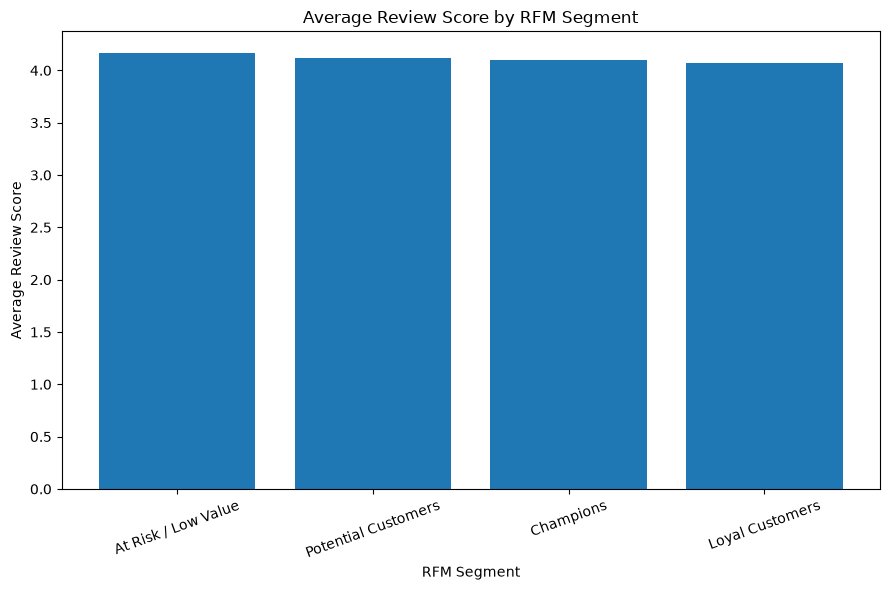

In [620]:
plt.figure(figsize=(9, 6))

plt.bar(
    rfm_review_summary.index,
    rfm_review_summary["avg_review_score"]
)

plt.title("Average Review Score by RFM Segment")
plt.xlabel("RFM Segment")
plt.ylabel("Average Review Score")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

### RFM Segment vs Customer Satisfaction — Business Insights

Average review scores are relatively similar across all RFM segments,
ranging from approximately 4.07 to 4.17.

At Risk / Low Value customers have the highest average review score at 4.17,
while Loyal Customers have the lowest at 4.07.

The small difference in review scores suggests that customer value and
customer satisfaction are not strongly differentiated across the RFM
segments.

Therefore, customer value appears to be influenced by factors beyond review
satisfaction alone, such as purchase behavior, product selection, pricing,
and customer retention.

In [621]:
rfm_aov_summary = (
    rfm
    .merge(
        customer_ltv[
            ["avg_order_value"]
        ],
        left_index=True,
        right_index=True,
        how="left"
    )
    .groupby("segment")
    .agg(
        customers=("monetary", "count"),
        avg_order_value=("avg_order_value", "mean"),
        median_order_value=("avg_order_value", "median"),
        total_revenue=("monetary", "sum")
    )
    .sort_values("avg_order_value", ascending=False)
)

rfm_aov_summary.round(2)

,customers,avg_order_value,median_order_value,total_revenue
segment,,,,
Champions,15542,270.86,194.00,4573596.79
Loyal Customers,31850,190.47,133.18,6175457.53
Potential Customers,32624,125.36,85.40,4093380.16
At Risk / Low Value,15404,64.99,56.78,1001118.76


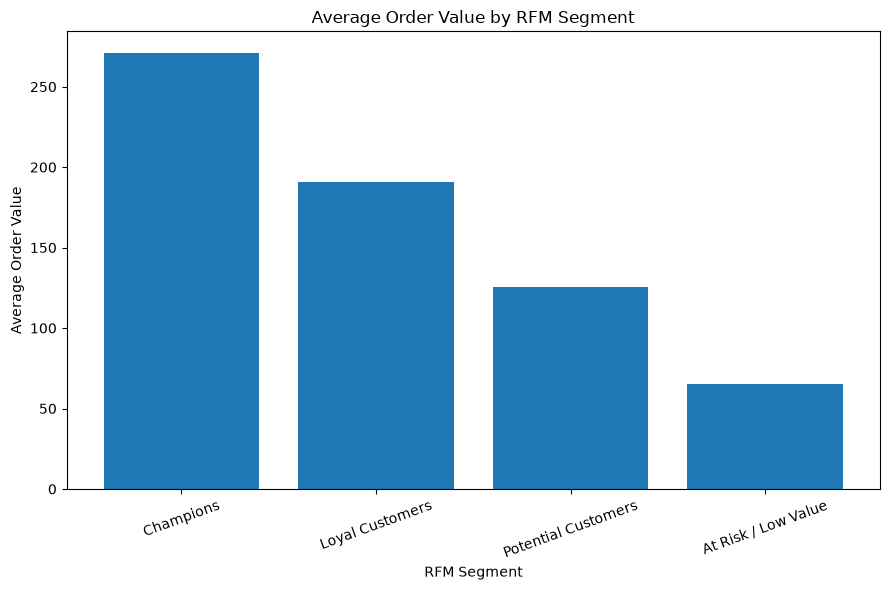

In [622]:
plt.figure(figsize=(9, 6))

plt.bar(
    rfm_aov_summary.index,
    rfm_aov_summary["avg_order_value"]
)

plt.title("Average Order Value by RFM Segment")
plt.xlabel("RFM Segment")
plt.ylabel("Average Order Value")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

### RFM Segment vs Average Order Value — Business Insights

Average Order Value differs substantially across RFM customer segments.

Champions have the highest average order value at approximately 270.86,
followed by Loyal Customers at 190.47, Potential Customers at 125.36, and
At Risk / Low Value customers at 64.99.

Champions therefore have an average order value more than four times that of
At Risk / Low Value customers.

The consistent decline in average order value across the RFM segments
indicates that higher-value customer segments are also associated with
substantially higher spending per order.

This reinforces the importance of retaining Champions and Loyal Customers,
while also highlighting the opportunity to increase spending among Potential
Customers through targeted upselling and engagement strategies.

## 47. Customer Value vs Delivery Time

### Business Question

Is there a relationship between customer spending and delivery performance?

Customer-level historical revenue is compared with average delivery time to
determine whether higher-value customers generally experience faster or
slower deliveries.

In [623]:
customer_delivery = (
    rfm[
        ["monetary"]
    ]
    .merge(
        rfm_delivery
        .groupby("customer_unique_id")
        .agg(
            avg_delivery_days=("delivery_time_days", "mean")
        ),
        left_index=True,
        right_index=True,
        how="inner"
    )
)

customer_delivery.head().round(2)

,monetary,avg_delivery_days
customer_unique_id,,
0000366f3b9a7992bf8c76cfdf3221e2,141.90,6.41
0000b849f77a49e4a4ce2b2a4ca5be3f,27.19,3.29
0000f46a3911fa3c0805444483337064,86.22,25.73
0000f6ccb0745a6a4b88665a16c9f078,43.62,20.04
0004aac84e0df4da2b147fca70cf8255,196.89,13.14


In [624]:
correlation = (
    customer_delivery["monetary"]
    .corr(customer_delivery["avg_delivery_days"])
)

print("Correlation between Customer Revenue and Delivery Time:",
      round(correlation, 3))

Correlation between Customer Revenue and Delivery Time: 0.069


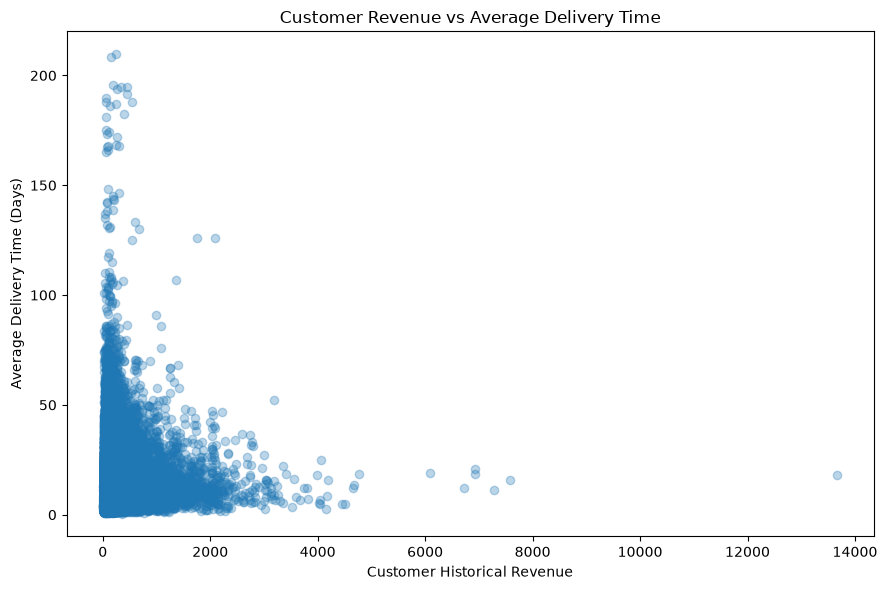

In [625]:
plt.figure(figsize=(9, 6))

plt.scatter(
    customer_delivery["monetary"],
    customer_delivery["avg_delivery_days"],
    alpha=0.3
)

plt.title("Customer Revenue vs Average Delivery Time")
plt.xlabel("Customer Historical Revenue")
plt.ylabel("Average Delivery Time (Days)")

plt.tight_layout()
plt.show()

### Customer Value vs Delivery Time — Business Insights

The correlation between customer historical revenue and average delivery
time is approximately 0.069, indicating a very weak positive relationship.

The scatter plot also shows a highly dispersed distribution with no clear
linear pattern between customer revenue and delivery time.

Therefore, higher-value customers do not systematically experience faster or
slower deliveries.

This suggests that delivery time alone does not strongly explain differences
in customer value. Other factors such as purchase frequency, product
selection, pricing, and customer experience are likely to play a more
important role.

## 48. Customer Value vs Review Score

### Business Question

Is there a relationship between customer spending and customer satisfaction?

Customer historical revenue is compared with average review score to
determine whether higher-value customers tend to provide better or worse
reviews.

In [626]:
customer_review = (
    rfm[
        ["monetary"]
    ]
    .merge(
        rfm_reviews
        .groupby("customer_unique_id")
        .agg(
            avg_review_score=("review_score", "mean")
        ),
        left_index=True,
        right_index=True,
        how="inner"
    )
)

customer_review.head().round(2)

,monetary,avg_review_score
customer_unique_id,,
0000366f3b9a7992bf8c76cfdf3221e2,141.90,5.0
0000b849f77a49e4a4ce2b2a4ca5be3f,27.19,4.0
0000f46a3911fa3c0805444483337064,86.22,3.0
0000f6ccb0745a6a4b88665a16c9f078,43.62,4.0
0004aac84e0df4da2b147fca70cf8255,196.89,5.0


In [627]:
review_correlation = (
    customer_review["monetary"]
    .corr(customer_review["avg_review_score"])
)

print(
    "Correlation between Customer Revenue and Review Score:",
    round(review_correlation, 3)
)

Correlation between Customer Revenue and Review Score: -0.045


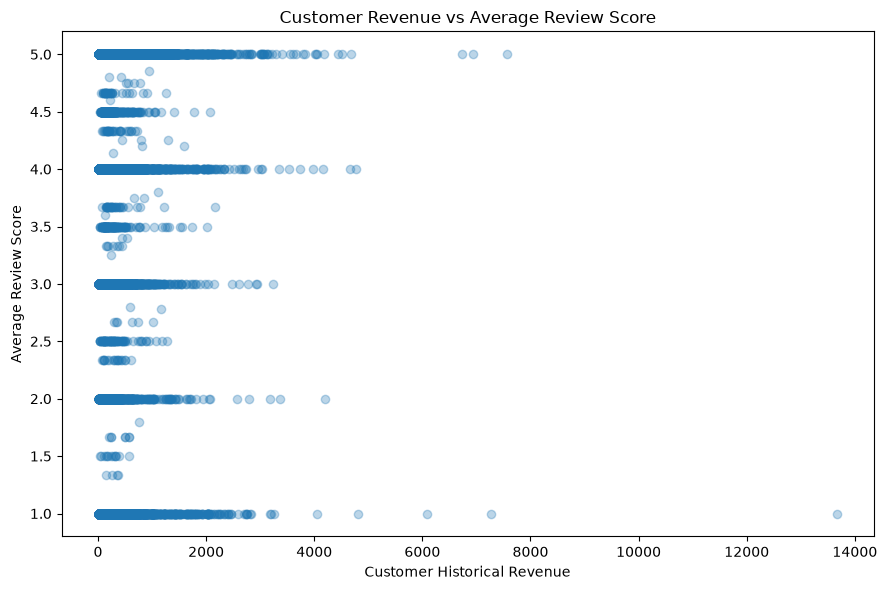

In [628]:
plt.figure(figsize=(9, 6))

plt.scatter(
    customer_review["monetary"],
    customer_review["avg_review_score"],
    alpha=0.3
)

plt.title("Customer Revenue vs Average Review Score")
plt.xlabel("Customer Historical Revenue")
plt.ylabel("Average Review Score")

plt.tight_layout()
plt.show()

### Customer Value vs Review Score — Business Insights

The correlation between customer historical revenue and average review score
is approximately -0.045, indicating an almost negligible linear relationship.

The scatter plot also shows no clear pattern between customer spending and
review scores.

Therefore, higher-spending customers do not systematically provide higher or
lower review scores.

This suggests that customer monetary value and review-based satisfaction are
largely independent in this dataset. Other factors such as purchase
frequency, product selection, pricing, and customer behavior may have a
greater influence on customer value.

## 49. Customer Revenue Distribution

### Business Question

How is historical revenue distributed across customers?

The distribution of customer-level historical revenue is analyzed to
understand typical customer value and identify high-value outliers.

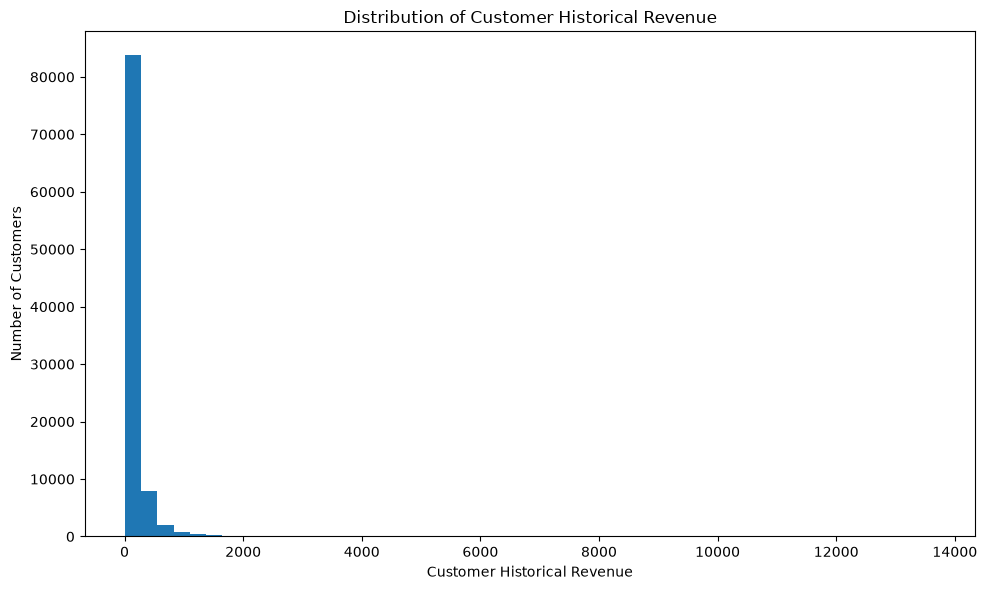

In [629]:
plt.figure(figsize=(10, 6))

plt.hist(
    customer_ltv["total_revenue"],
    bins=50
)

plt.title("Distribution of Customer Historical Revenue")
plt.xlabel("Customer Historical Revenue")
plt.ylabel("Number of Customers")

plt.tight_layout()
plt.show()

C:\Users\ASUS\AppData\Local\Temp\ipykernel_14896\437657909.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(


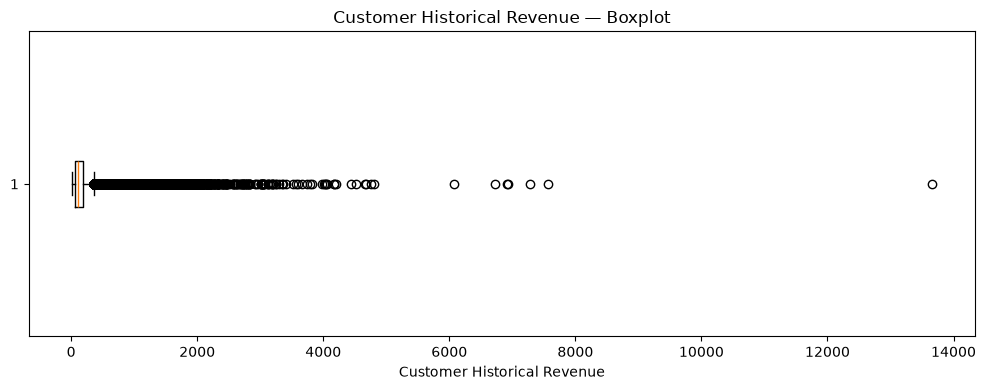

In [630]:
plt.figure(figsize=(10, 4))

plt.boxplot(
    customer_ltv["total_revenue"],
    vert=False
)

plt.title("Customer Historical Revenue — Boxplot")
plt.xlabel("Customer Historical Revenue")

plt.tight_layout()
plt.show()

### Customer Revenue Distribution — Business Insights

Customer historical revenue is highly right-skewed.

Most customers generate relatively low historical revenue, while a small
number of customers generate substantially higher revenue.

The boxplot also identifies numerous high-value customers as outliers,
including a few extreme customers with historical revenue above 10,000.

This indicates that customer value is highly concentrated and that a small
group of high-value customers contributes disproportionately to overall
revenue.

Therefore, median values, customer segmentation, and percentile-based
analysis are more informative than relying only on the mean customer revenue.

## 50. Customer Order Frequency vs Revenue

### Business Question

Does purchasing more frequently lead to higher customer revenue?

Customer order frequency is compared with historical customer revenue to
understand whether repeat purchasing is associated with higher customer
value.

In [631]:
customer_frequency_revenue = (
    customer_order_frequency[
        ["order_count"]
    ]
    .merge(
        customer_ltv[
            ["total_revenue"]
        ],
        left_index=True,
        right_index=True,
        how="inner"
    )
)

customer_frequency_revenue.head().round(2)

,order_count,total_revenue
customer_unique_id,,
0000366f3b9a7992bf8c76cfdf3221e2,1,141.90
0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19
0000f46a3911fa3c0805444483337064,1,86.22
0000f6ccb0745a6a4b88665a16c9f078,1,43.62
0004aac84e0df4da2b147fca70cf8255,1,196.89


In [632]:
frequency_revenue_corr = (
    customer_frequency_revenue["order_count"]
    .corr(customer_frequency_revenue["total_revenue"])
)

print(
    "Correlation between Order Frequency and Customer Revenue:",
    round(frequency_revenue_corr, 3)
)

Correlation between Order Frequency and Customer Revenue: 0.122


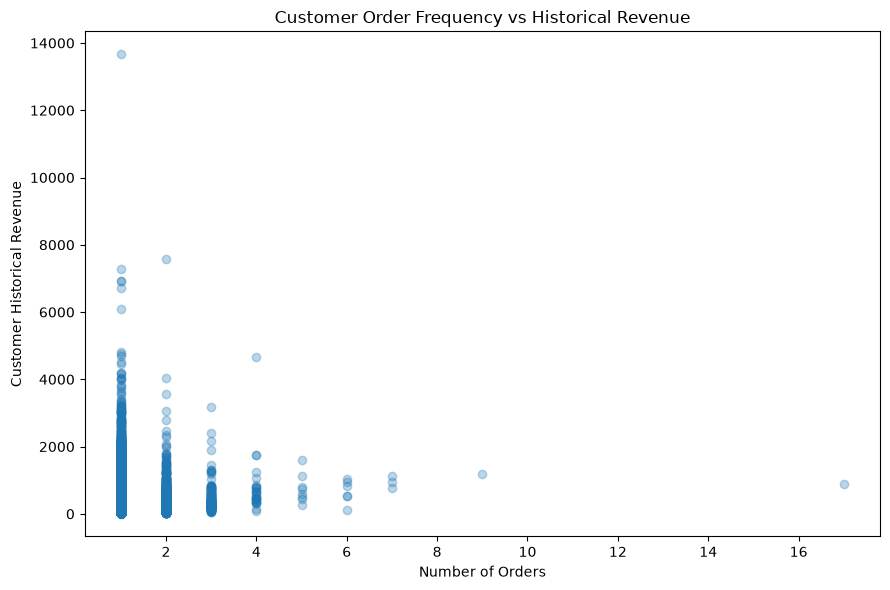

In [633]:
plt.figure(figsize=(9, 6))

plt.scatter(
    customer_frequency_revenue["order_count"],
    customer_frequency_revenue["total_revenue"],
    alpha=0.3
)

plt.title("Customer Order Frequency vs Historical Revenue")
plt.xlabel("Number of Orders")
plt.ylabel("Customer Historical Revenue")

plt.tight_layout()
plt.show()

### Customer Order Frequency vs Revenue — Business Insights

The correlation between customer order frequency and historical revenue is
approximately 0.122, indicating a weak positive relationship.

Although customers with more orders tend to generate somewhat higher revenue,
the relationship is not strong.

The scatter plot shows that most customers have only one order, while a small
number of customers make multiple purchases. Some one-time customers also
generate relatively high revenue due to higher-value orders.

Therefore, order frequency alone does not strongly explain customer revenue.
Customer value is better understood by considering purchasing frequency
together with monetary value and recency, which supports the use of RFM
segmentation.

## 51. Order Frequency vs Average Order Value

### Business Question

Is there a relationship between customer purchase frequency and average
order value?

Customer order frequency is compared with average order value to understand
whether repeat purchasing is associated with larger or smaller orders.

In [634]:
customer_frequency_aov = (
    customer_order_frequency[
        ["order_count"]
    ]
    .merge(
        customer_ltv[
            ["avg_order_value"]
        ],
        left_index=True,
        right_index=True,
        how="inner"
    )
)

customer_frequency_aov.head().round(2)

,order_count,avg_order_value
customer_unique_id,,
0000366f3b9a7992bf8c76cfdf3221e2,1,141.90
0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19
0000f46a3911fa3c0805444483337064,1,86.22
0000f6ccb0745a6a4b88665a16c9f078,1,43.62
0004aac84e0df4da2b147fca70cf8255,1,196.89


In [635]:
frequency_aov_corr = (
    customer_frequency_aov["order_count"]
    .corr(customer_frequency_aov["avg_order_value"])
)

print(
    "Correlation between Order Frequency and Average Order Value:",
    round(frequency_aov_corr, 3)
)

Correlation between Order Frequency and Average Order Value: -0.008


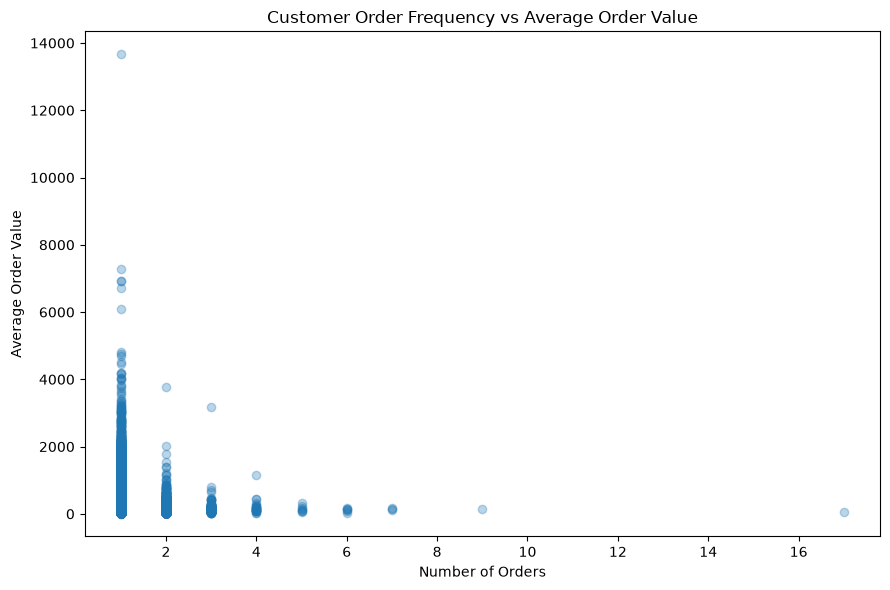

In [637]:
plt.figure(figsize=(9, 6))

plt.scatter(
    customer_frequency_aov["order_count"],
    customer_frequency_aov["avg_order_value"],
    alpha=0.3
)

plt.title("Customer Order Frequency vs Average Order Value")
plt.xlabel("Number of Orders")
plt.ylabel("Average Order Value")

plt.tight_layout()
plt.show()

### Order Frequency vs Average Order Value — Business Insights

The correlation between customer order frequency and average order value is
approximately -0.008, indicating virtually no linear relationship.

The scatter plot also shows no clear pattern between the number of orders and
average order value.

Therefore, customers who purchase more frequently do not necessarily place
larger or smaller orders on average.

This indicates that purchase frequency and order size represent different
aspects of customer behavior and should be analyzed separately when evaluating
customer value.

## 52. Customer Retention — Cohort Analysis

### Business Question

How well does the business retain customers after their first purchase?

Customers are grouped into cohorts based on the month of their first order,
and subsequent purchasing activity is analyzed to understand customer
retention over time.

In [638]:
customer_cohort = (
    rfm_data[
        ["customer_unique_id", "order_purchase_timestamp"]
    ]
    .copy()
)

customer_cohort["order_month"] = (
    customer_cohort["order_purchase_timestamp"]
    .dt.to_period("M")
)

customer_cohort["first_order_month"] = (
    customer_cohort
    .groupby("customer_unique_id")["order_month"]
    .transform("min")
)

customer_cohort.head()

,customer_unique_id,order_purchase_timestamp,order_month,first_order_month
0,7c396fd4830fd04220f754e42b4e5bff,2017-10-02 10:56:33,2017-10,2017-09
1,af07308b275d755c9edb36a90c618231,2018-07-24 20:41:37,2018-07,2018-07
2,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08 08:38:49,2018-08,2018-08
3,7c142cf63193a1473d2e66489a9ae977,2017-11-18 19:28:06,2017-11,2017-11
4,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13 21:18:39,2018-02,2018-02


In [639]:
customer_cohort["cohort_index"] = (
    (customer_cohort["order_month"].dt.year -
     customer_cohort["first_order_month"].dt.year) * 12
    +
    (customer_cohort["order_month"].dt.month -
     customer_cohort["first_order_month"].dt.month)
    + 1
)

customer_cohort.head()

,customer_unique_id,order_purchase_timestamp,order_month,first_order_month,cohort_index
0,7c396fd4830fd04220f754e42b4e5bff,2017-10-02 10:56:33,2017-10,2017-09,2
1,af07308b275d755c9edb36a90c618231,2018-07-24 20:41:37,2018-07,2018-07,1
2,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08 08:38:49,2018-08,2018-08,1
3,7c142cf63193a1473d2e66489a9ae977,2017-11-18 19:28:06,2017-11,2017-11,1
4,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13 21:18:39,2018-02,2018-02,1


In [640]:
cohort_counts = (
    customer_cohort
    .groupby(
        ["first_order_month", "cohort_index"]
    )["customer_unique_id"]
    .nunique()
    .reset_index()
)

cohort_pivot = (
    cohort_counts
    .pivot(
        index="first_order_month",
        columns="cohort_index",
        values="customer_unique_id"
    )
)

cohort_pivot.head()

cohort_index,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,20,21
first_order_month,,,,,,,,,,,,,,,,,,,,
2016-09,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,305.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,NaN,1.0,2.0,2.0
2016-12,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,754.0,3.0,2.0,1.0,3.0,1.0,3.0,1.0,1.0,NaN,3.0,1.0,5.0,3.0,1.0,1.0,2.0,3.0,1.0,NaN
2017-02,1705.0,4.0,5.0,2.0,7.0,2.0,4.0,3.0,2.0,3.0,2.0,5.0,2.0,3.0,2.0,1.0,1.0,4.0,NaN,NaN


In [641]:
cohort_retention = (
    cohort_pivot
    .div(cohort_pivot[1], axis=0)
    * 100
)

cohort_retention.round(2)

cohort_index,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,20,21
first_order_month,,,,,,,,,,,,,,,,,,,,
2016-09,100.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,100.0,NaN,NaN,NaN,NaN,NaN,0.33,NaN,NaN,0.33,NaN,0.33,NaN,0.33,NaN,0.33,NaN,0.33,0.66,0.66
2016-12,100.0,100.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,100.0,0.40,0.27,0.13,0.40,0.13,0.40,0.13,0.13,NaN,0.40,0.13,0.66,0.40,0.13,0.13,0.27,0.40,0.13,NaN
2017-02,100.0,0.23,0.29,0.12,0.41,0.12,0.23,0.18,0.12,0.18,0.12,0.29,0.12,0.18,0.12,0.06,0.06,0.23,NaN,NaN
2017-03,100.0,0.50,0.35,0.39,0.35,0.15,0.15,0.31,0.35,0.08,0.39,0.12,0.23,0.12,0.15,0.23,0.08,0.15,NaN,NaN
2017-04,100.0,0.60,0.21,0.17,0.34,0.26,0.34,0.30,0.30,0.17,0.26,0.09,0.09,0.04,0.09,0.09,0.17,NaN,NaN,NaN
2017-05,100.0,0.48,0.48,0.39,0.31,0.34,0.42,0.14,0.25,0.28,0.25,0.34,0.25,0.03,0.20,0.25,NaN,NaN,NaN,NaN
2017-06,100.0,0.48,0.35,0.39,0.26,0.39,0.39,0.22,0.13,0.22,0.32,0.35,0.16,0.13,0.19,NaN,NaN,NaN,NaN,NaN


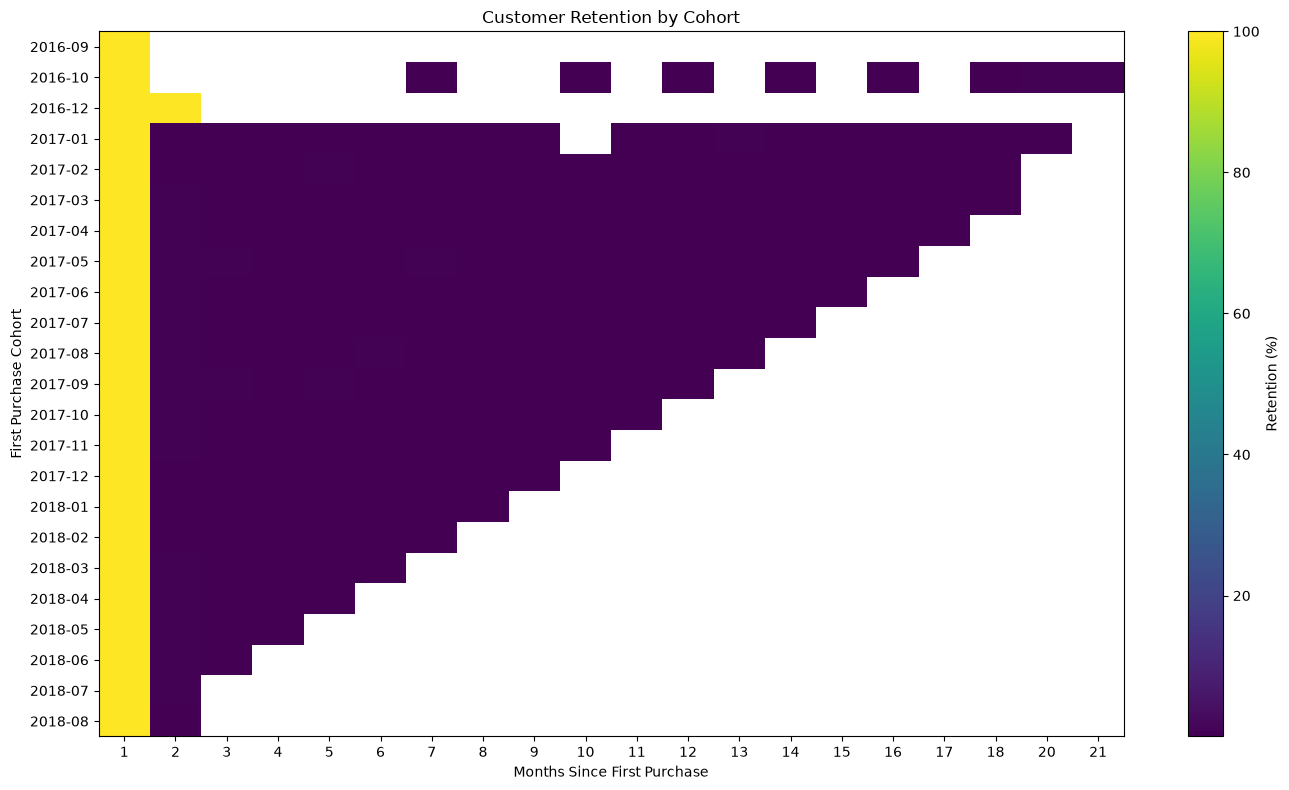

In [642]:
plt.figure(figsize=(14, 8))

plt.imshow(
    cohort_retention,
    aspect="auto"
)

plt.colorbar(label="Retention (%)")

plt.title("Customer Retention by Cohort")
plt.xlabel("Months Since First Purchase")
plt.ylabel("First Purchase Cohort")

plt.xticks(
    range(len(cohort_retention.columns)),
    cohort_retention.columns
)

plt.yticks(
    range(len(cohort_retention.index)),
    cohort_retention.index.astype(str)
)

plt.tight_layout()
plt.show()

### Customer Retention — Cohort Analysis Insights

The cohort retention analysis shows a substantial decline in customer
retention after the initial purchase.

Although every cohort starts at 100% retention in its first purchase month,
retention drops sharply in subsequent months and remains relatively low.

This indicates that the business has strong customer acquisition but weak
repeat-purchase retention.

The cohort analysis supports the earlier finding that approximately 96.88% of
customers are one-time purchasers, while only 3.12% are repeat customers.

Improving customer retention and encouraging repeat purchases therefore
represents a major business opportunity.

## 53. Repeat Purchase Timing

### Business Question

How long does it take for customers to make a repeat purchase?

The time between a customer's first and subsequent orders is analyzed to
understand typical repeat-purchase timing.

In [643]:
repeat_purchase_data = (
    rfm_data[
        ["customer_unique_id", "order_id", "order_purchase_timestamp"]
    ]
    .sort_values(
        ["customer_unique_id", "order_purchase_timestamp"]
    )
    .copy()
)

repeat_purchase_data["previous_order_date"] = (
    repeat_purchase_data
    .groupby("customer_unique_id")["order_purchase_timestamp"]
    .shift(1)
)

repeat_purchase_data["days_since_previous_order"] = (
    repeat_purchase_data["order_purchase_timestamp"]
    - repeat_purchase_data["previous_order_date"]
).dt.days

repeat_purchase_data.head()

,customer_unique_id,order_id,order_purchase_timestamp,previous_order_date,days_since_previous_order
52389,0000366f3b9a7992bf8c76cfdf3221e2,e22acc9c116caa3f2b7121bbb380d08e,2018-05-10 10:56:27,NaT,NaN
73317,0000b849f77a49e4a4ce2b2a4ca5be3f,3594e05a005ac4d06a72673270ef9ec9,2018-05-07 11:11:27,NaT,NaN
26249,0000f46a3911fa3c0805444483337064,b33ec3b699337181488304f362a6b734,2017-03-10 21:05:03,NaT,NaN
97729,0000f6ccb0745a6a4b88665a16c9f078,41272756ecddd9a9ed0180413cc22fb6,2017-10-12 20:29:41,NaT,NaN
41239,0004aac84e0df4da2b147fca70cf8255,d957021f1127559cd947b62533f484f7,2017-11-14 19:45:42,NaT,NaN


In [644]:
repeat_purchase_intervals = (
    repeat_purchase_data[
        repeat_purchase_data["previous_order_date"].notna()
    ]
)

repeat_purchase_intervals[
    "days_since_previous_order"
].describe().round(2)

count    3246.00
mean       78.52
std       107.53
min         0.00
25%         0.00
50%        29.00
75%       120.00
max       608.00
Name: days_since_previous_order, dtype: float64

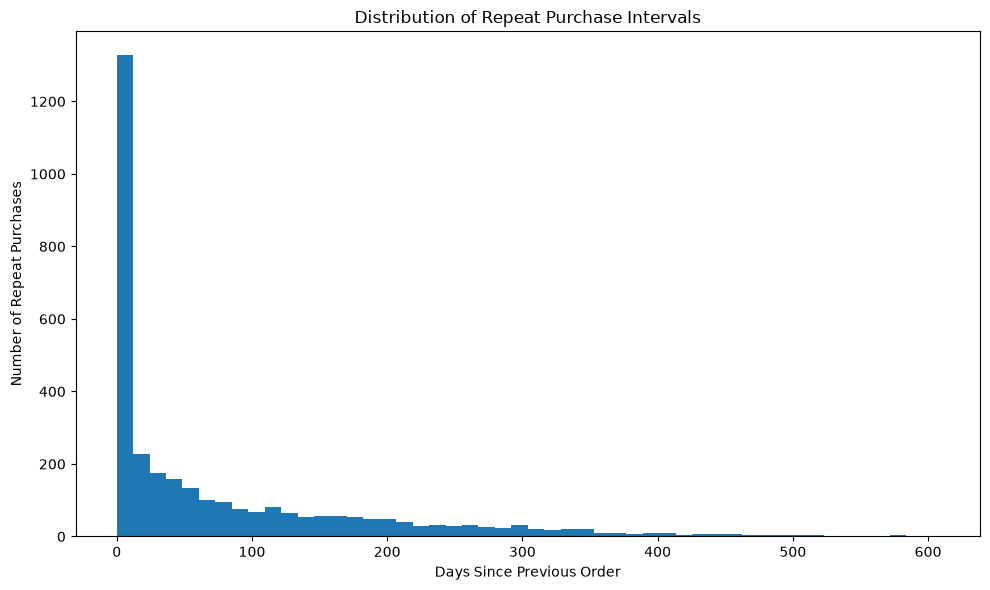

In [645]:
plt.figure(figsize=(10, 6))

plt.hist(
    repeat_purchase_intervals["days_since_previous_order"],
    bins=50
)

plt.title("Distribution of Repeat Purchase Intervals")
plt.xlabel("Days Since Previous Order")
plt.ylabel("Number of Repeat Purchases")

plt.tight_layout()
plt.show()

In [646]:
print(
    "Average Days Between Purchases:",
    round(
        repeat_purchase_intervals[
            "days_since_previous_order"
        ].mean(),
        2
    )
)

print(
    "Median Days Between Purchases:",
    round(
        repeat_purchase_intervals[
            "days_since_previous_order"
        ].median(),
        2
    )
)

Average Days Between Purchases: 78.52
Median Days Between Purchases: 29.0


### Repeat Purchase Timing — Business Insights

The analysis of repeat purchase intervals shows that customers take an
average of 78.52 days between purchases, while the median interval is only
29 days.

The large difference between the mean and median indicates a strongly
right-skewed distribution, with a smaller number of customers returning after
much longer periods.

The histogram shows that most repeat purchases occur within relatively short
intervals, while some customers return after several months.

Therefore, early customer engagement and retention efforts after the first
purchase may be more effective than relying on long-term passive retention.

## 54. Repeat Purchase Retention Windows

### Business Question

What proportion of repeat purchases occur within key retention windows?

Repeat purchases are grouped into 30, 60, 90, and 180-day windows to identify
the typical timeframe for customer re-engagement.

In [647]:
retention_windows = pd.Series({
    "Within 30 Days": (
        repeat_purchase_intervals["days_since_previous_order"] <= 30
    ).mean() * 100,

    "Within 60 Days": (
        repeat_purchase_intervals["days_since_previous_order"] <= 60
    ).mean() * 100,

    "Within 90 Days": (
        repeat_purchase_intervals["days_since_previous_order"] <= 90
    ).mean() * 100,

    "Within 180 Days": (
        repeat_purchase_intervals["days_since_previous_order"] <= 180
    ).mean() * 100
})

retention_windows.round(2)

Within 30 Days     50.65
Within 60 Days     62.32
Within 90 Days     69.22
Within 180 Days    83.76
dtype: float64

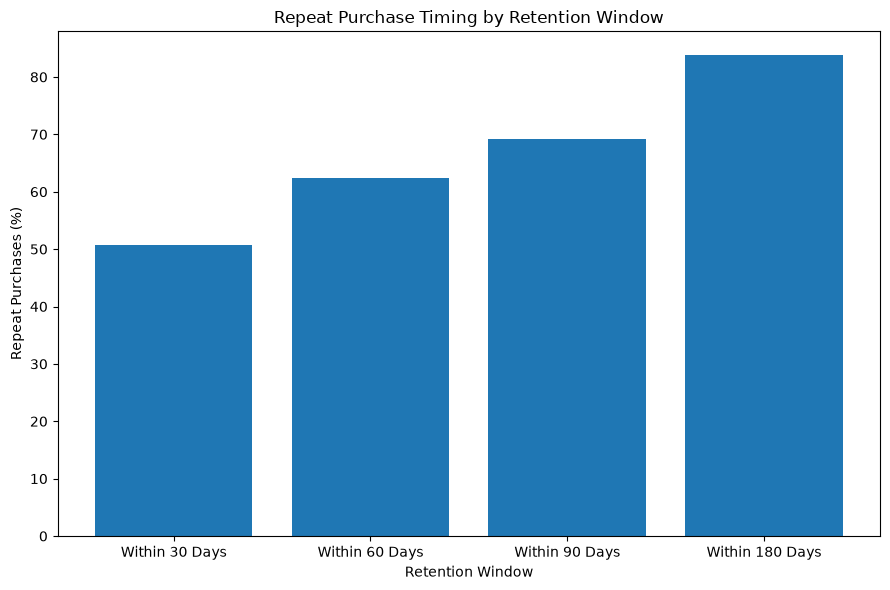

In [648]:
plt.figure(figsize=(9, 6))

plt.bar(
    retention_windows.index,
    retention_windows.values
)

plt.title("Repeat Purchase Timing by Retention Window")
plt.xlabel("Retention Window")
plt.ylabel("Repeat Purchases (%)")

plt.tight_layout()
plt.show()

### Repeat Purchase Retention Windows — Business Insights

Approximately 50.65% of repeat purchases occur within 30 days of the previous
purchase.

This increases to 62.32% within 60 days, 69.22% within 90 days, and 83.76%
within 180 days.

The results indicate that the first 30–90 days represent an important
retention window, as a substantial proportion of repeat purchases occur
during this period.

Therefore, customer re-engagement campaigns should focus strongly on the
early post-purchase period, particularly within the first 30–90 days.

## 55. Customer Value by Product Category

### Business Question

Which product categories generate higher-value customer purchases?

Customer spending is analyzed across product categories to identify the
categories associated with higher customer value.

In [649]:
customer_product_value = (
    order_items_clean[
        ["order_id", "product_id", "price"]
    ]
    .merge(
        orders_clean[
            ["order_id", "customer_id"]
        ],
        on="order_id",
        how="inner"
    )
    .merge(
        customers_clean[
            ["customer_id", "customer_unique_id"]
        ],
        on="customer_id",
        how="inner"
    )
    .merge(
        products_clean[
            ["product_id", "product_category_name"]
        ],
        on="product_id",
        how="left"
    )
)

customer_product_value.head()

,order_id,product_id,price,customer_id,customer_unique_id,product_category_name
0,00010242fe8c5a6d1ba2dd792cb16214,4244733e06e7ecb4970a6e2683c13e61,58.90,3ce436f183e68e07877b285a838db11a,871766c5855e863f6eccc05f988b23cb,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,e5f2d52b802189ee658865ca93d83a8f,239.90,f6dd3ec061db4e3987629fe6b26e5cce,eb28e67c4c0b83846050ddfb8a35d051,pet_shop
2,000229ec398224ef6ca0657da4fc703e,c777355d18b72b67abbeef9df44fd0fd,199.00,6489ae5e4333f3693df5ad4372dab6d3,3818d81c6709e39d06b2738a8d3a2474,moveis_decoracao
3,00024acbcdf0a6daa1e931b038114c75,7634da152a4610f1595efa32f14722fc,12.99,d4eb9395c8c0431ee92fce09860c5a06,af861d436cfc08b2c2ddefd0ba074622,perfumaria
4,00042b26cf59d7ce69dfabb4e55b4fd9,ac6c3623068f30de03045865e4e10089,199.90,58dbd0b2d70206bf40e62cd34e84d795,64b576fb70d441e8f1b2d7d446e483c5,ferramentas_jardim


In [650]:
category_customer_value = (
    customer_product_value
    .groupby("product_category_name")
    .agg(
        customers=("customer_unique_id", "nunique"),
        orders=("order_id", "nunique"),
        total_revenue=("price", "sum"),
        avg_order_value=("price", "mean")
    )
    .sort_values("total_revenue", ascending=False)
)

category_customer_value.head(15).round(2)

,customers,orders,total_revenue,avg_order_value
product_category_name,,,,
beleza_saude,8678,8836,1258681.34,130.16
relogios_presentes,5547,5624,1205005.68,201.14
cama_mesa_banho,9145,9417,1036988.68,93.30
esporte_lazer,7515,7720,988048.97,114.34
informatica_acessorios,6557,6689,911954.32,116.51
moveis_decoracao,6317,6449,729762.49,87.56
cool_stuff,3615,3632,635290.85,167.36
utilidades_domesticas,5821,5884,632248.66,90.79
automotivo,3852,3897,592720.11,139.96


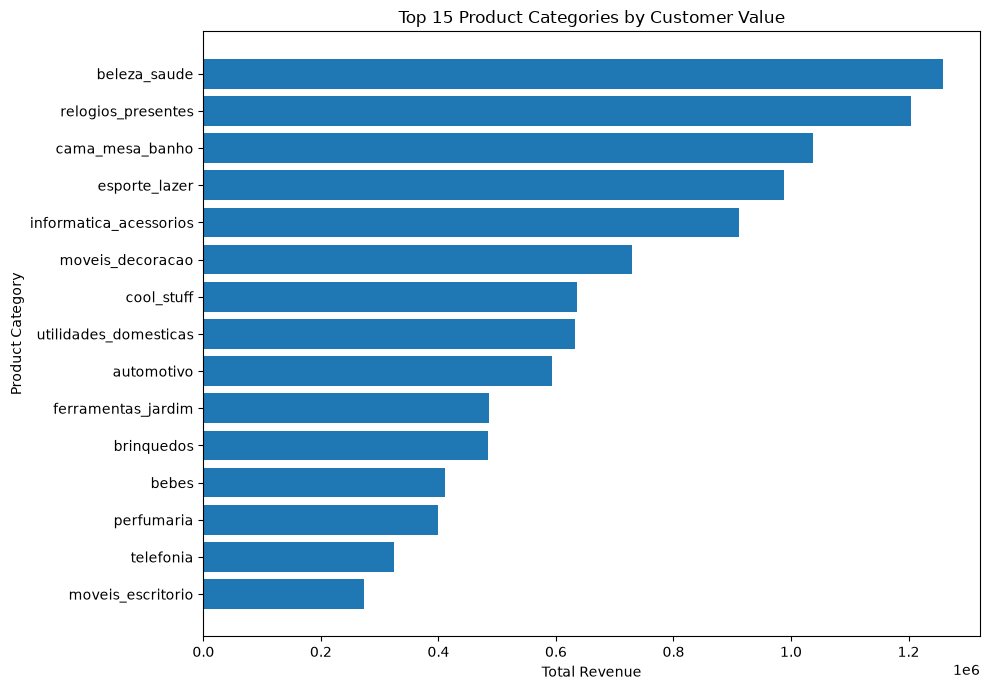

In [651]:
top_value_categories = (
    category_customer_value
    .head(15)
    .sort_values("total_revenue")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_value_categories.index,
    top_value_categories["total_revenue"]
)

plt.title("Top 15 Product Categories by Customer Value")
plt.xlabel("Total Revenue")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

### Customer Value by Product Category — Business Insights

Customer spending varies substantially across product categories.

The highest-revenue categories include beleza_saude, relogios_presentes,
cama_mesa_banho, esporte_lazer, and informatica_acessorios.

These categories are major contributors to overall customer spending and
represent important revenue-generating product segments.

However, total category revenue is influenced by both customer demand and
sales volume. Therefore, high total revenue does not necessarily mean that
customers spend more per transaction in that category.

## 56. Product Category vs Repeat Customers

### Business Question

Which product categories are associated with repeat customer behavior?

Customer purchase behavior is analyzed across product categories to identify
categories with relatively higher repeat-customer participation.

In [652]:
category_repeat_data = (
    customer_product_value[
        ["customer_unique_id", "product_category_name"]
    ]
    .merge(
        customer_order_frequency[
            ["order_count", "customer_type"]
        ],
        left_on="customer_unique_id",
        right_index=True,
        how="left"
    )
)

category_repeat_data.head()

,customer_unique_id,product_category_name,order_count,customer_type
0,871766c5855e863f6eccc05f988b23cb,cool_stuff,1,One-time
1,eb28e67c4c0b83846050ddfb8a35d051,pet_shop,2,Repeat
2,3818d81c6709e39d06b2738a8d3a2474,moveis_decoracao,1,One-time
3,af861d436cfc08b2c2ddefd0ba074622,perfumaria,1,One-time
4,64b576fb70d441e8f1b2d7d446e483c5,ferramentas_jardim,1,One-time


In [653]:
category_repeat_summary = (
    category_repeat_data
    .groupby("product_category_name")
    .agg(
        customers=("customer_unique_id", "nunique"),
        repeat_customers=(
            "customer_type",
            lambda x: (x == "Repeat").sum()
        )
    )
)

category_repeat_summary["repeat_customer_pct"] = (
    category_repeat_summary["repeat_customers"]
    / category_repeat_summary["customers"]
    * 100
)

category_repeat_summary = (
    category_repeat_summary
    .sort_values("repeat_customer_pct", ascending=False)
)

category_repeat_summary.head(15).round(2)

,customers,repeat_customers,repeat_customer_pct
product_category_name,,,
fraldas_higiene,26,10,38.46
artes_e_artesanato,21,5,23.81
fashion_roupa_feminina,39,8,20.51
eletrodomesticos,703,138,19.63
moveis_quarto,91,15,16.48
la_cuisine,13,2,15.38
bebidas,292,44,15.07
fashion_bolsas_e_acessorios,1798,263,14.63
moveis_decoracao,6317,821,13.00


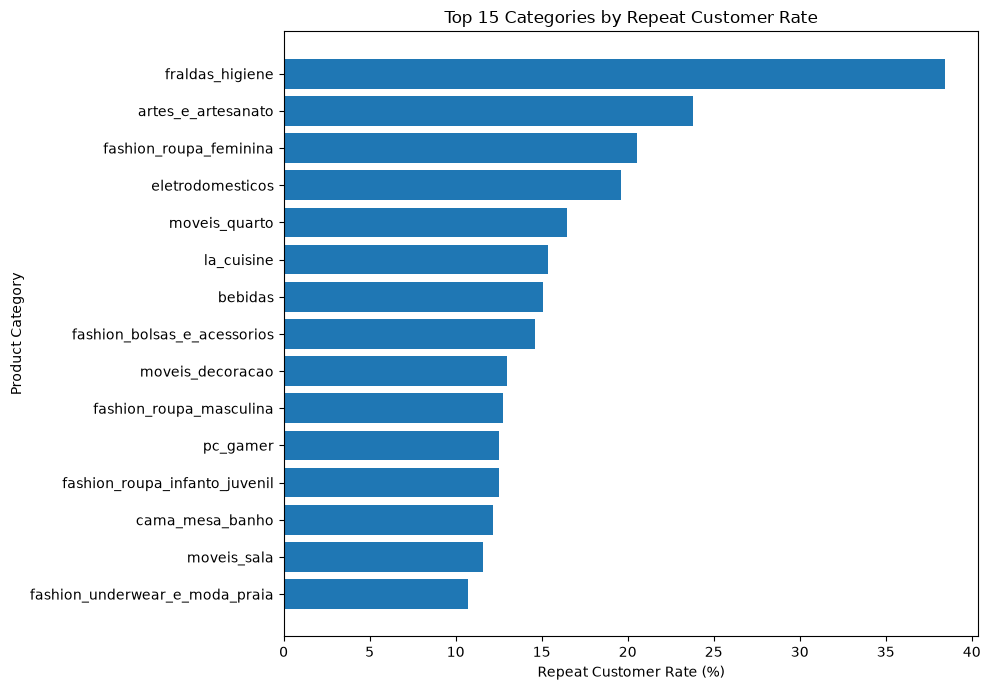

In [654]:
top_repeat_categories = (
    category_repeat_summary
    .head(15)
    .sort_values("repeat_customer_pct")
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_repeat_categories.index,
    top_repeat_categories["repeat_customer_pct"]
)

plt.title("Top 15 Categories by Repeat Customer Rate")
plt.xlabel("Repeat Customer Rate (%)")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

### Product Category vs Repeat Customers — Business Insights

Repeat-customer rates vary considerably across product categories.

Some categories, such as fraldas_higiene, artes_e_artesanato,
fashion_roupa_feminina, and eletrodomesticos, show relatively higher
repeat-customer rates.

The fraldas_higiene category has the highest observed repeat-customer rate
at approximately 38.46%. However, this category has a relatively small
customer base, so the high percentage should be interpreted cautiously.

Therefore, repeat-customer rate should be evaluated together with customer
volume and revenue contribution when identifying categories with strong
retention potential.

## 57. Numerical Relationship Overview

### Business Question

What are the key relationships among customer value, purchase frequency,
order value, delivery performance, and customer satisfaction?

A correlation matrix is used to provide a consolidated view of the major
numerical relationships identified during the EDA.

In [655]:
correlation_data = pd.DataFrame({
    "Customer Revenue": customer_frequency_revenue["total_revenue"],
    "Order Frequency": customer_frequency_revenue["order_count"],
    "Average Order Value": customer_frequency_aov["avg_order_value"],
    "Average Delivery Time": customer_delivery["avg_delivery_days"],
    "Average Review Score": customer_review["avg_review_score"]
}).dropna()

correlation_matrix = correlation_data.corr()

correlation_matrix.round(3)

,Customer Revenue,Order Frequency,Average Order Value,Average Delivery Time,Average Review Score
Customer Revenue,1.000,0.126,0.982,0.068,-0.041
Order Frequency,0.126,1.000,-0.008,-0.005,0.001
Average Order Value,0.982,-0.008,1.000,0.070,-0.042
Average Delivery Time,0.068,-0.005,0.070,1.000,-0.335
Average Review Score,-0.041,0.001,-0.042,-0.335,1.000


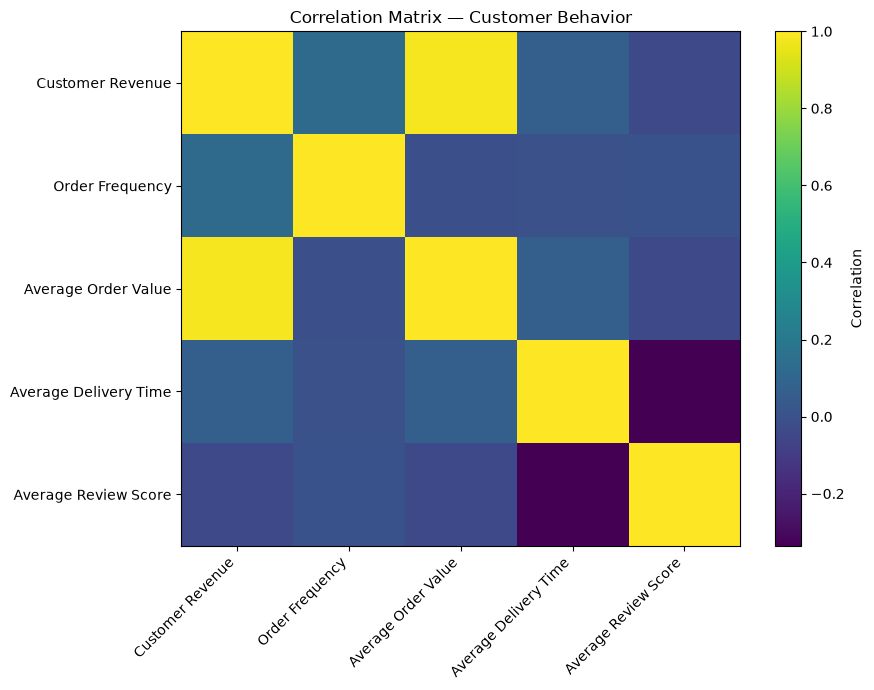

In [656]:
plt.figure(figsize=(9, 7))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index
)

plt.title("Correlation Matrix — Customer Behavior")

plt.tight_layout()
plt.show()

### Numerical Relationship Overview — Business Insights

The correlation analysis shows that customer revenue has a very strong
positive relationship with average order value (0.982), indicating that
higher order values are strongly associated with higher customer revenue.

Order frequency has only a weak positive relationship with customer revenue
(0.126), suggesting that purchase frequency alone is not a strong indicator
of customer value.

Delivery time has a moderate negative relationship with review score
(-0.335). This indicates that longer delivery times tend to be associated
with lower customer satisfaction.

Customer revenue has almost no linear relationship with delivery time (0.068)
or review score (-0.041). Similarly, order frequency and average order value
show virtually no relationship (-0.008).

Overall, delivery performance appears more closely related to customer
satisfaction than to customer monetary value.

# Final EDA — Key Business Insights & Recommendations

## 1. Revenue & Sales Performance

- Revenue and order volume show a strong overall growth trend across the
  available period.
- Sales are concentrated in a relatively small number of high-performing
  sellers and product categories.
- Customer revenue is highly right-skewed, with a small number of
  high-value customers generating disproportionately high revenue.

## 2. Customer Behavior

- Approximately 96.88% of customers are one-time purchasers.
- Only 3.12% of customers are repeat purchasers.
- This indicates a major customer-retention opportunity.

## 3. Customer Value

- Champions have the highest average order value at approximately 270.86,
  followed by Loyal Customers at 190.47.
- Loyal Customers and Champions together represent approximately 49.67% of
  customers but contribute approximately 67.85% of total revenue.
- Customer value is therefore highly concentrated among engaged customers.

## 4. Customer Retention

- Cohort analysis shows a substantial decline in retention after the initial
  purchase.
- Approximately 50.65% of repeat purchases occur within 30 days.
- Approximately 69.22% occur within 90 days.
- Approximately 83.76% occur within 180 days.
- The first 30–90 days represent an important customer re-engagement window.

## 5. Delivery Performance

- Average delivery time is relatively similar across RFM segments.
- High-value customers do not systematically receive faster deliveries.
- Delivery time has a moderate negative relationship with review score
  (-0.335), indicating that slower delivery tends to be associated with
  lower customer satisfaction.

## 6. Customer Satisfaction

- Review scores are generally high overall.
- Customer revenue has almost no relationship with review score
  (-0.041).
- Therefore, high-value customers do not necessarily provide better
  reviews.

## 7. Product Categories

- A small number of product categories contribute substantially to total
  revenue.
- Some categories show relatively higher repeat-customer rates.
- Category-level retention should be evaluated together with customer volume
  and revenue to avoid overinterpreting small categories.

## 8. Key Business Recommendations

### Retention
Focus on converting one-time customers into repeat customers through
post-purchase engagement and targeted reactivation campaigns.

### Early Engagement
Prioritize the first 30–90 days after purchase because a large proportion of
repeat purchases occur during this period.

### High-Value Customers
Protect Champions and Loyal Customers through personalized offers,
loyalty benefits, and proactive retention strategies.

### Delivery Experience
Reduce delivery delays because slower delivery is associated with lower
customer review scores.

### Potential Customers
Target Potential Customers with personalized recommendations, upselling,
and repeat-purchase incentives to move them toward Loyal or Champion
segments.

### Product Strategy
Prioritize high-revenue categories while identifying high-repeat categories
for retention-focused campaigns.

## Overall Conclusion

The EDA indicates that the business has strong revenue potential but faces a
significant customer-retention challenge. Revenue is concentrated among a
relatively small group of high-value customers, while the majority of
customers make only one purchase.

Improving repeat purchases, protecting high-value customers, and improving
delivery performance are therefore the key opportunities identified through
the analysis.